# Prüfung in CADS Immersion 2026

*Disclaimer: In Teil A wurde sich im Sinne der korrekten Einhaltung der geforderten Aufgabenstellung trotz großer Bedenken gegen die methodisch richtige Berücksichtigung des Exposures entschieden.
Dadurch enstehende Verzerrungen können die folgenden Resultate und Interpretationen massiv beeinflussen.*

# Teil B: Tarifierung & Modellierung

**Dieser Teil umfasst die praktische Umsetzung statistischer und maschineller Lernverfahren zur Modellierung
von Schadenhäufigkeit (*Frequency*), Schadendurchschnitt (*Severity*) sowie Schadenbedarf (*Pure Premium*)
auf Basis des in Teil A aufbereiteten Datensatzes.**

## Aufgabe B1: Regressionsmodelle für die Schadenhäufigkeit

**Ziel dieses Abschnittes ist es, die Schadenanzahl bzw. Schadenfrequenz (*Frequency*) des in Teil A aufbereiteten
Datensatzes mit verschiedenen statistischen und maschinellen Lernverfahren zu modellieren. Aufgabe B1
konzentriert sich dabei auf Regressionsmodelle.**

**Bearbeiten Sie die Teilaufgaben in der angegebenen Reihenfolge und dokumentieren Sie Ihre Vorgehensweise
nachvollziehbar (insb. Datenaufbereitung, Modellannahmen, Tuning und Evaluation).**

### a) Vorbereitungen

**Binden Sie die verwendeten Bibliotheken ein bzw. installieren Sie diese bei Bedarf. Achten
Sie darauf, nur Pakete zu verwenden, die im Verlauf des Notebooks tatsächlich benötigt werden, und
stellen Sie die Reproduzierbarkeit sicher. Lesen Sie anschließend den in Teil A aufbereiteten Datensatz
ein. Geben Sie die ersten zehn Zeilen des Datensatzes aus und prüfen Sie anhand von mindestens zwei
Kennzahlen, dass das Einlesen erfolgreich war (z. B. Dimensionen, fehlende Werte, Datentypen, einfache
Summen-/Mittelwertchecks). Diskutieren Sie, welche Features für ein Tarifierungsmodell sinnvoll verwendet
werden können und welche auszuschließen sind. Entfernen Sie ungeeignete Features anschließend
aus dem Datensatz. Geben Sie für jedes verbleibende Feature den Datentyp sowie die Anzahl eindeutiger
Ausprägungen an. Passen Sie die Datentypen bei Bedarf an; falls erforderlich, transformieren Sie den
Datensatz so, dass dieser nur noch numerische Features enthält. Definieren Sie abschließend die beiden
Variablen *var_cat* und *var_num*, indem**

* **_var_cat_ alle kategorialen Features und**
* **_var_num_ alle numerischen Features**

**enthält. Geben Sie *var_cat* und *var_num* aus und begründen Sie Ihre Zuordnung. Gehen Sie insbesondere
darauf ein, worauf bei kategorialen Features zu achten ist, und nehmen Sie ggf. Anpassungen vor.**

Wir laden zu Beginn alle im weiteren Verlauf des Notebooks verwendeten Pakete.

In [ ]:
# Pakete laden

# Allgemeine Hilfsfunktionen
import sys
import random
import warnings
import time

# Datenverarbeitung und -analyse
import pandas as pd
import numpy as np

# Visualisierung
import matplotlib.pyplot as plt
import seaborn as sns

# Statistische Modelle und maschinelles Lernen
import statsmodels.api as sm
import pygam
import sklearn
import tensorflow as tf
import lightgbm as lgb
import xgboost as xgb

Außerdem stellen wir durch Setzen eines Seeds und Anzeigen der verwendeten Versionen die Reproduzierbarkeit sicher.

In [ ]:
# Seed setzen
seed = 4242
random.seed(seed)
np.random.seed(seed)
tf.random.set_seed(seed)

# Versionen anzeigen
python_version = sys.version.split(' ')[0]

print("Verwendete Versionen:")
print("\nPython:", python_version)
print('\npandas:', pd.__version__)
print('numpy:', np.__version__)
print('matplotlib:', plt.matplotlib.__version__)
print('seaborn:', sns.__version__)
print('statsmodels:', sm.__version__)
print('pygam:', pygam.__version__)
print('sklearn:', sklearn.__version__)
print('tensorflow:', tf.__version__)
print('lightgbm:', lgb.__version__)
print('xgboost:', xgb.__version__)

Verwendete Versionen:

Python: 3.12.13

pandas: 2.2.2
numpy: 2.0.2
matplotlib: 3.10.0
seaborn: 0.13.2
statsmodels: 0.14.6
pygam: 0.12.0
sklearn: 1.6.1
tensorflow: 2.20.0
lightgbm: 4.6.0
xgboost: 3.2.0


Zu Beginn nehmen wir außerdem kurz allgemeine Einstellungen vor.

In [ ]:
# Allgemeine Einstellungen

# alle Spalten eines Dataframes anzeigen
pd.set_option('display.max_columns', None)

# FutureWarnings unterdrücken
warnings.filterwarnings('ignore', category=FutureWarning)

Wir lesen den in Teil A aufbereiteten Datensatz ein, geben beispielhaft die ersten zehn Zeilen aus und überprüfen die Dimensionen sowie fehlende Werte.

In [ ]:
# Daten einlesen
data_path = "/content/drive/MyDrive/Prüfung CADS Immersion/Daten/Datensatz fuer Teil B.csv"
data = pd.read_csv(data_path, sep=";")

# Erste zehn Zeilen ausgeben
print("Erste zehn Zeilen des Datensatzes:")
display(data.head(10))

# Dimensionen prüfen
print("Anzahl Zeilen:", data.shape[0])
print("Anzahl Spalten:", data.shape[1])

# Informationen zu Datentypen und fehlenden Werten prüfen
print("Anzahl fehldene Werte:", data.isnull().sum().sum())

Erste zehn Zeilen des Datensatzes:


,Distribution_channel,Seniority,Lapse,Payment,Premium,Cost_claims_year,N_claims_year,Area,Second_driver,Power,Cylinder_capacity,Value_vehicle,N_doors,Type_fuel,Weight,DrivAge,DrivLicenceAge,VehAge,Exposure
0,0,15,0,0,393.50,0.00,0,0,0,85,1229,16030.00,5,P,1105,41,21,3,0.090349
1,0,13,0,0,250.52,0.00,0,0,0,87,1598,9927.00,4,P,1055,49,25,10,0.594114
2,1,3,0,0,340.43,2162.89,3,0,0,109,1396,16550.00,5,P,1168,69,15,7,0.889802
3,0,18,0,0,335.82,0.00,0,0,0,130,1984,27330.00,4,P,1310,75,53,15,0.596851
4,1,6,0,0,259.12,0.00,0,0,1,65,1870,13140.00,5,D,1125,67,21,3,0.188912
5,0,3,0,0,248.68,0.00,0,1,0,75,1390,8548.00,4,P,1050,65,39,9,0.637919
6,1,4,0,1,437.32,0.00,0,1,1,90,1396,19390.00,5,D,1355,65,44,1,0.268309
7,1,4,0,1,314.30,0.00,0,0,0,100,1396,16190.00,5,P,1110,70,41,1,0.440794
8,0,19,0,0,461.41,0.00,0,0,0,103,1596,15205.61,3,P,1145,61,25,15,0.810404
9,0,10,0,1,347.28,0.00,0,1,0,110,1590,17000.00,3,P,1154,58,38,15,0.380561


Anzahl Zeilen: 15874
Anzahl Spalten: 19
Anzahl fehldene Werte: 0


Im nächsten Schritt separieren wir die Zielvariable 'N_claims_year' (und für später auch 'Cost_claims_year') sowie das Exposure, berechnen die Schadenfrequenz (und den Schadenbedarf) als später für bestimmte Modelle benötigte Zielvariable und entfernen die für ein Tarifierungsmodell uneeigneten Features.
Wie am Ende von Teil A diskutiert, können die Merkmale 'Seniority' und 'Lapse' zu Problemen hinsichtlich Data Leakage führen.
Außerdem ist die Verwendung von 'Premium' aus praktischen Gesichtssichtpunkten kritisch zu sehen, da die Ergebnisse der neuen Kalkulation im Normalfall nicht von der alten Prämienberechnung abhängen sollten.
Für die verbleibenden Merkmale geben wir den Datentyp und die Anzahl der eindeutigen Ausprägungen aus.


In [ ]:
# Zielvariable und Exposure separieren
y = data[['N_claims_year']].copy()
y_cost = data[['Cost_claims_year']].copy()
expo = data[['Exposure']].copy()

# Berechnen der Schadenfrequenz und des Schadenbedarfs als benötigte Zielvariable für bestimmte Modelle
y_freq = (data['N_claims_year'] / data['Exposure']).to_frame(name='Claim_freq')
y_pp = (data['Cost_claims_year'] / data['Exposure']).to_frame(name='Pure_premium')

# ungeeignete Features entfernen
features_to_drop = ['Seniority', 'Lapse', 'Premium', 'Cost_claims_year', 'N_claims_year', 'Exposure']
data = data.drop(columns=features_to_drop)

# Datentypen und Anzahl eindeutiger Ausprägungen ausgeben
feature_info = pd.DataFrame({
    'Datentyp': data.dtypes.astype(str),
    'Eindeutige Ausprägungen': data.nunique()
})
feature_info.index.name = None

print("Verbleibende Features:")
display(feature_info)

Verbleibende Features:


,Datentyp,Eindeutige Ausprägungen
Distribution_channel,int64,2
Payment,int64,2
Area,int64,2
Second_driver,int64,2
Power,int64,185
Cylinder_capacity,int64,326
Value_vehicle,float64,4198
N_doors,int64,5
Type_fuel,object,2
Weight,int64,841


Neben 'Type_fuel' handelt es sich offenbar auch bei 'Distribution_channel', 'Payment', 'Area', 'Second_driver' eigentlich um kategoriale Variablen, da diese laut Merkmalsbeschreibung zwei verschiedene Kategorien als Ausprägung haben, welche in den Daten lediglich mit Ziffern kodiert sind.
Wir interpretieren außerdem 'N_doors' in dem Sinne, dass die Variable eher die Art des PKWs statt eine metrische Größe beschreibt, als kategorial, wobei möglicherweise auch eine andere Auslegung vertretbar wäre.
Die restlichen Features sind hingegen alle klar von numerischer Natur und weisen bereits den passenden Datentyp auf.

In [ ]:
# kategorialen und numerische Merkmale festlegen
var_cat = ['Distribution_channel', 'Payment', 'Area', 'Second_driver', 'N_doors', 'Type_fuel']
var_num = [col for col in data.columns if col not in var_cat]

# Datentypen der kategorialen Merkmale anpassen
for var in var_cat:
    data[var] = data[var].astype("category")

# Ausgabe der kategorialen und der numerischen Merkmale
print("Liste der kategorialen Features (var_cat):")
print(var_cat)
print("\nListe der numerischen Features (var_num):")
print(var_num)

Liste der kategorialen Features (var_cat):
['Distribution_channel', 'Payment', 'Area', 'Second_driver', 'N_doors', 'Type_fuel']

Liste der numerischen Features (var_num):
['Power', 'Cylinder_capacity', 'Value_vehicle', 'Weight', 'DrivAge', 'DrivLicenceAge', 'VehAge']


Kategoriale Variablen sollten zunächst immer mit Datentyp category geführt werden, damit diese bei der Modellierung im Zweifelsfall nie fälschlicherweie als numerische Features behandelt werden.
Für Modelle, welche lediglich numerische Inputs akzeptieren, können wir im Vorfeld dann bewusst z.B. eine One-Hot-Kodierung durchführen.
In diesem Fall ist es wichtig, dass nicht zu viele Kategorien vorliegen, welche zu erheblichen Dimensionsproblemen führen können und daher gegebenenfalls gruppiert werden sollten.
Wir behandeln fehlende Werte meistens als eigene Ausprägung und fassen sehr dünn besetzte Kategorien aus Stabilitätsgründen zusammen.


In [ ]:
# Verteilung der kategorialen Merkmale
print("Verteilung der kategorialen Merkmale:")
for feature in var_cat:
    print("")
    print(data[feature].value_counts().to_string())

Verteilung der kategorialen Merkmale:

Distribution_channel
0    8712
1    7162

Payment
0    10381
1     5493

Area
0    11102
1     4772

Second_driver
0    14019
1     1855

N_doors
5    10700
3     2823
4     2062
2      288
6        1

Type_fuel
D    9693
P    6181


Bei einem einzigen Datensatz mit sechs Türen ergibt es keinen Sinn, hierfür später z.B. eine eigene Dummy-Variable zu erstellen.
Wir fassen die Kategorie daher mit dem Modus (und nächstgelegenen Wert) 5 zusammen.

In [ ]:
# N_doors = 6 mit N_doors = 5 zusammenfassen
data['N_doors'] = data['N_doors'].replace(6, 5)

print("Aktualisierte Verteilung von 'N_doors':\n")
print(data['N_doors'].value_counts().to_string())

Aktualisierte Verteilung von 'N_doors':

N_doors
5    10701
3     2823
4     2062
2      288


### b) Datenaufbereitung

**Führen Sie für die in Teilaufgabe a) identifizierten kategorialen Merkmale eine One-
Hot-Kodierung durch. Berücksichtigen Sie dabei, dass die erste Kategorie als Referenzkategorie zu entfernen
ist. Erzeugen Sie einen Datensatz, der**

* **die numerischen Merkmale,**
* **die originalen kategorialen Merkmale sowie**
* **die One-Hot-kodierten Merkmale**

**enthält. Sammeln Sie die Namen aller erzeugten Dummy-Merkmale in der Variablen *var_cat_oh* und geben
Sie diese aus. Teilen Sie den Datensatz anschließend begründet in drei Teile (Training, Validierung,
Test) und prüfen Sie die Zerlegung. Legen Sie eine Ergebnisdatenstruktur für die spätere Evaluation von
Machine-Learning-Modellen an, die mindestens**

* **den Modellnamen,**
* **die Ergebnisse auf Trainings-, Validierungs- und Testdatensatz sowie**
* **die für Modellierung bzw. Optimierung verwendete Zeit**

**enthält. Definieren Sie zudem zwei Hilfsfunktionen, mit denen Sie (i) Einträge in diese Ergebnisdatenstruktur
schreiben und (ii) die Ergebnisdatenstruktur strukturiert, kompakt und übersichtlich ausgeben können.**

Wir führen für die kategorialen Merkmale eine Dummy-Kodierung durch, wobei wir bei 'N_doors' zur besseren Interpretierbarkeit explizit die dominante Ausprägung 5 als Referenzkategorie wählen, und fügen die ursprünglichen Daten und die Dummy-Variablen zusammen.

In [ ]:
# One-Hot-Kodierung mit Referenzkategorie 5 für 'N_doors'
# Zeigt alle Spalten an, ohne sie zu kürzen
pd.set_option('display.max_columns', None)
data_one_hot_ndoors = pd.get_dummies(data[['N_doors']], dtype=int)
data_one_hot_ndoors = data_one_hot_ndoors.drop(columns=['N_doors_5'])

# One-Hot-Kodierung für die restlichen kategorialen Merkmale
var_cat_no_ndoors = [col for col in var_cat if col != 'N_doors']
data_one_hot_no_ndoors = pd.get_dummies(data[var_cat_no_ndoors], drop_first=True, dtype=int)

# Kombiniere die One-Hot-kodierten Merkmale
data_one_hot = pd.concat([data_one_hot_no_ndoors, data_one_hot_ndoors], axis=1)

# Namen der neu erzeugten Dummy-Merkmale sammeln
var_cat_oh = list(data_one_hot.columns)
print("Liste der One-Hot-kodierten Features (var_cat_oh):")
print(var_cat_oh)

# Datensatz erstellen, der numerische Merkmale, originale kategoriale Merkmale und One-Hot-kodierte Merkmale enthält
data_processed = pd.concat([
    data[var_num],
    data[var_cat],
    data_one_hot
], axis=1)

print("\nKombinierter Datensatz nach One-Hot-Kodierung:")
display(data_processed)

Liste der One-Hot-kodierten Features (var_cat_oh):
['Distribution_channel_1', 'Payment_1', 'Area_1', 'Second_driver_1', 'Type_fuel_P', 'N_doors_2', 'N_doors_3', 'N_doors_4']

Kombinierter Datensatz nach One-Hot-Kodierung:


,Power,Cylinder_capacity,Value_vehicle,Weight,DrivAge,DrivLicenceAge,VehAge,Distribution_channel,Payment,Area,Second_driver,N_doors,Type_fuel,Distribution_channel_1,Payment_1,Area_1,Second_driver_1,Type_fuel_P,N_doors_2,N_doors_3,N_doors_4
0,85,1229,16030.00,1105,41,21,3,0,0,0,0,5,P,0,0,0,0,1,0,0,0
1,87,1598,9927.00,1055,49,25,10,0,0,0,0,4,P,0,0,0,0,1,0,0,1
2,109,1396,16550.00,1168,69,15,7,1,0,0,0,5,P,1,0,0,0,1,0,0,0
3,130,1984,27330.00,1310,75,53,15,0,0,0,0,4,P,0,0,0,0,1,0,0,1
4,65,1870,13140.00,1125,67,21,3,1,0,0,1,5,D,1,0,0,1,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
15869,89,1597,12828.71,915,67,33,20,0,0,0,0,2,P,0,0,0,0,1,1,0,0
15870,109,1461,27530.36,1395,51,33,1,1,1,0,0,5,D,1,1,0,0,0,0,0,0
15871,75,1149,12500.00,1120,61,42,9,0,0,0,0,5,P,0,0,0,0,1,0,0,0
15872,177,1995,36100.00,1430,38,19,8,0,0,0,0,4,D,0,0,0,0,0,0,0,1


Wir teilen den Datensatz (sowie konsistent dazu die Zielvariablen und das Exposure) in Trainings-, Validierungs- und Testdaten auf.
Die verhältnismäßig geringe Zeilenanzahl stellt uns hier vor gewisse Herausforderungen, wir entscheiden uns letztlich für einen 70/15/15-Split als Kompromiss zwischen ausreichend Trainingsinformationen bei gleichzeitig verlässlicher Modellauswahl bzw. Endbewertung.

In [ ]:
# Trennung in Training (70%) und Rest (30%)
data_train, data_val_test = sklearn.model_selection.train_test_split(data_processed, test_size=0.3, random_state=seed)

# Trennung des Rests in Validierung (15%) und Test (15%)
data_val, data_test = sklearn.model_selection.train_test_split(data_val_test, test_size=0.5, random_state=seed)

# Prüfung der Zerlegung
print(f"Aufteilung des Datensatzes mit {len(data_processed)} Zeilen:\n")
print(f"Trainingsdaten: {len(data_train)} Zeilen ({len(data_train)/len(data_processed):.1%})")
print(f"Validierungsdaten: {len(data_val)} Zeilen ({len(data_val)/len(data_processed):.1%})")
print(f"Testdaten: {len(data_test)} Zeilen ({len(data_test)/len(data_processed):.1%})")
print(f"Insgesamt: {len(data_train)+len(data_val)+len(data_test)} Zeilen ({(len(data_train)+len(data_val)+len(data_test))/len(data_processed):.1%})")

# zu den Features konsistenter Split der Zielvariable und des Exposures
y_train = y.loc[data_train.index].copy()
y_cost_train = y_cost.loc[data_train.index].copy()
y_freq_train = y_freq.loc[data_train.index].copy()
y_pp_train = y_pp.loc[data_train.index].copy()
expo_train = expo.loc[data_train.index].copy()

y_val = y.loc[data_val.index].copy()
y_cost_val = y_cost.loc[data_val.index].copy()
y_freq_val = y_freq.loc[data_val.index].copy()
y_pp_val = y_pp.loc[data_val.index].copy()
expo_val = expo.loc[data_val.index].copy()

y_test = y.loc[data_test.index].copy()
y_cost_test = y_cost.loc[data_test.index].copy()
y_freq_test = y_freq.loc[data_test.index].copy()
y_pp_test = y_pp.loc[data_test.index].copy()
expo_test = expo.loc[data_test.index].copy()


Aufteilung des Datensatzes mit 15874 Zeilen:

Trainingsdaten: 11111 Zeilen (70.0%)
Validierungsdaten: 2381 Zeilen (15.0%)
Testdaten: 2382 Zeilen (15.0%)
Insgesamt: 15874 Zeilen (100.0%)


Außerdem legen wir für die spätere Evaluation von Modellen eine Ergebnisdatenstruktur an, welche den Modellnamen, die Ergebnisse auf Trainings-, Validierungs- und Testdaten sowie die für Modellierung bzw. Optimierung verwendete Zeit enthält, und definieren ergänzend zwei Hilffunktionen zum Befüllen und zur Ausgabe.

In [ ]:
# Ergebnisdatenstruktur für Modell-Evaluation anlegen
model_results = pd.DataFrame(columns=[
    'Model',
    'Train_Metric',
    'Validation_Metric',
    'Test_Metric',
    'Optimization_Time',
    'Modeling_Time'
])

# Hilfsfunktion zum Hinzufügen eines Eintrags zur Ergebnisdatenstruktur
def add_model_result(model_name, train_metric, validation_metric, test_metric, optimization_time, modeling_time):
    global model_results
    new_row = pd.DataFrame([{
        'Model': model_name,
        'Train_Metric': train_metric,
        'Validation_Metric': validation_metric,
        'Test_Metric': test_metric,
        'Optimization_Time': optimization_time,
        'Modeling_Time': modeling_time
    }])
    model_results = pd.concat([model_results, new_row], ignore_index=True)

# Hilfsfunktion zur Ausgabe der Ergebnisdatenstruktur
def display_model_results():
    # Dictionary für die Formatierung pro Spalte
    format_dict = {
        'Train_Metric': '{:.4f}',
        'Validation_Metric': '{:.4f}',
        'Test_Metric': '{:.4f}',
        'Optimization_Time': '{:.2f}',
        'Modeling_Time': '{:.2f}'
    }
    # Ergebnisdatenstruktur ausgeben
    display(model_results.style.format(format_dict).hide(axis='index'))

### c) Basismodell Schadenhäufigkeit (Intercept-Only)

**Implementieren Sie Hilfsfunktionen zur Berechnung
der Poisson-Devianz (orientieren Sie sich dazu an Referenz [1]) und passen Sie diese so an, dass die
Ergebnisse in die Ergebnisdatenstruktur geschrieben werden können. Trainieren Sie ein Intercept-Only-
Baseline-Modell. Erläutern Sie den Zusammenhang zwischen der (durchschnittlichen) Schadenhäufigkeit
in den Trainingsdaten und dem Intercept. Evaluieren Sie das Basismodell (mindestens auf Training und
Validierung), fügen Sie die Ergebnisse der Ergebnisdatenstruktur hinzu und kommentieren Sie diese kurz.**

Wir implementieren zunächst eine Hilfsfunktion zur Berechnung der Poisson-Devianz pro Exposure, wobei wir uns an der angegebenen Referenz [1] orientieren, die Formel aber so anpassen, dass das Exposure nicht doppelt gezählt wird (weil es bereits in den als Schadenanzahlen übergebenen Beobachtungen und Vorhersagen berücksichtigt ist).
Außerdem sorgen wir mit einer weiteren Funktion dafür, dass diese auf Trainings-, Validierungs- und Testdaten evaluiert und die Resulate in die Ergebnisdatenstruktur geschrieben werden können.

In [ ]:
# Hilfsfunktion zur Berechnung der Poisson-Devianz pro Exposure
def calculate_poisson_deviance(pred, obs, exposure):

    pred = np.asarray(pred).ravel()
    obs = np.asarray(obs).ravel()
    exposure = np.asarray(exposure).ravel()

    # Sicherstellen, dass pred nicht 0 ist, um Division durch 0 zu vermeiden
    pred = np.maximum(pred, 1e-10)

    # Berechne obs * log(obs / pred) nur für obs > 0 und setzte ansonsten 0 (entspricht dem passenden Grenzwert)
    log_term = np.zeros_like(obs, dtype=float)
    positive_obs_mask = obs > 0
    log_term[positive_obs_mask] = obs[positive_obs_mask] * np.log(obs[positive_obs_mask] / pred[positive_obs_mask])

    # Berechnung der einzelnen Devianz-Terme (abweichend von [1] ohne erneute Gewichtung mit Exposure)
    deviance_terms = pred - obs + log_term

    # Gesamte Devianz
    total_deviance = 2 * np.sum(deviance_terms)

    # Devianz pro Exposure
    deviance_per_exposure = total_deviance / np.sum(exposure)
    return deviance_per_exposure


# Hilfsfunktion zur Evaluierung der Poisson-Devianzen eines Modells auf Trainings- und Validierungsdaten
def evaluate_poisson_deviance_train_val(pred_train, obs_train, exposure_train,
                                          pred_val, obs_val, exposure_val):

    # Berechnung der Devianzen
    deviance_train = calculate_poisson_deviance(pred_train, obs_train, exposure_train)
    deviance_val = calculate_poisson_deviance(pred_val, obs_val, exposure_val)

    # Ausgabe
    print("Poisson-Devianz auf den Trainingsdaten:", deviance_train.round(4))
    print("Poisson-Devianz auf den Validierungsdaten:", deviance_val.round(4))


# Hilfsfunktion zur Evaluierung der Poisson-Devianzen eines Modells auf Trainings-, Validierungs- und Testdaten
# und Speicherung in der Ergebnisdatenstruktur
def evaluate_and_store_model_result(model_name,
                                        pred_train, obs_train, exposure_train,
                                        pred_val, obs_val, exposure_val,
                                        pred_test, obs_test, exposure_test,
                                        optimization_time, modeling_time):

    # Berechnung der Devianzen
    deviance_train = calculate_poisson_deviance(pred_train, obs_train, exposure_train)
    deviance_val = calculate_poisson_deviance(pred_val, obs_val, exposure_val)
    deviance_test = calculate_poisson_deviance(pred_test, obs_test, exposure_test)

    # Speichern in der Ergebnisdatenstruktur
    add_model_result(model_name, deviance_train, deviance_val, deviance_test, optimization_time, modeling_time)

Wir trainieren nun ein Intercept-Only-Baseline-Modell.
Im Kontext eines Poisson-Modells für Schadenanzahlen unter Berücksichtigung des Exposures als Offset lautet die entsprechende Modellgleichung $\log(\mu_i)=\beta_0+\log(\text{exposure}_i)$, was durch Umstellen zu konstant prognostizierten Schadenfrequenzen $\frac{\mu_i}{\text{exposure}_i}=e^{\beta_0}$ führt.
Der geschätzte Intercept entspricht dann genau der logarithmierten Schadenhäufigkeit in den Trainingsdaten.

In [ ]:
# Erstelle ein Intercept-Feature
X_train = np.ones(len(y_train))
X_val = np.ones(len(y_val))
X_test = np.ones(len(y_test))

# Startzeit messen
start_time = time.time()

# Fitte das Intercept-Only-Modell
intercept_only_fit = sm.GLM(y_train, X_train,
                         family=sm.families.Poisson(),
                         offset=np.log(expo_train.values.ravel())).fit()

# Endzeit messen und Modellierungszeit berechnen
end_time = time.time()
modeling_time = end_time - start_time

print("Intercept-Only-Baseline-Modell:\n")
print(intercept_only_fit.summary())
print("\nIntercept des Modells:", intercept_only_fit.params['const'].round(4))

# Schadenhäufigkeit in den Trainingsdaten bestimmen
frequency_train = y_train['N_claims_year'].sum() / expo_train['Exposure'].sum()
print(f"Schadenhäufigkeit in den Trainingsdaten: {frequency_train:.4f} (logarithmiert: {np.log(frequency_train):.4f})")

Intercept-Only-Baseline-Modell:

                 Generalized Linear Model Regression Results                  
Dep. Variable:          N_claims_year   No. Observations:                11111
Model:                            GLM   Df Residuals:                    11110
Model Family:                 Poisson   Df Model:                            0
Link Function:                    Log   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -14606.
Date:                Tue, 05 May 2026   Deviance:                       20440.
Time:                        10:30:04   Pearson chi2:                 5.10e+04
No. Iterations:                     6   Pseudo R-squ. (CS):         -2.220e-16
Covariance Type:            nonrobust                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.23

Wir evaluieren das Basis-Modell und fügen die Resultate der Ergebnisdatenstruktur hinzu.

In [ ]:
# Anwenden des Modells auf Trainings-, Validierungs- und Testdaten
pred_train = intercept_only_fit.predict(X_train, offset=np.log(expo_train.values.ravel()))
pred_val = intercept_only_fit.predict(X_val, offset=np.log(expo_val.values.ravel()))
pred_test = intercept_only_fit.predict(X_test, offset=np.log(expo_test.values.ravel()))

# Evaluation auf Trainings- und Validierungsdaten
evaluate_poisson_deviance_train_val(pred_train, y_train, expo_train,
                                      pred_val, y_val, expo_val)

# Hinzufügen zur Ergebnisdatenstriuktur
evaluate_and_store_model_result('Intercept-Only',
                                      pred_train, y_train, expo_train,
                                      pred_val, y_val, expo_val,
                                      pred_test, y_test, expo_test,
                                      0, modeling_time)

Poisson-Devianz auf den Trainingsdaten: 3.6515
Poisson-Devianz auf den Validierungsdaten: 3.7541


Da das Intercept-Only-Modell keinerlei Heterogenität berücksichtigt und für alle Beobachtungen dieselbe Schadenfrequenz vorhersagt, ist die Poisson-Devianz auf den Trainingsdaten typischerweise deutlich höher als bei komplexeren Modellen mit erklärenden Variablen.

### d) Generalisiertes Lineares Modell (GLM)

**Schätzen Sie ein GLM mit Poisson-Familie und Log-Link-Funktion. Trainieren Sie ein GLM mit vollständigem Featureset (kategoriale + numerische Merkmale) und
verwenden Sie *Exposure* als Offset. Geben Sie die Modellzusammenfassung aus und dokumentieren Sie
die Trainingszeit. Führen Sie eine kurze Modelldiagnostik durch:**

* **Prüfen Sie Modellannahmen mithilfe geeigneter Kennzahlen oder Diagnoseplots.**
* **Identifizieren Sie signifikante und nicht-signifikante Features.**
* **Diskutieren Sie, welche kategorialen bzw. numerischen Features den stärksten Einfluss auf die Schadenfrequenz
haben.**
* **Erläutern Sie mögliche Konsequenzen identifizierter Abweichungen von Modellannahmen für die Interpretation.**

**Vergleichen Sie die Poisson-Devianz auf Trainings- und Validierungsdaten (und später auf dem Testdatensatz)
und fügen Sie die Ergebnisse der Ergebnisdatenstruktur hinzu. Interpretieren Sie die Ergebnisse und
geben Sie eine kurze Einschätzung zum Trade-off zwischen Modellkomplexität und Modellgüte.**

Wir trainieren nun im ersten Schritt ein Poisson-GLM mit Log-Link und verwenden alle numerischen und (One-Hot-kodierten) kategorialen Merkmale sowie Exposure als Offset.

In [ ]:
# Numerische und One-Hot-kodierte kategoriale Features für GLM benötigt
X_train_glm = data_train[var_num + var_cat_oh].copy()
X_val_glm = data_val[var_num + var_cat_oh].copy()
X_test_glm = data_test[var_num + var_cat_oh].copy()

# Füge eine Konstante (Intercept) zur hinzu
X_train_glm = sm.add_constant(X_train_glm)
X_val_glm = sm.add_constant(X_val_glm)
X_test_glm = sm.add_constant(X_test_glm)

# Startzeit messen
start_time_glm = time.time()

# Trainiere das GLM mit Poisson-Familie, Log-Link-Funktion und Exposure als Offset
glm_fit = sm.GLM(y_train,
                 X_train_glm,
                 family=sm.families.Poisson(),
                 offset=np.log(expo_train.values.ravel())).fit()

# Endzeit messen und Modellierungszeit berechnen
end_time_glm = time.time()
modeling_time_glm = end_time_glm - start_time_glm

# Überdispersion bestimmen
overdispersion_pearson = glm_fit.pearson_chi2 / glm_fit.df_resid

# Modellzusammenfassung ausgeben
print("Generalisiertes Lineares Modell (GLM) mit Poisson-Familie (Log-Link):\n")
print(glm_fit.summary())
print(f"\nModellierungszeit für GLM: {modeling_time_glm:.2f} Sekunden")
print(f"\nDispersionsparameter des GLM: {overdispersion_pearson:.4f}")


Generalisiertes Lineares Modell (GLM) mit Poisson-Familie (Log-Link):

                 Generalized Linear Model Regression Results                  
Dep. Variable:          N_claims_year   No. Observations:                11111
Model:                            GLM   Df Residuals:                    11095
Model Family:                 Poisson   Df Model:                           15
Link Function:                    Log   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -14280.
Date:                Tue, 05 May 2026   Deviance:                       19787.
Time:                        10:30:04   Pearson chi2:                 4.78e+04
No. Iterations:                     6   Pseudo R-squ. (CS):            0.05701
Covariance Type:            nonrobust                                         
                             coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------

Der Dispersionsparameter, geschätzt durch den Quotienten aus Pearson-Chi-Quadrat-Statistik und Residuen-Freiheitsgraden, liegt mit 4,3 deutlich über 1.
Dies weist (auch ohne zusätzliche Diagnoseplots) auf eine starke Überdispersion hin, die Varianz der Schadenanzahl ist deutlich höher als ihr Mittelwert und die Modellannahme einer Poisson-Verteilung somit grob verletzt, wodurch natürlich auch die Nutzung der Poisson-Devianz als Evaluierungsmetrik kritisch zu hinterfragen ist.
Dies stellt das erste deutliche Warnsignal für den methodischen Fehler bei der Exposureberechnung in Teil A sowie die dadurch entstehenden Verzerrungen dar und alle folgenden Ergebnisse sind daher zwingend auch immer in diesem Kontext zu sehen.

Anhand der Modellzusammenfassung identifizieren wir Fahrzeugwert und -alter sowie die Türanzahl als nicht-signifikante Features, da ihre p-Werte (Spalte P>|z|) die typische Grenze von 0,05 deutlich überschreiten.
Alle anderen Variablen sehen wir gemäß dieser Vorgehensweise als signifikant an.
Gerade letztere Aussage ist allerdings mit Vorsicht zu genießen, da infolge der Überdispersion die Standardfehler und p-Werte des Poisson-GLM vermutlich zu optimistisch sind.
Den stärksten Einfluss auf die Schadenfrequenz haben die Features mit den höchsten absoluten Koeffizienten, bei den kategorialen Merkmalen also 'Payment' mit Faktor $\exp(0,4251)=1,5297$ bei halbjährlicher statt jährlicher Zahlweise, 'Type_fuel' mit Faktor $\exp(-0,1813)=0,8342$ bei Benzin statt Diesel oder auch 'Second_driver'.
Für die numerischen Merkmale sind dies prinzipiell 'DrivLicenceAge' mit Faktor $\exp(-0,0150)=0,9851$ bei Erhöhung um eine Einheit bzw. 'DrivAge' mit Faktor $\exp(0,0096)=1,0096$.
Es ist jedoch zu beachten, dass die beiden Variablen stark korreliert sind.
Außerdem ist Veränderung um eine Einheit je nach Skalierung der numerischen Features nicht direkt miteinander vergleichbar, sodass wir durch die fehlende Standardisierung der numerischen Merkmale nur anhand der Koeffizienten nicht wirklich vom tatsächlich stärksten Einfluss sprechen können.

Wir betrachten abschließend die Poisson-Devianz auf den Trainings- und Validierungsdaten sowie die Verbesserung zum Basis-Modell.

In [ ]:
# Vorhersagen mit dem GLM auf den Trainings-, Validierungs- und Testdaten generieren
pred_train_glm = glm_fit.predict(X_train_glm, offset=np.log(expo_train.values.ravel()))
pred_val_glm = glm_fit.predict(X_val_glm, offset=np.log(expo_val.values.ravel()))
pred_test_glm = glm_fit.predict(X_test_glm, offset=np.log(expo_test.values.ravel()))

# Poisson-Devianz auf den Trainings- und Validierungsdaten ausgeben
evaluate_poisson_deviance_train_val(pred_train_glm, y_train, expo_train,
                                      pred_val_glm, y_val, expo_val)

# Ergebnisse des GLM in die Ergebnisdatenstruktur speichern
evaluate_and_store_model_result('GLM',
                                      pred_train_glm, y_train, expo_train,
                                      pred_val_glm, y_val, expo_val,
                                      pred_test_glm, y_test, expo_test,
                                      0, modeling_time_glm)

# die aktualisierte Ergebnisdatenstruktur anzeigen
print("\nAktualisierte Ergebnisdatenstruktur:")
display_model_results()

Poisson-Devianz auf den Trainingsdaten: 3.5349
Poisson-Devianz auf den Validierungsdaten: 3.6313

Aktualisierte Ergebnisdatenstruktur:


Model,Train_Metric,Validation_Metric,Test_Metric,Optimization_Time,Modeling_Time
Intercept-Only,3.6515,3.7541,3.7054,0.00,0.04
GLM,3.5349,3.6313,3.6141,0.00,0.07


Die Poisson-Devianz liegt auf den Validierungsdaten über dem Wert des Trainings.
Im Vergleich zum Intercept-Only-Modell verbessert sich die Devianz jeweils um ca. 3%, was einerseits zwar für gute Generalisierung und wenig Overfitting spricht, andererseits aber für die Verwendung aller statt gar keiner Features zunächst überschaubar erscheint.
Vor diesem Hintergrund ist der Trade-off zwischen der erhöhten Modellkomplexität des vollparametrischen GLM und der Verbesserung der Modellgüte eher als ungünstig zu sehen und wir sollten bei einer weiteren Betrachtung Anpassungen z.B. in den Modellannahmen oder im Featureraum vornehmen.

### e) LASSO

**Erstellen Sie eine geeignete Feature-Matrix und Zielvariable für ein LASSO-Modell unter Verwendung
aller numerischen und (One-Hot-kodierten) kategorialen Merkmale. Begründen Sie, warum eine Standardisierung
der Features bei LASSO-Modellen erforderlich ist, und standardisieren Sie die Features für
Trainings- und Validierungsdaten. Führen Sie eine Grid-Search über die Regularisierungsstärke *alpha* und
das L1-Gewicht durch. Wählen Sie begründet geeignete Wertebereiche für beide Parameter. Bestimmen
Sie die optimalen Hyperparameter anhand der Poisson-Devianz auf dem Validierungsdatensatz. Stellen Sie
die Grid-Search-Ergebnisse tabellarisch dar und dokumentieren Sie die besten Parameterkombinationen.
Trainieren Sie das finale LASSO-Modell mit den optimalen Hyperparametern. Geben Sie die geschätzten
Koeffizienten aus und identifizieren Sie Features, die auf exakt Null regularisiert wurden. Interpretieren Sie
die Sparsity (Anzahl nicht-null Koeffizienten): Welche Features wurden als irrelevant identifiziert und ist dies
inhaltlich plausibel?**

LASSO-Regression stellt ein Regularisierungsverfahren dar, bei welchem die Koeffizienten aller Features mittels eines L1-Strafterms geschrumpft und einige exakt auf 0 gesetzt werden.
Dieser Term ist proportional zur Summe der absoluten Beträge der Koeffizienten, sodass Variablen mit großem Hauptwertebereich und damit prinzipiell kleineren Koeffizienten weniger stark bestraft werden würden als beispielsweise One-Hot-kodierte kategoriale Merkmale.
Folglich ist eine vorgelagerte Standardisierung der Features unerlässlich, damit alle Variablen dieselbe Skala haben und in der Regularisierungsstrafe fair berücksichtigt werden.

In [ ]:
# Auswahl der Features für LASSO
X_train_lasso = data_train[var_num + var_cat_oh].copy()
X_val_lasso = data_val[var_num + var_cat_oh].copy()
X_test_lasso = data_test[var_num + var_cat_oh].copy()

# Standardisieren der Features, Scaler nur auf Trainingsdaten fitten (Stichwort Data Leakage)
scaler_lasso = sklearn.preprocessing.StandardScaler()
X_train_lasso_scaled = scaler_lasso.fit_transform(X_train_lasso)
X_val_lasso_scaled = scaler_lasso.transform(X_val_lasso)
X_test_lasso_scaled = scaler_lasso.transform(X_test_lasso)

X_train_lasso_scaled = pd.DataFrame(X_train_lasso_scaled, columns=X_train_lasso.columns, index=X_train_lasso.index)
X_val_lasso_scaled = pd.DataFrame(X_val_lasso_scaled, columns=X_val_lasso.columns, index=X_val_lasso.index)
X_test_lasso_scaled = pd.DataFrame(X_test_lasso_scaled, columns=X_test_lasso.columns, index=X_test_lasso.index)

# Füge eine Konstante (Intercept) zur hinzu
X_train_lasso_scaled = sm.add_constant(X_train_lasso_scaled)
X_val_lasso_scaled = sm.add_constant(X_val_lasso_scaled)
X_test_lasso_scaled = sm.add_constant(X_test_lasso_scaled)

Wir führen eine grobe Grid-Search über die Regularisierungsstärke alpha und das L1-Gewicht durch.
Beim ersten Parameter können wir wie für standardisierte Merkmale üblich z.B. logarithmisch verteilte Werte zwischen 0,00001 und 1 betrachten, wodurch der Fokus eher auf dem linken Rand mit weniger starker Regularisierung liegt.
Im Sinne einer Feature-Selektion konzentrieren wir uns beim L1-Gewicht eher auf Werte bei 1 (reines LASSO) als bei 0 (reines Ridge mit L2-Norm) und befinden uns somit allgemeiner im Kontext von elastischen Netzen.

In [ ]:
# Wertebereiche für Grid Search
param_alpha = np.logspace(-5, 0, 10) # zehn logarithmisch verteilte Werte zwischen 0.00001 und 1
param_l1_ratio = [1, 0.9, 0.75, 0.5, 0.25]

# Identifikation der besten Parameter
best_alpha = None
best_l1_ratio = None
best_validation_deviance = np.inf
all_grid_results = []

# Startzeit messen
start_time_elastic_net_grid = time.time()

# Durchführung der Grid-Search
for current_alpha in param_alpha:
    for current_l1_ratio in param_l1_ratio:
          # Erstelle einen alpha-Vektor: 0 für den Intercept, current_alpha für die anderen Features
          alpha_vector = np.array([0.0] + [current_alpha] * (X_train_lasso_scaled.shape[1] - 1))

          # Trainiere das Elastic Net mit Poisson-Familie, Log-Link, Exposure als Offset und den aktuellen Hyperparametern
          elastic_net_grid_fit = sm.GLM(y_train, X_train_lasso_scaled,
                                        family=sm.families.Poisson(),
                                        offset=np.log(expo_train.values.ravel())).fit_regularized(
                                          alpha=alpha_vector,
                                          L1_wt=current_l1_ratio,
                                          maxiter=1000
                                          )

          # Vorhersagen auf Validierungsdaten
          pred_val_elastic_net_grid = elastic_net_grid_fit.predict(X_val_lasso_scaled, offset=np.log(expo_val.values.ravel()))

          # Berechne Poisson-Devianz auf Validierungsdaten
          current_validation_deviance = calculate_poisson_deviance(pred_val_elastic_net_grid, y_val, expo_val)

          # Füge Ergebnis in die Übersicht hinzu
          all_grid_results.append({
              'alpha': current_alpha,
              'l1_ratio': current_l1_ratio,
              'validation_deviance': current_validation_deviance
          })

          if current_validation_deviance < best_validation_deviance:
              best_alpha = current_alpha
              best_l1_ratio = current_l1_ratio
              best_validation_deviance = current_validation_deviance

# Endzeit messen und Zeit für die Grid-Search berechnen
end_time_elastic_net_grid = time.time()
time_elastic_net_grid = end_time_elastic_net_grid - start_time_elastic_net_grid
print(f"Benötigte Zeit für die Grid-Search: {time_elastic_net_grid:.2f} Sekunden")

# Grid-Search Ergebnisse tabellarisch darstellen
grid_results = pd.DataFrame(all_grid_results)
grid_results_pivot = grid_results.pivot_table(index='alpha', columns='l1_ratio', values='validation_deviance')
print("\nPoisson-Devianz auf den Validierungsdaten je Parameter-Kombination:")
display(grid_results_pivot.style.format('{:.6f}'))

# Ausgabe der besten zehn Parameterkombinationen
grid_results_sorted = grid_results.sort_values(by='validation_deviance').reset_index(drop=True)
print("\nBeste zehn Ergebnisse der Grid-Search:")
display(grid_results_sorted.head(10).style.hide(axis='index'))

Benötigte Zeit für die Grid-Search: 301.84 Sekunden

Poisson-Devianz auf den Validierungsdaten je Parameter-Kombination:


l1_ratio,0.250000,0.500000,0.750000,0.900000,1.000000
alpha,,,,,
0.000010,3.631275,3.631275,3.631274,3.631274,3.631274
0.000036,3.631273,3.631271,3.631267,3.631266,3.631265
0.000129,3.631261,3.631255,3.631250,3.631246,3.631244
0.000464,3.631230,3.631214,3.631202,3.631372,3.631369
0.001668,3.631331,3.631323,3.631345,3.631373,3.631398
0.005995,3.631353,3.631869,3.634549,3.635043,3.635364
0.021544,3.635384,3.638722,3.644006,3.647748,3.650463
0.077426,3.649677,3.677329,3.694297,3.701711,3.705501
0.278256,3.709220,3.742593,3.754132,3.754132,3.754132



Beste zehn Ergebnisse der Grid-Search:


alpha,l1_ratio,validation_deviance
0.000464,0.750000,3.631202
0.000464,0.500000,3.631214
0.000464,0.250000,3.631230
0.000129,1.000000,3.631244
0.000129,0.900000,3.631246
0.000129,0.750000,3.631250
0.000129,0.500000,3.631255
0.000129,0.250000,3.631261
0.000036,1.000000,3.631265
0.000036,0.900000,3.631266


Die Unterschiede in der Poisson-Devianz auf den Validierungsdaten ist gerade für kleines alpha minimal.
Wir wählen die besten identifizierten Parameter aus, um ein finales elastisches Netz zu trainieren.

In [ ]:
# Startzeit messen
start_time_elastic_net = time.time()

# Trainiere das finale elastische Netz mit den optimalen Hyperparametern
alpha_vector_final = np.array([0.0] + [best_alpha] * (X_train_lasso_scaled.shape[1] - 1))

elastic_net_fit = sm.GLM(y_train, X_train_lasso_scaled,
                              family=sm.families.Poisson(),
                              offset=np.log(expo_train.values.ravel())).fit_regularized(
                                alpha=alpha_vector_final,
                                L1_wt=best_l1_ratio,
                                maxiter=1000
                                )

# Endzeit messen und Modellierungszeit berechnen
end_time_elastic_net = time.time()
modeling_time_elastic_net = end_time_elastic_net - start_time_elastic_net

# Koeffizienten ausgeben
elastic_net_coefficients = pd.DataFrame({
    'Feature': X_train_lasso_scaled.columns,
    'Coefficient': elastic_net_fit.params
})
elastic_net_coefficients['Abs_Coefficient'] = np.abs(elastic_net_coefficients['Coefficient'])
elastic_net_coefficients = elastic_net_coefficients.sort_values(by='Abs_Coefficient', ascending=False).reset_index(drop=True)
elastic_net_coefficients = elastic_net_coefficients.drop(columns=['Abs_Coefficient'])

print("Finales elastisches Netz:")
print("\nRegularisierungparameter alpha =", best_alpha.round(6))
print("L1-Gewicht l1_ratio =", best_l1_ratio)
print(f"\nBenötigte Zeit für die Modellierung: {modeling_time_elastic_net:.2f} Sekunden")
print("\nGeschätzte Koeffizienten (sortiert nach absolutem Wert):")
display(elastic_net_coefficients.style.hide(axis='index'))
print()

# Vorhersagen mit dem finalen elastischen Netz auf den Trainings-, Validierungs- und Testdaten generieren
pred_train_elastic_net = elastic_net_fit.predict(X_train_lasso_scaled, offset=np.log(expo_train.values.ravel()))
pred_val_elastic_net = elastic_net_fit.predict(X_val_lasso_scaled, offset=np.log(expo_val.values.ravel()))
pred_test_elastic_net = elastic_net_fit.predict(X_test_lasso_scaled, offset=np.log(expo_test.values.ravel()))

# Evaluation auf Trainings- und Validierungsdaten
evaluate_poisson_deviance_train_val(pred_train_elastic_net, y_train, expo_train,
                                      pred_val_elastic_net, y_val, expo_val)

# Hinzufügen zur Ergebnisdatenstruktur
evaluate_and_store_model_result('Elastic Net',
                                      pred_train_elastic_net, y_train, expo_train,
                                      pred_val_elastic_net, y_val, expo_val,
                                      pred_test_elastic_net, y_test, expo_test,
                                      time_elastic_net_grid, modeling_time_elastic_net)

Finales elastisches Netz:

Regularisierungparameter alpha = 0.000464
L1-Gewicht l1_ratio = 0.75

Benötigte Zeit für die Modellierung: 11.71 Sekunden

Geschätzte Koeffizienten (sortiert nach absolutem Wert):


Feature,Coefficient
Payment_1,0.201871
const,0.192917
DrivLicenceAge,-0.178613
DrivAge,0.119971
Power,0.116993
Type_fuel_P,-0.086267
Cylinder_capacity,-0.060800
Second_driver_1,0.056556
Weight,0.056374
Area_1,0.045197



Poisson-Devianz auf den Trainingsdaten: 3.535
Poisson-Devianz auf den Validierungsdaten: 3.6312


Die Devianz dieses elastischen Netzes auf den Validierungsdaten ist nur minimal besser als die des unregularisierten GLM (bei dem wir bereits festgestellt hatten, dass die Modellannahme einer Poisson-Verteilung nicht gerechtfertigt ist).
Aufgrund des kleinen Regularisierungsparameters unterscheiden sich die beiden Modelle nicht stark, was auch dazu führt, dass die in Teilaufgabe d) identifizierten Features mit dem stärksten Effekt in der Koeffizienten-Liste oben und die nicht-signifikanten Merkmale unten stehen.
Mit 'VehAge' ist die einzige von 15 Variablen, welche auf exakt 0 regulasiert wurde, gleichzeitig auch diejenige mit dem deutlich schlechtesten p-Wert beim GLM.
Ob die Identifikation des Fahrzeugalters als irrelevant auch inhaltlich plausibel ist, lässt sich schwer beantworten.
Es ist durchaus möglich, dass 'VehAge' im vorliegenden Datensatz generell oder aufgrund der Abhängigkeit zu anderen Merkmalen gerade als lineares Feature (ohne weitere Transformation) wenig zusätzliche Aussagekraft besitzt.
Auf der anderen Seite scheint auch ein Einfluss auf die Schadenanzahl (etwa über moderne Fahrassistenzsysteme) nicht unplausibel und tatsächlich stellt Fahrzeugalter z.B. im deutschen KFZ-Markt oftmals ein sehr wichtiges Tarifierungsmerkmal dar.


### f) Künstliches neuronales Netz optimieren

**Entwickeln Sie ein künstliches neuronales Netz zur Modellierung
der Schadenhäufigkeit. Wählen Sie das Deep-Learning-Framework (z. B. PyTorch, TensorFlow, Keras)
sowie die Netzwerkarchitektur frei und begründen Sie Ihre Designentscheidungen. Bereiten Sie die Daten
für das Training vor und begründen Sie, welche Features verwendet werden. Diskutieren Sie, wie kategoriale
Features für neuronale Netzwerke aufbereitet werden können (z.B. One-Hot, Entity Embeddings).
Standardisieren bzw. normalisieren Sie die numerischen Features geeignet und berücksichtigen Sie die
Exposure-Variable im Modelldesign. Entwerfen Sie eine geeignete Architektur für Zähldaten und begründen
Sie:**

* **Anzahl und Größe der Hidden Layers,**
* **Aktivierungsfunktionen,**
* **Regularisierungstechniken (z. B. Dropout, Batch Normalization),**
* **Output-Layer und Aktivierungsfunktion.**

**Wählen Sie eine geeignete Loss-Funktion zur Modellierung Poisson-verteilter Zähldaten und erläutern Sie,
wie die *Exposure*-Variable integriert wird. Definieren Sie eine Trainingstrategie (Optimizer, Learning Rate,
ggf. Scheduling, Batch Size, Epochenzahl), implementieren Sie Early Stopping anhand der Validierungsdaten
und dokumentieren Sie den Trainingsverlauf (z. B. Loss-Kurven). Berechnen Sie die Poisson-Devianz
auf Trainings- und Validierungsdatensatz, fügen Sie die Ergebnisse der Ergebnisdatenstruktur hinzu und
vergleichen Sie diese mit bisherigen Modellen. Interpretieren Sie Anzeichen von Overfitting bzw. Underfitting.**

***Anforderung: Das Modell soll mindestens so gut sein wie das Intercept-Only-Baseline-Modell; dokumentieren
Sie die Trainingszeit.***

Wir wollen die Schadenanzahl nun mit einem neuronalen Netz modellieren und übergeben erneut alle verfügbaren kategorialen und numerischen Features als Input.
Wir verwenden die One-Hot-kodierten kategorialen Variablen ohne Standardisierung, weil diese die binäre Struktur zerstören würde und der Wert 0 außerdem für Berechnungen effizient ist.
Auf Entity Embeddings, welche sich vor allem bei sehr vielen Ausprägungen rentieren und auch semantische Beziehungen zwischen diesen abbilden können, verzichten wir aufgrund der überschaubaren Menge an Kategorien in unseren Daten.
Die numerischen Features standardisieren wir, damit Merkmale mit großem Wertebereich nicht den Lernprozess dominieren und das neuronale Netz schneller konvergiert.

In [ ]:
# Numerische und One-Hot-kodierte kategoriale Features trennen
X_train_num = data_train[var_num].copy()
X_val_num = data_val[var_num].copy()
X_test_num = data_test[var_num].copy()

X_train_cat_oh = data_train[var_cat_oh].copy()
X_val_cat_oh = data_val[var_cat_oh].copy()
X_test_cat_oh = data_test[var_cat_oh].copy()

# Numerische Features standardisieren (Scaler nur auf Trainingsdaten fitten, alle transformieren)
scaler_neural_net = sklearn.preprocessing.StandardScaler()
X_train_num_scaled = scaler_neural_net.fit_transform(X_train_num)
X_val_num_scaled = scaler_neural_net.transform(X_val_num)
X_test_num_scaled = scaler_neural_net.transform(X_test_num)

X_train_num_scaled = pd.DataFrame(X_train_num_scaled, columns=var_num, index=X_train_num.index)
X_val_num_scaled = pd.DataFrame(X_val_num_scaled, columns=var_num, index=X_val_num.index)
X_test_num_scaled = pd.DataFrame(X_test_num_scaled, columns=var_num, index=X_test_num.index)

# Skalierte numerische und One-Hot-kodierte kategoriale Features für das neuronale Netz kombinieren
X_train_neural_net = pd.concat([X_train_num_scaled, X_train_cat_oh], axis=1)
X_val_neural_net = pd.concat([X_val_num_scaled, X_val_cat_oh], axis=1)
X_test_neural_net = pd.concat([X_test_num_scaled, X_test_cat_oh], axis=1)

Aufgrund der relativ geringen Menge an Trainingsdaten bei insgesamt 15 Features entscheiden wir uns für eine recht übersichtliche Netzwerkarchitektur bestehend aus zwei Hidden Layers mit 32 bzw. 16 Neuronen.
Als Aktivierungsfunktion verwenden wir ReLU, was den Standard für dichte Netze darstellt und sowohl schnell konvergent als auch ausreichend flexibel ist.
Anschließend wird mit linearer Aktivierung der Roh-Output erzeugt, welchen wir als logarithmierte Schadenfrequenz interpretieren.
In allen Schritten berücksichtigen wir außerdem ein Bias-Neuron.
Zum Abschluss transformiert das neuronale Netz den Roh-Output mittels Exponentialfunktion und Multiplikation mit dem Exposure noch in eine prognostizierete Schadenanzahl.
Mit Keras als Deep-Learning-Framework setzen wir diese Netzwerkarchitektur dank der hohen Abstraktionsebene (und zusätzlich klaren, gut integrierten Bausteinen für die Modellierung) bequem um.

Für die Modellierung von Zähldaten bietet sich als Lossfunktion die Poisson-Negativloglikelihood.
Zur Vermeidung von Overfitting implementieren wir Early Stopping auf den Validierungsdaten mit Patience 10.
Als Optimizer wählen wir AdamW mit Weight Decay 0,0001 für eine gleichmäßige und effektive Regularisierung sowie einer Lernrate von 0,001.
Gradient Clipping mit Clipnorm 1 soll zusätzlich vor möglichen Gradientenspitzen durch die Exponentialausgabe schützen.
Wir verwenden 100 als maximale Epochenzahl und eine Batch Size von 64, was eine gute Balance aus stabilem Gradienten und ausreichender Anzahl an Updates pro Epoche (ca. 174 Schritte) darstellt.
Bei unserem kleinen Netz mit wenig Trainingsdaten verzichten wir neben Early Stopping und Weight Decay zunächst auf weitere Regularisierungstechniken wie Dropout oder Batch-Normalization.



Architektur des künstlichen neuronalen Netzes:



Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ features            │ (None, 15)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 32)        │        512 │ features[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 16)        │        528 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pred_log_freq       │ (None, 1)         │         17 │ dense_1[0][0]     │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pred_freq (Lambda)  │ (None, 1)         │          0 │ pred_log_freq[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ exposure            │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pred_claims         │ (None, 1)         │          0 │ pred_freq[0][0],  │
│ (Multiply)          │                   │            │ exposure[0][0]    │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 1,057 (4.13 KB)

 Trainable params: 1,057 (4.13 KB)

 Non-trainable params: 0 (0.00 B)


Benötigte Zeit für die Modellierung: 11.62 Sekunden

Poisson-Devianz auf den Trainingsdaten: 3.4479
Poisson-Devianz auf den Validierungsdaten: 3.627



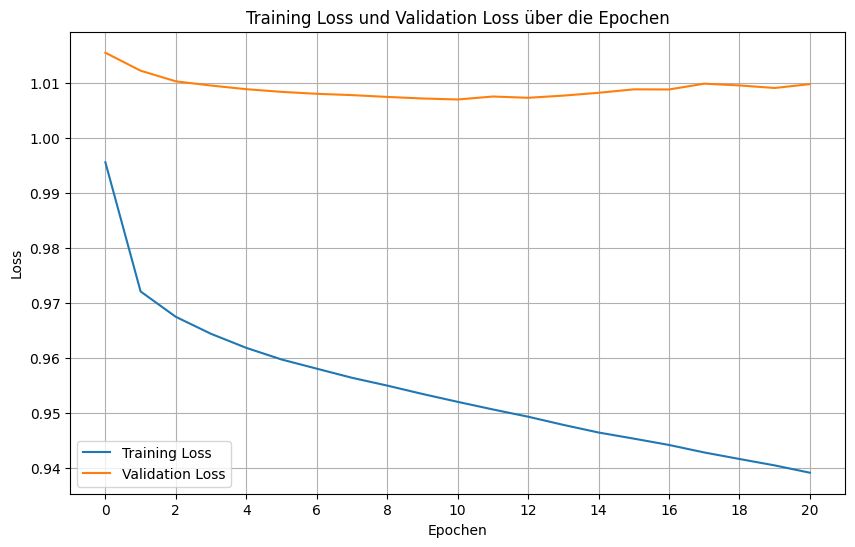

In [ ]:
# Reproduzierbarkeit sicherstellen
random.seed(seed)

# Modellarchitektur festlegen
# Eingaben definieren
input_features = tf.keras.Input(shape=(X_train_neural_net.shape[1],), name='features')
input_exposure = tf.keras.Input(shape=(1,), name='exposure')

# Zwei Hidden Layers
x = tf.keras.layers.Dense(32, activation='relu')(input_features)
x = tf.keras.layers.Dense(16, activation='relu')(x)

# Lineare Ausgabe für log(Frequenz)
pred_log_freq = tf.keras.layers.Dense(1, activation='linear', name='pred_log_freq')(x)

# Log(Frequenz) in Frequenz umwandeln
pred_freq = tf.keras.layers.Lambda(lambda z: tf.exp(z), name='pred_freq')(pred_log_freq)

# Mit Exposure multiplizieren, um prognostizierte Schadenanzahlen zu erhalten
pred_claims = tf.keras.layers.Multiply(name='pred_claims')([pred_freq, input_exposure])

# Modell erstellen
neural_net = tf.keras.Model(inputs=[input_features, input_exposure], outputs=pred_claims)

# Modellzusammenfassung
print("Architektur des künstlichen neuronalen Netzes:\n")
neural_net.summary()


# Definiere den Optimierer
optimizer = tf.keras.optimizers.AdamW(learning_rate=0.001, weight_decay=0.0001, clipnorm=1.0)

# Definiere Early Stopping Callback
early_stopping = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

# Modell kompilieren, Poisson-Negativloglikelihood als Verlustfunktion
neural_net.compile(optimizer=optimizer, loss=tf.keras.losses.Poisson())

# Startzeit messen
start_time_neural_net = time.time()

# Modell trainieren
neural_net_training = neural_net.fit(
    {'features': X_train_neural_net, 'exposure': expo_train},
    y_train,
    epochs=100,
    batch_size=64,
    validation_data=({'features': X_val_neural_net, 'exposure': expo_val}, y_val),
    callbacks=[early_stopping],
    verbose=0 # Ausführliche Ausgabe unterdrücken
)

# Endzeit messen und Modellierungszeit berechnen
end_time_neural_net = time.time()
modeling_time_neural_net = end_time_neural_net - start_time_neural_net

print(f"\nBenötigte Zeit für die Modellierung: {modeling_time_neural_net:.2f} Sekunden\n")

# Modellvorhersagen berechnen
pred_train_neural_net = neural_net.predict({'features': X_train_neural_net, 'exposure': expo_train}, verbose=0).flatten()
pred_val_neural_net = neural_net.predict({'features': X_val_neural_net, 'exposure': expo_val}, verbose=0).flatten()
pred_test_neural_net = neural_net.predict({'features': X_test_neural_net, 'exposure': expo_test}, verbose=0).flatten()

# Poisson-Devianz auf den Trainings- und Validierungsdaten ausgeben
evaluate_poisson_deviance_train_val(pred_train_neural_net, y_train, expo_train,
                                      pred_val_neural_net, y_val, expo_val)

# Plotten der Loss-Kurven
print()
plt.figure(figsize=(10, 6))
plt.plot(neural_net_training.history['loss'], label='Training Loss')
plt.plot(neural_net_training.history['val_loss'], label='Validation Loss')
plt.title('Training Loss und Validation Loss über die Epochen')
plt.xlabel('Epochen')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.xticks(np.arange(0, len(neural_net_training.history['loss']), 2))
plt.show()

Während der Loss auf den Trainingsdaten mit steigender Epochenzahl kontinuierlich abnimmt, ist dies bei den Validierungsdaten schnell nicht mehr der Fall, sodass das Training aufgrund von Early Stopping bereits nach sehr wenigen Epochen beendet wird.
Da das neuronale Netz auf den Validierungsdaten eine geringere Poisson-Devianz als das Intercept-Only-Modell aufweist, ist die Anforderung bereits beim ersten Versuch erfüllt und wir nehmen es in die Ergebnisdatenstruktur auf.

In [ ]:
# Ergebnisse des Neural Net in die Ergebnisdatenstruktur speichern
evaluate_and_store_model_result('Neural Net',
                                  pred_train_neural_net, y_train, expo_train,
                                  pred_val_neural_net, y_val, expo_val,
                                  pred_test_neural_net, y_test, expo_test,
                                  0, modeling_time_neural_net)

# die aktualisierte Ergebnisdatenstruktur anzeigen
print("Aktualisierte Ergebnisdatenstruktur:")
display_model_results()

Aktualisierte Ergebnisdatenstruktur:


Model,Train_Metric,Validation_Metric,Test_Metric,Optimization_Time,Modeling_Time
Intercept-Only,3.6515,3.7541,3.7054,0.00,0.04
GLM,3.5349,3.6313,3.6141,0.00,0.07
Elastic Net,3.5350,3.6312,3.6136,301.84,11.71
Neural Net,3.4479,3.6270,3.6136,0.00,11.62


Das künstliche neuronale Netz weist bei der längsten Modellierungszeit auf den Trainingsdaten klar die geringste Poisson-Devianz auf, während es das GLM auf den Validierungsdaten immerhin noch knapp schlägt.
Die Generalisierungslücke ist damit etwas größer als bei den anderen Modellen und zusammen mit den obigen Losskurven erkennen wir durchaus leichtes Overfitting, welches durch Early Stopping aber gut genug kontrolliert wird.

## Aufgabe B2: Ensemble-Modelle für die Schadenhäufigkeit

**Ziel von Aufgabe B2 ist es, die Schadenanzahl bzw. Schadenfrequenz (*Frequency*) mit Ensemble-Modellen zu
modellieren.**

### a) Ensemble-Methoden Bagging und Random Forest

**Erläutern Sie kurz die Funktionsweise von Bagging
und Random Forest, arbeiten Sie Gemeinsamkeiten und Unterschiede heraus und begründen Sie, warum
Ensemble-Methoden bei hochdimensionalen Datensätzen vorteilhaft sein können. Trainieren Sie beide Modelle
unter Berücksichtigung der Poisson-Natur der Zielgröße:**

* **Bagging: Alle Features stehen bei jedem Split zur Verfügung.**
* **Random Forest: Verwenden Sie bei jedem Split nur eine zufällige Teilmenge der Features (z.B. Quadratwurzel
der Gesamtzahl).**

**Wählen Sie ein geeignetes Split-Kriterium, integrieren Sie die *Exposure*-Variable angemessen und definieren
Sie geeignete Hyperparameter (Anzahl Bäume, maximale Tiefe, minimale Beobachtungen pro Blatt).
Begründen Sie Ihre Entscheidungen kurz. Berechnen Sie die Poisson-Devianz auf Trainings- und Validierungsdaten
für beide Modelle, fügen Sie die Ergebnisse der Ergebnisdatenstruktur hinzu und dokumentieren
Sie die Trainingszeit. Erstellen Sie Feature-Importance-Plots für beide Modelle nebeneinander und
visualisieren Sie jeweils die Top-15 wichtigsten Features. Vergleichen und interpretieren Sie die Ergebnisse
(Übereinstimmungen, Rangfolgen, mögliche Gründe).**

***Hinweis: Für die volle Punktzahl sollten beide Modelle mindestens so gut sein wie das GLM aus Teilaufgabe
B1 d).***

Beim Bagging (Bootstrap Aggregation) werden mehrere Stichproben mit Zurücklegen (Bootstrap) aus dem Datensatz gezogen, auf denen jeweils ein eigenständiges Modell (meistens in Form eines Entscheidungsbaums) trainiert wird.
Die finale Vorhersage ist dann der Durchschnitt (bei Regression) oder die Mehrheitsentscheidung (bei Klassifikation) aller Einzelmodelle.
Bei weiterhin geringem Bias wird die hohe Varianz der einzelnen Schätzer durch die Aggregation reduziert.
Gerade wenn es dominante Features im Datensatz gibt und sich die Modelle dadurch nicht genug unterscheiden, reicht diese Vorgehensweise aber mitunter nicht aus.

Random Forest stellt daher eine Weiterentwicklung von Bagging mit Entscheidungsbäumen dar, bei welcher in jedem Split eines einzelnen Baums statt des gesamten Featureraums nur eine zufällige Auswahl berücksichtigt wird.
Hierdurch entstehen deutlich vielfältigere Einzelschätzer und die Varianzreduktion fällt stärker aus als bei reinem Bagging, was häufig zu besserer Generalisierung führt.

Während komplexe Einzelmodelle in Datensätzen mit sehr vielen Merkmalen schnell zum Overfitting neigen, erweisen sich Ensemble-Methoden hier als vorteilhaft, weil durch die Mittelung vieler Modelle die Varianz reduziert und die Robustheit gegenüber verrauschten Daten und Ausreißern erhöht wird.
Gerade Algorithmen wie Random Forest, welche bei der Erstellung der Einzelschätzer mit zufälligen Teilmengen von Features arbeiten, können trotz der hohen Dimensionalität starke Muster identifizieren und irrelevante Merkmale ignorieren.
Gleichzeit erhalten auf diese Weise auch schwächere, aber nützliche Variablen eine Chance, zur Vorhersage beizutragen.

Für die Ensemble-Verfahren benutzen wir erneut alle verfügbaren Features, wobei wir aufgrund der geringen Zahl an Ausprägungen die One-Hot-Kodierung der kategorialen Merkmale benutzen.
Wegen der Funktionsweise von Entscheidungsbäumen mit Splits ist eine Standardisierung nicht notwendig.
Da die gängigen Standardbibliotheken für Bagging und Random Forest keine Möglichkeit anbieten, das Exposure als Offset zu berücksichtigen, modellieren wir als Zielgröße diesmal die Schadenfrequenz und verwenden das Exposure als Gewicht.
Anschließend kann aus der prognostizierten Schadenfrequenzen durch Multiplikation mit dem Exposure wieder auf die Schadenanzahlen übergegangen werden.

In [ ]:
# Auswahl der Features für Bagging und Random Forest
X_train_ensemble = data_train[var_num + var_cat_oh].copy()
X_val_ensemble = data_val[var_num + var_cat_oh].copy()
X_test_ensemble = data_test[var_num + var_cat_oh].copy()

Da im Kontext des Split-Kriteriums die Zielvariable implizit mit dem Gewicht multipliziert wird, befinden wir uns hier effektiv wieder in einem Setting mit Schadenanzahlen und entscheiden uns für die Poisson-Devianz.
Vor dem Hintergrund der Größe unserer Trainingsdaten wählen wir für das Bagging-Modell im Sinne stabiler Ratenschätzungen 10 als maximale Baumtiefe und 50 als minimale Anzahl von Beobachtungen pro Blatt.
Prinzipiell führt eine sehr hohe Baumanzahl aufgrund der Durchschnittsbildung in der Regel nicht zu problematischem Overfitting, im Sinne einer moderaten Laufzeit entscheiden wir uns für 500 Bäume.

In [ ]:
# Basis Estimator für das Bagging-Modell
# Poisson-Devianz als Split-Kriterium, per Default werden in jedem Split alle übergebenen Features verwendet
base_estimator_bagging = sklearn.tree.DecisionTreeRegressor(
    max_depth=10,
    min_samples_leaf=50,
    criterion='poisson',
    random_state=seed
)

# Bagging Regressor definieren
bagging_model = sklearn.ensemble.BaggingRegressor(
    estimator=base_estimator_bagging,
    n_estimators=500,
    max_features=1.0, # bei jedem Baum alle Features verwenden
    random_state=seed,
    n_jobs=-1 # alle verfügbaren Kerne für schnellere Berechnung nutzen
)

# Startzeit messen
start_time_bagging = time.time()

# Bagging Modell auf Frequenzen mit Exposure als Gewicht trainieren
bagging_model.fit(X_train_ensemble, y_freq_train.values.ravel(), sample_weight=expo_train.values.ravel())

# Endzeit messen und Modellierungszeit berechnen
end_time_bagging = time.time()
modeling_time_bagging = end_time_bagging - start_time_bagging

print(f"Benötigte Zeit für die Modellierung des Bagging-Modells: {modeling_time_bagging:.2f} Sekunden\n")

# Frequenz-Vorhersagen generieren
pred_freq_train_bagging = bagging_model.predict(X_train_ensemble)
pred_freq_val_bagging = bagging_model.predict(X_val_ensemble)
pred_freq_test_bagging = bagging_model.predict(X_test_ensemble)

# Sicherstellen, dass Frequenzen nicht negativ sind
pred_freq_train_bagging = np.maximum(pred_freq_train_bagging, 0)
pred_freq_val_bagging = np.maximum(pred_freq_val_bagging, 0)
pred_freq_test_bagging = np.maximum(pred_freq_test_bagging, 0)

# durch Multiplikation mit dem Exposure auf Schadenanzahlen übergehen
pred_claims_train_bagging = pred_freq_train_bagging * expo_train.values.ravel()
pred_claims_val_bagging = pred_freq_val_bagging * expo_val.values.ravel()
pred_claims_test_bagging = pred_freq_test_bagging * expo_test.values.ravel()

# Poisson-Devianz auf den Trainings- und Validierungsdaten ausgeben
evaluate_poisson_deviance_train_val(
    pred_claims_train_bagging, y_train, expo_train,
    pred_claims_val_bagging, y_val, expo_val
)

Benötigte Zeit für die Modellierung des Bagging-Modells: 17.33 Sekunden

Poisson-Devianz auf den Trainingsdaten: 3.2578
Poisson-Devianz auf den Validierungsdaten: 3.6243


Die Poisson-Devianz des Bagging-Modells auf den Validierungsdaten ist kleiner als die des GLM und die Mindestanforderung daher erfüllt.
Da die Hyperparametereinstellungen gut funktioniert haben, übernehmen wir diese für den Random Forest.
Als der entscheidende Unterschied wird nun aber bei jedem Split innerhalb eines Baums nur noch eine zufällige Teilmenge der insgesamt 15 Features verwendet.
Eine gängige Größenordnung für die Anzahl der dabei jeweils betrachteten Merkmale ist $\sqrt{15}\approx4$.

In [ ]:
# Random Forest Regressor definieren
# Poisson-Devianz als Split-Kriterium, in jedem Split werden nur vier zufällige Features verwendet
random_forest_model = sklearn.ensemble.RandomForestRegressor(
    n_estimators=500,
    max_features=4,
    max_depth=10,
    min_samples_leaf=50,
    criterion='poisson',
    random_state=seed,
    n_jobs=-1 # alle verfügbaren Kerne für schnellere Berechnung nutzen
)

# Startzeit messen
start_time_random_forest = time.time()

# Random Forest auf Frequenzen mit Exposure als Gewicht trainieren
random_forest_model.fit(X_train_ensemble, y_freq_train.values.ravel(), sample_weight=expo_train.values.ravel())

# Endzeit messen und Modellierungszeit berechnen
end_time_random_forest = time.time()
modeling_time_random_forest = end_time_random_forest - start_time_random_forest

print(f"\nBenötigte Zeit für die Modellierung des Random Forest: {modeling_time_random_forest:.2f} Sekunden\n")

# Frequenz-Vorhersagen generieren
pred_freq_train_random_forest = random_forest_model.predict(X_train_ensemble)
pred_freq_val_random_forest = random_forest_model.predict(X_val_ensemble)
pred_freq_test_random_forest = random_forest_model.predict(X_test_ensemble)

# Sicherstellen, dass Frequenzen nicht negativ sind
pred_freq_train_random_forest = np.maximum(pred_freq_train_random_forest, 0)
pred_freq_val_random_forest = np.maximum(pred_freq_val_random_forest, 0)
pred_freq_test_random_forest = np.maximum(pred_freq_test_random_forest, 0)

# durch Multiplikation mit dem Exposure auf Schadenanzahlen übergehen
pred_claims_train_random_forest = pred_freq_train_random_forest * expo_train.values.ravel()
pred_claims_val_random_forest = pred_freq_val_random_forest * expo_val.values.ravel()
pred_claims_test_random_forest = pred_freq_test_random_forest * expo_test.values.ravel()

# Poisson-Devianz auf den Trainings- und Validierungsdaten ausgeben
evaluate_poisson_deviance_train_val(
    pred_claims_train_random_forest, y_train, expo_train,
    pred_claims_val_random_forest, y_val, expo_val
)



Benötigte Zeit für die Modellierung des Random Forest: 4.10 Sekunden

Poisson-Devianz auf den Trainingsdaten: 3.3355
Poisson-Devianz auf den Validierungsdaten: 3.6144


Im Vergleich zum reinen Bagging-Modell ergibt sich das recht typische Bild, dass der Random Forest auf den Trainingsdaten zwar die schlechtere Performance hat, dafür aber besser generalisiert und damit insbesondere auch unseren Anforderungen genügt.
Wir nehmen daher beide Modelle in die Ergebnisdatenstruktur auf.

In [ ]:
# Ergebnisse der Ensemble-Modelle in die Ergebnisdatenstruktur speichern
evaluate_and_store_model_result(
    'Bagging',
    pred_claims_train_bagging, y_train, expo_train,
    pred_claims_val_bagging, y_val, expo_val,
    pred_claims_test_bagging, y_test, expo_test,
    0, modeling_time_bagging
)

evaluate_and_store_model_result(
    'Random Forest',
    pred_claims_train_random_forest, y_train, expo_train,
    pred_claims_val_random_forest, y_val, expo_val,
    pred_claims_test_random_forest, y_test, expo_test,
    0, modeling_time_random_forest
)

# aktualisierte Ergebnisdatenstruktur anzeigen
print("Aktualisierte Ergebnisdatenstruktur:")
display_model_results()

Aktualisierte Ergebnisdatenstruktur:


Model,Train_Metric,Validation_Metric,Test_Metric,Optimization_Time,Modeling_Time
Intercept-Only,3.6515,3.7541,3.7054,0.00,0.04
GLM,3.5349,3.6313,3.6141,0.00,0.07
Elastic Net,3.5350,3.6312,3.6136,301.84,11.71
Neural Net,3.4479,3.6270,3.6136,0.00,11.62
Bagging,3.2578,3.6243,3.6072,0.00,17.33
Random Forest,3.3355,3.6144,3.6024,0.00,4.10


Zum Abschluss visualisieren wir für beide Modelle die Gini Feature Importance unserer 15 Merkmale.
Alternativ wird häufig auch noch die rechenintensivere Permutation Importance betrachtet.

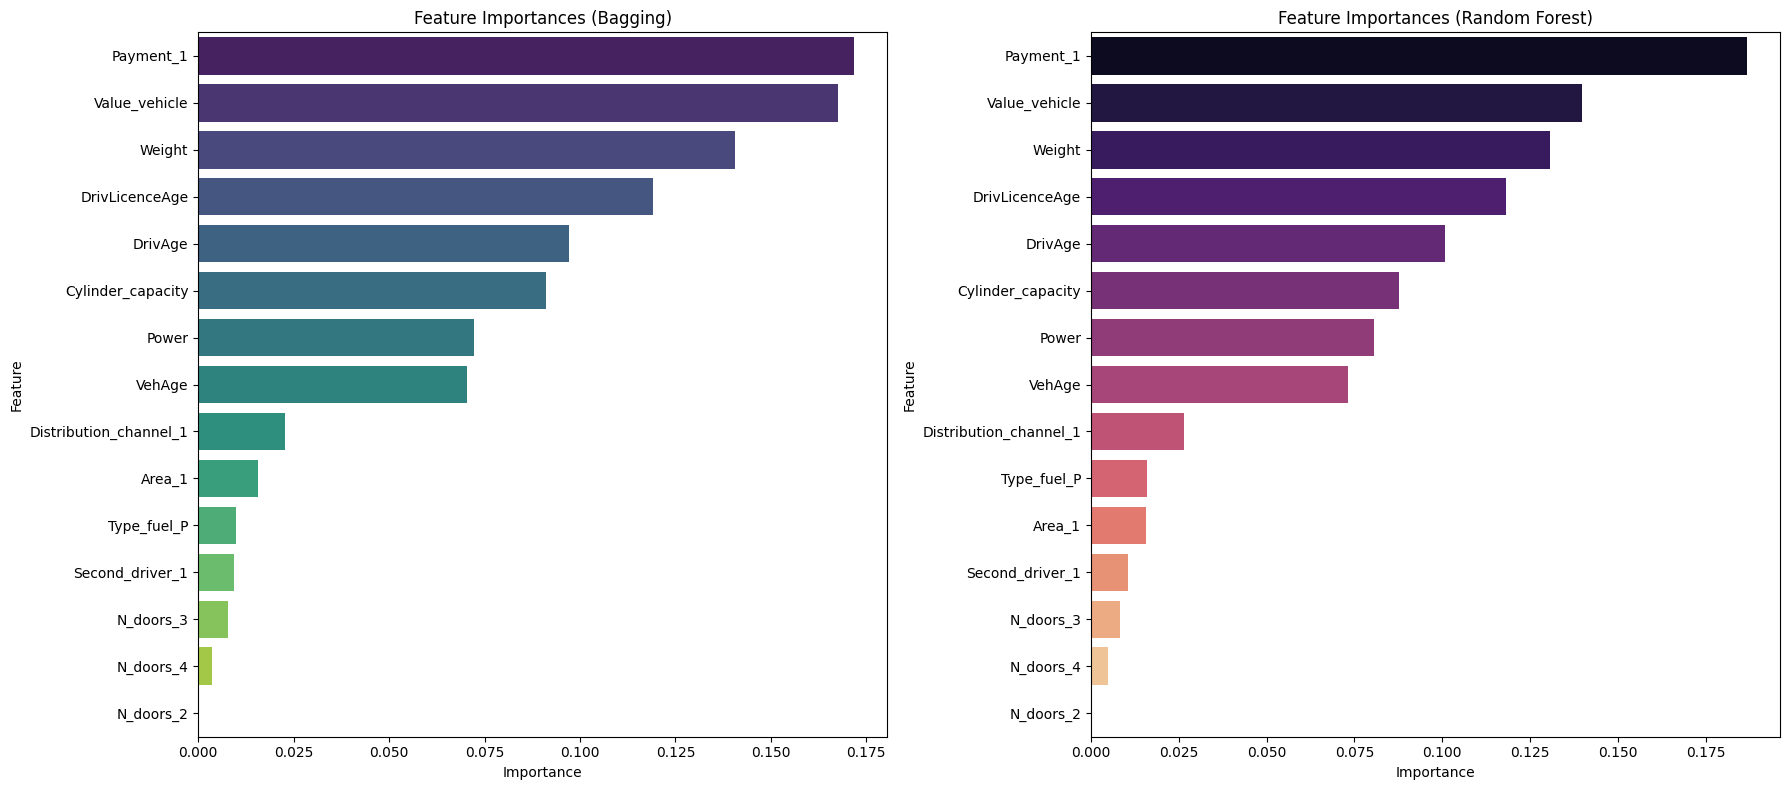

In [ ]:
# Feature Importances über alle Basis-Estimator des Bagging-Modells aggregieren
aggregated_bagging_importances = np.mean([
    estimator.feature_importances_ for estimator in bagging_model.estimators_
], axis=0)

# Feature Importances aus Random Forest-Modell extrahieren (bereits aggregiert)
random_forest_importances = random_forest_model.feature_importances_

feature_names = X_train_ensemble.columns

# DataFrames für die Feature Importances erstellen
feature_names = X_train_ensemble.columns

bagging_feature_importance = pd.DataFrame({
    'Feature': feature_names,
    'Importance': aggregated_bagging_importances
}).sort_values(by='Importance', ascending=False).reset_index(drop=True)

random_forest_feature_importance = pd.DataFrame({
    'Feature': feature_names,
    'Importance': random_forest_importances
}).sort_values(by='Importance', ascending=False).reset_index(drop=True)

# Plots erstellen
fig, axes = plt.subplots(1, 2, figsize=(18, 8))

sns.barplot(x='Importance', y='Feature', data=bagging_feature_importance, ax=axes[0], palette='viridis')
axes[0].set_title('Feature Importances (Bagging)')
axes[0].set_xlabel('Importance')
axes[0].set_ylabel('Feature')
axes[0].tick_params(axis='y', labelsize=10)

sns.barplot(x='Importance', y='Feature', data=random_forest_feature_importance, ax=axes[1], palette='magma')
axes[1].set_title('Feature Importances (Random Forest)')
axes[1].set_xlabel('Importance')
axes[1].set_ylabel('Feature')
axes[1].tick_params(axis='y', labelsize=10)

plt.tight_layout()
plt.show()

Die beiden Feaature-Importance-Plots ähneln einander sehr stark und weisen bis auf die Vertauschung von 'Area_1' und 'Type_fule_P' überall dieselbe Reihenfolge auf.
'Payment_1' sowie demografische und Fahrzeugmerkmale kristallisieren sich jeweils als die wichtigsten Variablen heraus, während die restlichen kategorialen Features unten in der Rangliste stehen.
Als einen feinen, aber typischen Unterschied erkennen wir, dass sich bei Random Forest die Wichtigkeit gerade bei den korrelierten Fahrzeugmerkmalen tendenziell etwas breiter verteilt, da die stärksten dieser Variablen nicht bei jedem Split zur Verfügung stehen und so z.B. auch 'Type_fule_P' öfter eine Chance hat.
Die offensichtlich stark erkärende und von den restlichen Merkmalen weniger abhängige Variable 'Payment_1' gewinnt hingegen beim Auftreten in einem Feature Subset weiterhin sehr häufig, auch wenn zuvor bereits mehrere Splits durchgeführt wurden, was den größeren Abstand bei Random Forest erklärt.
Interessant ist zuletzt noch ein kurzer Vergleich zum von linearen Zusammenhängen geprägten GLM, denn von den dort als nicht-signifikant identifizierten Variablen haben die einzelnen Türenanzahlen hier zwar ebenfalls die niedrigste Wichtigkeit, das Fahrzeugalter und vor allem der Fahrzeugwert erweisen sich bei den Ensemble-Verfahren hingegen als sehr bedeutsame erklärende Merkmale.

### b) Gradient Boosting – LightGBM und XGBoost

**Erläutern Sie den fundamentalen Unterschied zwischen
dem Resampling-Ansatz von Random Forest (Bootstrap Aggregation) und Gradient Boosting (sequenzielles
Lernen). Gehen Sie auf Bias-Variance-Trade-off, Trainingszeit/Parallelisierbarkeit und Overfitting-
Robustheit ein. Arbeiten Sie die wesentlichen Unterschiede zwischen LightGBM und XGBoost heraus und
begründen Sie, warum beide Verfahren für hochdimensionale Datensätze geeignet sind. Führen Sie für
beide Modelle eine systematische Hyperparametersuche durch (z. B. Optuna, Grid Search oder Random
Search). Wählen Sie geeignete Parameterbereiche (z.B. Learning Rate, Anzahl Bäume, Baumtiefe, Regularisierung,
Subsampling sowie verfahrensspezifische Parameter), begründen Sie die Wahl und nutzen
Sie die Poisson-Devianz auf dem Validierungsdatensatz als Optimierungskriterium. Integrieren Sie die
*Exposure*-Variable angemessen in das Training. Dokumentieren Sie die Anzahl der Trials sowie die Optimierungszeit
und stellen Sie die besten Hyperparameter-Kombinationen tabellarisch dar. Trainieren Sie
die finalen Modelle mit den optimalen Hyperparametern, berechnen Sie die Poisson-Devianz auf Trainingsund
Validierungsdaten, fügen Sie die Ergebnisse der Ergebnisdatenstruktur hinzu und dokumentieren Sie
die Trainingszeit beider Verfahren. Erstellen Sie Feature-Importance-Plots für LightGBM und XGBoost nebeneinander
und visualisieren Sie jeweils die Top-15 wichtigsten Features (mit unterschiedlichen Farben).
Identifizieren und interpretieren Sie Gemeinsamkeiten und Unterschiede in der Rangfolge.**

***Hinweis: Für die volle Punktzahl sollten beide Modelle mindestens so gut sein wie das GLM aus Teilaufgabe
B1 d).***

Random Forest und Gradient Boosting unterscheiden sich fundamental in ihrer Strategie:
Random Forest erzeugt parallel viele tiefe, überangepasste und möglichst unabhängige Bäume, indem diese auf unterschiedlichen Stichproben trainiert werden und bei den einzelnen Splits jeweils nur wenige zufällige Merkmale zur Verfügung stehen, und ermittelt das Endergebnis mittels Durchschnittsbildung.
Gradient Boosting baut hingegen sequentiell flache, schwache Bäume nacheinander.
Jeder neue Schätzer versucht, den Fehler der Summe aller vorherigen Bäume durch Gradientenabstieg zu korrigieren, und geht dann ebenfalls (beschränkt durch eine Lernrate) additiv in die neue Gesamtschätzung ein.

Da die einzelnen Bäume unabhängig voneinander trainiert werden können, ist Random Forest exzellent parallelisierbar und das Training geht meist sehr schnell.
Die tiefen Bäume weisen dabei zunächst einen niedrigen Bias, aber hohe Varianz auf.
Erst durch die Mittelung vieler dekorrelierter Bäume reduziert Random Forest die Varianz drastisch.
Dieses Vorgehen führt auch dazu, dass das Hinzufügen von mehr Schätzern dem Modell dem Modell in der Regel nicht schadet.
Es konvergiert lediglich gegen einen stabilen Fehlerwert und ist damit sehr robust gegen Overfitting.

Bei Gradient Boosting sind die Bäume dagegen einzeln absichtlich schwach und weisen eine hohen Bias bei niedriger Varianz auf.
Durch das schrittweise Korrigieren der Residuen wird der Bias des Gesamtschätzers systematisch immer weiter reduziert, wobei die Varianz durch Regularisierung (z.B. Anwenden einer Lernrate) kontrolliert wird.
Diese Vorgehensweise macht Gradient Boosting deutlich anfälliger für Overfitting, da das Modell bei zu vielen Iterationen irgendwann anfängt, das Rauschen in den Trainingsdaten auswendig zu lernen.
Daher ist oft eine sorgfältige Hyperparameter-Optimierung unter Einbezug von Validierungsdaten erforderlich.
Da das Fitten eines Baumes vom Fehler aller bisheriger Schätzer abhängt, ist der grundsätzliche Prozess bei Gradient Boosting schlecht parallelisierbar und die Trainingszeit hoch.
Lediglich die Suche nach Splits innerhalb eines Baumes kann von modernen Bibliotheken parallelisiert werden.

XGBoost (Extreme Gradient Boosting) und LightGBM (Light Gradient Boosting Machine) sind solche hocheffizienten Implementierungen von Gradient Boosting, welche sich aber massiv in ihrer Strategie unterscheiden, wie sie Bäume wachsen lassen.
XGBoost geht Level-wise vor, die Bäume wachsen Ebene für Ebene und sind daher meist ausgewogener und weniger tief.
Bei LigthGBM ist das Wachstum dagegen Leaf-wise implementiert und Bäume werden zuerst an dem Blatt weitergebaut, wo gerade am meisten Fehler reduziert werden kann, wodurch leichter komplexe (und damit manchmal überangepasste) Bäume entstehen können.
Die unterschiedlichen Vorgehensweisen haben zur Folge, dass LightGBM meist schneller ist und weniger Speicher benötigt, besonders bei großen Datenmengen und sehr vielen, vor allem spärlich besetzten Merkmalen.
Durch das Leaf-wise Wachstum neigt LightGBM dafür gerade bei kleinen Datensätzen eher zu Overfitting und muss durch sorgfältiges Einstellen der Hyperparameter begrenzt werden, damit das Modell nicht zu komplex wird.
XGBoost stellt hingegen die etwas konservativere Wahl dar und ist in der Regel etwas langsamer, aber ebenfalls gut für große Daten geeignet.
Das Paket bietet viele verschiedene Einstellungen, um Überanpassung zu verhindern (z.B. spezielle Strafen für zu komplexe Bäume), und ist auch bei kleinen Datenmengen tendenziell robuster.

Beide Verfahren sind durch ihre effiziente Programmierung gut für hochdimensionale Daten geeignet.
Die Suche nach Splits innerhalb eines Baums wird bestmöglich parallelisiert und neben einem Histogramm-basierten Vorgehen mittels Binning von numerischen Merkmalen werden Spalten-/ und Zeilen-Subsampling unterstützt, was neben Laufzeit und Speicher auch die Varianz reduziert.
Beide Modelle erkennen dünn besetzte Variablen und behandeln diese in ihren Abläufen dadurch sehr effizient, so fasst LightGBM etwa sich gegenseitig ausschließende Merkmale (z.B. Dummy-Variablen) mittels Effective Feature Bundling zusammen, was die effektive Anzahl der Dimensionen drastisch reduzieren kann.
Zuletzt entsteht beim Boosting durch eingebaute Regularisierungstechniken wie L1- oder L2-Strafen in der Zielfunktion faktisch ein starkes eingebautes Feature-Selection-Verhalten.

Wir führen für beide Verfahren eine systematische Hyperparametersuche durch. Wie bei den Ensemble-Methoden benutzen wir alle numerischen und One-Hot-kodierten kategorialen Merkmale ohne Standardisierung, wählen die Schadenfrequenz als Zielvariable und gewichten mit dem Exposure.

In [ ]:
# Auswahl der Features für LightGBM und XGBoost
X_train_boosting = data_train[var_num + var_cat_oh].copy()
X_val_boosting = data_val[var_num + var_cat_oh].copy()
X_test_boosting = data_test[var_num + var_cat_oh].copy()

Wir führen beispielhaft eine Random Search mit 200 Trials durch, was im Vergleich zu einer vollständigen Grid Search massiv Rechenzeit einspart und für unsere Zwecke genau genug sein dürfte.
Wir legen hierzu für die wichtigsten Hyperparameter einen ersten diskreten Suchbereich fest.
Falls bei einzelnen Parametern bestimmte Werte (insbesondere am Rand) die besten Ergebnisse dominieren, können die Einstellungen entsprechend angepasst und eine neue Optimierung durchgeführt werden.
Als Optimierungskriterium dient die Poisson-Devianz auf den Validierungsdaten.

Wir starten mit LightGBM und verwenden kleine und damait robustere Lernraten zwischen 0,01 und 0,1.
In der Regel werden bei kleinerer Lernrate mehr Bäume benötigt, was wiederum die Trainingszeit erhöht.
Wir betrachten Werte zwischen 100 und 500, alternativ bietet sich bei Anwendung von Early Stopping an, diese Anzahlen großzügig höher zu setzen.

Da die Bäume bei LightGBM Leaf-wise wachsen, ist die maximale Anzahl an Blättern 'num_leaves' der wichtigste Parameter zur Kontrolle der Baumkomplexität, welchen wir zwischen 15 und 63 variieren. Zusätzlich begrenzen wir die Überanpassung durch die maximale Baumtiefe 'max_depth' (wobei möglichst $\text{num_leaves} < 2^\text{max_depth}$ gelten sollte) und die minimale Anzahl an Beobachtungen in einem Blatt 'min_child_samples'.
Wir beginnen mit Werten zwischen 3 und 9 bzw. 10 und 100.

Um die Diversität der Bäume zu erhöhen und damit das Modell robuster zu machen, verwenden wir bei jedem Baum Feature-Subsampling und Row-Subsampling, wobei wir aufgrund der eher geringen Anzahl an Features und Datensätzen den jeweils zur Verfügung stehenden Anteil nicht kleiner als 70% werden lassen.
Über 'subsample_freq' stellen wir zusätzlich ein, ob das Row-Subsampling nach einer, drei oder fünf Iterationen erneut durchgeführt werden soll.

Zuletzt variieren wir wir mit den Parametern 'reg_alpha' bzw. 'reg_lambda' zwischen 0 und 5, wie stark eine L1- bzw. L2-Regularisierung in der Verlustfunktion berücksichtigt wird.

In [ ]:
# Definiere die Parameterbereiche für die LightGBM Random Search
parameters_lightgbm = {
    'learning_rate': [0.01, 0.03, 0.05, 0.1],
    'n_estimators': [100, 200, 300, 400, 500],
    'num_leaves': [15, 31, 63],
    'max_depth': [3, 5, 7, 9],
    'min_child_samples': [10, 20, 50, 100],
    'colsample_bytree': [0.7, 0.8, 0.9, 1.0],
    'subsample': [0.7, 0.8, 0.9, 1.0],
    'subsample_freq': [1, 3, 5],
    'reg_alpha': [0, 0.1, 1, 5],
    'reg_lambda': [0, 0.1, 1, 5]
}

# Anzahl der zufälligen Parameterkombinationen, die getestet werden sollen
n_trials = 200

# Speichervariablen für die besten Ergebnisse
best_lightgbm_params = None
best_lightgbm_validation_deviance = np.inf
all_lightgbm_grid_results = []

# Reproduzierbarkeit der Parameterwahl sicherstellen
random.seed(seed)

# Startzeit messen
start_time_lightgbm_grid = time.time()

# Manuelle Randomized Search Schleife
for i in range(n_trials):
    # Zufällige Hyperparameter-Kombination auswählen
    params = {k: random.choice(v) for k, v in parameters_lightgbm.items()}

    # LGBMRegressor mit Regression-Objective initialisieren
    lightgbm_model = lgb.LGBMRegressor(objective='poisson', # Poisson-Verlustfunktion
                                   random_state=seed,
                                   n_jobs=-1, # alle verfügbaren Kerne für schnellere Berechnung nutzen
                                   verbose=-1, # ausführliche Ausgabe unterdrücken
                                   **params)

    # Modell trainieren: Frequenz als Zielvariable, Exposure als Gewicht
    lightgbm_model.fit(X_train_boosting, y_freq_train.values.ravel(),
                       sample_weight=expo_train.values.ravel())

    # Frequenzen auf den Validierungsdaten vorhersagen
    pred_freq_val_lightgbm = lightgbm_model.predict(X_val_boosting)

    # Sicherstellen, dass Frequenzen nicht negativ sind
    pred_freq_val_lightgbm = np.maximum(pred_freq_val_lightgbm, 0)

    # Frequenzen in Schadenanzahlen umrechnen für die Devianzberechnung
    pred_claims_val_lightgbm = pred_freq_val_lightgbm * expo_val.values.ravel()

    # Poisson-Devianz auf Validierungsdaten berechnen
    current_validation_deviance = calculate_poisson_deviance(pred_claims_val_lightgbm, y_val, expo_val)

    # Ergebnis speichern
    all_lightgbm_grid_results.append({
        **params,
        'validation_deviance': current_validation_deviance
    })

    # Bestes Modell aktualisieren, falls aktuelle Devianz besser ist
    if current_validation_deviance < best_lightgbm_validation_deviance:
        best_lightgbm_params = params
        best_lightgbm_validation_deviance = current_validation_deviance

# Endzeit messen und Optimierungszeit berechnen
end_time_lightgbm_grid = time.time()
time_lightgbm_grid = end_time_lightgbm_grid - start_time_lightgbm_grid

print(f"Benötigte Zeit für die LightGBM Random Search ({n_trials} Trials): {time_lightgbm_grid:.2f} Sekunden")

# Grid Search Ergebnisse tabellarisch darstellen
lightgbm_grid_results = pd.DataFrame(all_lightgbm_grid_results)
lightgbm_grid_results_sorted = lightgbm_grid_results.sort_values(by='validation_deviance').reset_index(drop=True)

print("\nBeste zehn Ergebnisse der LightGBM Random Search:")
display(lightgbm_grid_results_sorted.head(10).style.format({'validation_deviance': '{:.4f}'}).hide(axis='index'))

Benötigte Zeit für die LightGBM Random Search (200 Trials): 139.62 Sekunden

Beste zehn Ergebnisse der LightGBM Random Search:


learning_rate,n_estimators,num_leaves,max_depth,min_child_samples,colsample_bytree,subsample,subsample_freq,reg_alpha,reg_lambda,validation_deviance
0.030000,400,15,7,10,0.700000,0.800000,5,0.100000,0.000000,3.5858
0.030000,300,15,5,20,0.700000,0.800000,5,0.000000,5.000000,3.5926
0.030000,300,15,9,10,0.800000,0.900000,1,0.100000,0.100000,3.5949
0.100000,100,63,5,20,0.700000,0.900000,3,1.000000,5.000000,3.5961
0.030000,400,31,3,20,1.000000,0.800000,1,5.000000,1.000000,3.5976
0.100000,100,15,7,20,0.800000,0.800000,3,5.000000,1.000000,3.5980
0.030000,500,15,3,50,1.000000,0.700000,5,1.000000,0.000000,3.5988
0.050000,400,15,3,50,0.700000,1.000000,1,0.100000,1.000000,3.5992
0.030000,300,15,5,20,1.000000,1.000000,5,0.000000,5.000000,3.5995
0.010000,500,31,9,20,0.700000,0.700000,5,5.000000,5.000000,3.5996


Für XGBoost benutzen wir prinzipiell dieselben Parameter und Bereiche.
Da das Baumwachstum hier Level-wise implementiert ist, wird die Komplexität primär über 'max_depth' gesteuert und wir beschränken die Anzahl der Blätter nicht aktiv.
Der Parameter 'subsample_freq' entfällt ebenfalls, weil XGBoost diese Funktionalität nicht unterstützt und bei jeder Iteration eine neues Row-Subsampling durchführt.
Während bei LightGBM zu kleine Blätter über 'min_child_samples' verhindert werden, geschieht dies nun über den Parameter 'min_child_weight', welcher aber nich die Anzahl an Beobachtungen, sondern die Summe der zweiten Ableitung misst und daher einen anderen Wertebereich (typischerweise z.B. zwischen 1 und 20) benötigt.

In [ ]:
# Definiere die Parameterbereiche für die XGBoost Random Search
parameters_xgboost = {
    'learning_rate': [0.01, 0.03, 0.05, 0.1],
    'n_estimators': [100, 200, 300, 400, 500],
    'max_depth': [3, 5, 7, 9],
    'min_child_weight': [1, 5, 10, 20],
    'subsample': [0.7, 0.8, 0.9, 1.0],
    'colsample_bytree': [0.7, 0.8, 0.9, 1.0],
    'reg_alpha': [0, 0.1, 1, 5],
    'reg_lambda': [0, 0.1, 1, 5]
}

# Anzahl der zufälligen Parameterkombinationen, die getestet werden sollen
n_trials = 200

# Speichervariablen für die besten Ergebnisse
best_xgboost_params = None
best_xgboost_validation_deviance = np.inf
all_xgboost_grid_results = []

# Reproduzierbarkeit der Parameterwahl sicherstellen
random.seed(seed)

# Startzeit messen
start_time_xgboost_grid = time.time()

# Manuelle Randomized Search Schleife
for i in range(n_trials):
    # Zufällige Hyperparameter-Kombination auswählen
    params = {k: random.choice(v) for k, v in parameters_xgboost.items()}

    # XGBRegressor mit Regression-Objective initialisieren
    xgboost_model = xgb.XGBRegressor(objective='count:poisson', # Poisson-Verlustfunktion
                                   random_state=seed,
                                   n_jobs=-1, # alle verfügbaren Kerne für schnellere Berechnung nutzen
                                   **params)

    # Modell trainieren: Frequenz als Zielvariable, Exposure als Gewicht
    xgboost_model.fit(X_train_boosting, y_freq_train.values.ravel(),
                      sample_weight=expo_train.values.ravel()
                     )

    # Frequenzen auf den Validierungsdaten vorhersagen
    pred_freq_val_xgboost = xgboost_model.predict(X_val_boosting)

    # Sicherstellen, dass Vorhersagen nicht negativ sind
    pred_freq_val_xgboost = np.maximum(pred_freq_val_xgboost, 0)

    # Frequenzen in Schadenanzahlen umrechnen für die Devianzberechnung
    pred_claims_val_xgboost = pred_freq_val_xgboost * expo_val.values.ravel()

    # Poisson-Devianz auf Validierungsdaten berechnen
    current_validation_deviance = calculate_poisson_deviance(pred_claims_val_xgboost, y_val, expo_val)

    # Ergebnis speichern
    all_xgboost_grid_results.append({
        **params,
        'validation_deviance': current_validation_deviance
    })

    # Bestes Modell aktualisieren, falls aktuelle Devianz besser ist
    if current_validation_deviance < best_xgboost_validation_deviance:
        best_xgboost_params = params
        best_xgboost_validation_deviance = current_validation_deviance

# Endzeit messen und Optimierungszeit berechnen
end_time_xgboost_grid = time.time()
time_xgboost_grid = end_time_xgboost_grid - start_time_xgboost_grid

print(f"Benötigte Zeit für die XGBoost Random Search ({n_trials} Trials): {time_xgboost_grid:.2f} Sekunden")

# Grid Search Ergebnisse tabellarisch darstellen
xgboost_grid_results = pd.DataFrame(all_xgboost_grid_results)
xgboost_grid_results_sorted = xgboost_grid_results.sort_values(by='validation_deviance').reset_index(drop=True)

print("\nBeste zehn Ergebnisse der XGBoost Random Search:")
display(xgboost_grid_results_sorted.head(10).style.format({'validation_deviance': '{:.4f}'}).hide(axis='index'))

Benötigte Zeit für die XGBoost Random Search (200 Trials): 164.54 Sekunden

Beste zehn Ergebnisse der XGBoost Random Search:


learning_rate,n_estimators,max_depth,min_child_weight,subsample,colsample_bytree,reg_alpha,reg_lambda,validation_deviance
0.100000,100,3,10,0.700000,1.000000,0.000000,0.100000,3.5951
0.050000,300,3,10,0.800000,1.000000,0.000000,5.000000,3.5964
0.030000,300,5,10,0.900000,1.000000,5.000000,0.000000,3.5966
0.100000,200,3,20,0.900000,1.000000,5.000000,1.000000,3.5968
0.030000,300,5,1,0.900000,0.800000,0.100000,5.000000,3.5972
0.050000,300,3,10,0.700000,1.000000,0.100000,1.000000,3.5974
0.030000,500,3,5,0.900000,0.900000,5.000000,0.000000,3.5976
0.050000,400,3,10,0.700000,1.000000,1.000000,1.000000,3.5982
0.100000,100,5,10,0.700000,0.900000,0.100000,0.100000,3.5983
0.030000,400,5,20,0.900000,1.000000,1.000000,0.000000,3.5986


Tatsächlich hat die Random Search bei XGBoost etwas länger als bei LightGBM gedauert.
Bei beiden Verfahren fällt auf, dass tendenziell kleinere Bäume bevorzugt werden.
Wir trainieren nun mit den jeweils besten gefundenen Hyperparametern die finalen Modelle.

In [ ]:
# Finale Modelle fitten

# LightGBM
# Startzeit messen
start_time_lightgbm = time.time()

# Trainiere das finale LightGBM-Modell mit den optimalen Hyperparametern
lightgbm_model_final = lgb.LGBMRegressor(objective='poisson',
                                       random_state=seed,
                                       n_jobs=-1,
                                       verbose=-1,
                                       **best_lightgbm_params)

lightgbm_model_final.fit(X_train_boosting, y_freq_train.values.ravel(),
                         sample_weight=expo_train.values.ravel())

# Endzeit messen und Modellierungszeit berechnen
end_time_lightgbm = time.time()
modeling_time_lightgbm = end_time_lightgbm - start_time_lightgbm

print("Finales LightGBM-Modell:")
print("\nHyperparameter:")
for param, value in best_lightgbm_params.items():
    print(f"{param}: {value}")
print(f"\nBenötigte Zeit für die Modellierung: {modeling_time_lightgbm:.2f} Sekunden\n")

# Frequenz-Vorhersagen generieren
pred_freq_train_lightgbm = lightgbm_model_final.predict(X_train_boosting)
pred_freq_val_lightgbm = lightgbm_model_final.predict(X_val_boosting)
pred_freq_test_lightgbm = lightgbm_model_final.predict(X_test_boosting)

# Sicherstellen, dass Frequenzen nicht negativ sind
pred_freq_train_lightgbm = np.maximum(pred_freq_train_lightgbm, 0)
pred_freq_val_lightgbm = np.maximum(pred_freq_val_lightgbm, 0)
pred_freq_test_lightgbm = np.maximum(pred_freq_test_lightgbm, 0)

# durch Multiplikation mit dem Exposure auf Schadenanzahlen übergehen
pred_claims_train_lightgbm = pred_freq_train_lightgbm * expo_train.values.ravel()
pred_claims_val_lightgbm = pred_freq_val_lightgbm * expo_val.values.ravel()
pred_claims_test_lightgbm = pred_freq_test_lightgbm * expo_test.values.ravel()

# Poisson-Devianz auf den Trainings- und Validierungsdaten ausgeben
evaluate_poisson_deviance_train_val(
    pred_claims_train_lightgbm, y_train, expo_train,
    pred_claims_val_lightgbm, y_val, expo_val
)


# XGBoost
# Startzeit messen
start_time_xgboost = time.time()

# Trainiere das finale XGBoost-Modell mit den optimalen Hyperparametern
xgboost_model_final = xgb.XGBRegressor(objective='count:poisson',
                                       random_state=seed,
                                       n_jobs=-1,
                                       **best_xgboost_params)

xgboost_model_final.fit(X_train_boosting, y_freq_train.values.ravel(),
                        sample_weight=expo_train.values.ravel()
                       )

# Endzeit messen und Modellierungszeit berechnen
end_time_xgboost = time.time()
modeling_time_xgboost = end_time_xgboost - start_time_xgboost

print("________________________________________________________")
print("\nFinales XGBoost-Modell:")
print("\nHyperparameter:")
for param, value in best_xgboost_params.items():
    print(f"{param}: {value}")
print(f"\nBenötigte Zeit für die Modellierung: {modeling_time_xgboost:.2f} Sekunden\n")

# Frequenz-Vorhersagen generieren
pred_freq_train_xgboost = xgboost_model_final.predict(X_train_boosting)
pred_freq_val_xgboost = xgboost_model_final.predict(X_val_boosting)
pred_freq_test_xgboost = xgboost_model_final.predict(X_test_boosting)

# Sicherstellen, dass Frequenzen nicht negativ sind
pred_freq_train_xgboost = np.maximum(pred_freq_train_xgboost, 0)
pred_freq_val_xgboost = np.maximum(pred_freq_val_xgboost, 0)
pred_freq_test_xgboost = np.maximum(pred_freq_test_xgboost, 0)

# durch Multiplikation mit dem Exposure auf Schadenanzahlen übergehen
pred_claims_train_xgboost = pred_freq_train_xgboost * expo_train.values.ravel()
pred_claims_val_xgboost = pred_freq_val_xgboost * expo_val.values.ravel()
pred_claims_test_xgboost = pred_freq_test_xgboost * expo_test.values.ravel()

# Poisson-Devianz auf den Trainings- und Validierungsdaten ausgeben
evaluate_poisson_deviance_train_val(
    pred_claims_train_xgboost, y_train, expo_train,
    pred_claims_val_xgboost, y_val, expo_val
)

Finales LightGBM-Modell:

Hyperparameter:
learning_rate: 0.03
n_estimators: 400
num_leaves: 15
max_depth: 7
min_child_samples: 10
colsample_bytree: 0.7
subsample: 0.8
subsample_freq: 5
reg_alpha: 0.1
reg_lambda: 0

Benötigte Zeit für die Modellierung: 2.11 Sekunden

Poisson-Devianz auf den Trainingsdaten: 3.1528
Poisson-Devianz auf den Validierungsdaten: 3.5858
________________________________________________________

Finales XGBoost-Modell:

Hyperparameter:
learning_rate: 0.1
n_estimators: 100
max_depth: 3
min_child_weight: 10
subsample: 0.7
colsample_bytree: 1.0
reg_alpha: 0
reg_lambda: 0.1

Benötigte Zeit für die Modellierung: 1.13 Sekunden

Poisson-Devianz auf den Trainingsdaten: 3.4086
Poisson-Devianz auf den Validierungsdaten: 3.5951


Beide Modelle schlagen das GLM sowohl auf den Trainings- als auch auf den Validierungsdaten und erfüllen damit die Mindestanforderung, sodass wir sie in die Ergebnisdatenstruktur aufnehmen.

In [ ]:
# Ergebnisse des LightGBM-Modells in die Ergebnisdatenstruktur speichern
evaluate_and_store_model_result(
    'LightGBM',
    pred_claims_train_lightgbm, y_train, expo_train,
    pred_claims_val_lightgbm, y_val, expo_val,
    pred_claims_test_lightgbm, y_test, expo_test,
    time_lightgbm_grid, modeling_time_lightgbm
)

# Ergebnisse des XGBoost-Modells in die Ergebnisdatenstruktur speichern
evaluate_and_store_model_result(
    'XGBoost',
    pred_claims_train_xgboost, y_train, expo_train,
    pred_claims_val_xgboost, y_val, expo_val,
    pred_claims_test_xgboost, y_test, expo_test,
    time_xgboost_grid, modeling_time_xgboost
)

# aktualisierte Ergebnisdatenstruktur anzeigen
print("Aktualisierte Ergebnisdatenstruktur:")
display_model_results()

Aktualisierte Ergebnisdatenstruktur:


Model,Train_Metric,Validation_Metric,Test_Metric,Optimization_Time,Modeling_Time
Intercept-Only,3.6515,3.7541,3.7054,0.00,0.04
GLM,3.5349,3.6313,3.6141,0.00,0.07
Elastic Net,3.5350,3.6312,3.6136,301.84,11.71
Neural Net,3.4479,3.6270,3.6136,0.00,11.62
Bagging,3.2578,3.6243,3.6072,0.00,17.33
Random Forest,3.3355,3.6144,3.6024,0.00,4.10
LightGBM,3.1528,3.5858,3.6158,139.62,2.11
XGBoost,3.4086,3.5951,3.6148,164.54,1.13


Auffällig ist, dass XGBoost auf den Trainingsdaten die deutlich höhere Poisson-Devianz aufweist, während die Performance auf den Validierungsdaten quasi identisch ist, was gut zum gezeichneten Bild passt, dass LightGBM tendenziell trotz Hyperparametertunings eher zu Overfitting neigt.
Zum Abschluss erstellen wir Feature-Importance-Plots der beiden Modelle.
Um diese möglichst vergleichbar zu machen, wählen wir jeweils den mittleren Informationgewinn pro Split (Gain) als Maß.

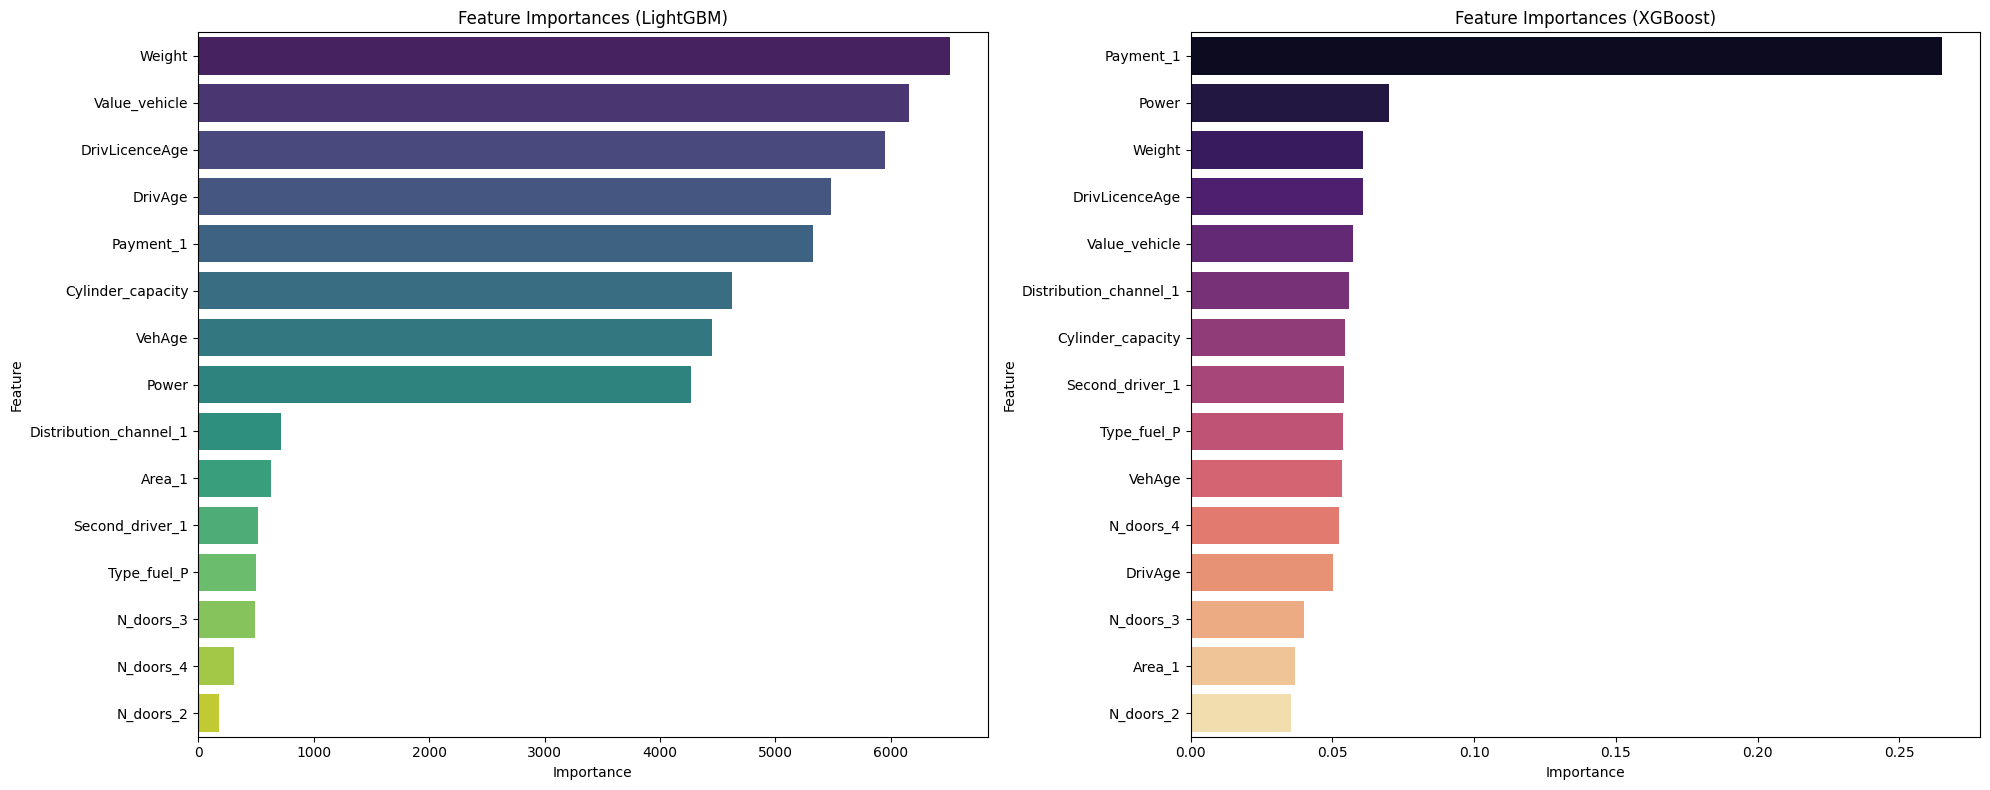

In [ ]:
# Feature Importances aus LightGBM-Modell extrahieren mit importance_type='gain'
lightgbm_importances = lightgbm_model_final.booster_.feature_importance(importance_type='gain')

# Feature Importances aus XGBoost-Modell extrahieren (importance_type='gain' ist Standard)
xgboost_importances = xgboost_model_final.feature_importances_

# DataFrames für die Feature Importances erstellen
feature_names_boosting = X_train_boosting.columns

lightgbm_feature_importance = pd.DataFrame({
    'Feature': feature_names_boosting,
    'Importance': lightgbm_importances
}).sort_values(by='Importance', ascending=False).reset_index(drop=True)

xgboost_feature_importance = pd.DataFrame({
    'Feature': feature_names_boosting,
    'Importance': xgboost_importances
}).sort_values(by='Importance', ascending=False).reset_index(drop=True)

# Plots erstellen
fig, axes = plt.subplots(1, 2, figsize=(20, 8))

# LightGBM Plot
sns.barplot(x='Importance', y='Feature', data=lightgbm_feature_importance.head(15), ax=axes[0], palette='viridis')
axes[0].set_title('Feature Importances (LightGBM)')
axes[0].set_xlabel('Importance')
axes[0].set_ylabel('Feature')
axes[0].tick_params(axis='y', labelsize=10)

# XGBoost Plot
sns.barplot(x='Importance', y='Feature', data=xgboost_feature_importance.head(15), ax=axes[1], palette='magma')
axes[1].set_title('Feature Importances (XGBoost)')
axes[1].set_xlabel('Importance')
axes[1].set_ylabel('Feature')
axes[1].tick_params(axis='y', labelsize=10)

plt.tight_layout()
plt.show()

Bei LightGBM ergibt sich ein Bild, welches wir so in sehr ähnlicher Form bereits bei den Ensemble-Methoden gesehen haben.
Die Zahlweise ist mit Abstand das wichtigste kategoriale Feature, liegt allerdings nicht auf dem ersten Platz, sondern inmitten der demografischen und numerischen Fahrzeugmerkmale.
Die restlichen kategorialen Variablen befinden sich, mit den einzelnen Türanzahlen als Schlusslicht, ganz am Ende.
Das deutet prinzipiell auf eine gewisse Stabilität der Bedeutung einzelner Variablen für die Prognose der Schadenfrequenz hin.
Etwas im Widerspruch dazu steht auf den ersten Blick der Feature-Importance-Plot von XGBoost, bei dem 'Payment_1' mit großem Abstand vorne ist, die anderen Merkmale im Vergleich zu den anderen Modellen jedoch relativ wild durcheinander liegen und sehr ähnliche Wichtigkeit haben.
Eine mögliche Ursache könnte im Level-Wise Growth von XGBoost liegen, welches zu flacheren, symmetrischeren Bäumen und damit potentiell gleichmäßigerem Vorkommen der Features in den Splits führt.
Neben einer weiteren Untersuchung dieses Verhaltens z.B. bei anders gewählten Hyperparametern bietet sich möglicherweise ein zusätzlicher Vergleich der Permutation Importance an.


### c) Boosting-Modelle mit Monotoniebeschränkungen

**Erweitern Sie die in Teilaufgabe b) entwickelten
Gradient-Boosting-Modelle (LightGBM und XGBoost) um Monotoniebeschränkungen. Ziel ist es, fachliche
Plausibilität zu integrieren und die Interpretierbarkeit zu verbessern. Erläutern Sie kurz, warum Monotoniebeschränkungen
in der Versicherungstarifierung relevant sind und diskutieren Sie den Trade-off zwischen
Modellgüte und Plausibilität. Beschreiben Sie kurz, wie LightGBM und XGBoost Monotoniebeschränkungen
während des Trainings umsetzen. Wählen Sie mindestens ein Feature aus, für das eine Monotoniebeschränkung
fachlich plausibel ist, und begründen Sie Ihre Wahl (fachliche Kausalität, empirische Evidenz
aus Teil A). Trainieren Sie LightGBM und XGBoost jeweils mit Monotoniebeschränkungen, übernehmen Sie
die optimalen Hyperparameter aus Teilaufgabe b) und dokumentieren Sie Trainings- bzw. Optimierungszeit.
Integrieren Sie *Exposure* als Gewichtung. Berechnen Sie die Poisson-Devianz auf Trainings- und Validierungsdaten,
fügen Sie die Ergebnisse der Ergebnisdatenstruktur hinzu und vergleichen Sie mit den unbeschränkten
Modellen aus Teilaufgabe b). Bewerten Sie den Performance-Verlust. Erstellen Sie für jedes
Feature mit Monotoniebeschränkung Partial Dependence Plots (PDPs) und vergleichen Sie unbeschränkte
vs. beschränkte Modelle:**

* **Erstellen Sie ein 2 × 2-Grid mit vier PDPs:**
  - **LightGBM ohne Monotonie,**
  - **LightGBM mit Monotonie,**
  - **XGBoost ohne Monotonie,**
  - **XGBoost mit Monotonie.**
* **Nutzen Sie möglichst Bibliotheksfunktionen; falls notwendig, implementieren Sie einen manuellen PDP
(Feature über z. B. 1%–99%-Quantil variieren, andere Features fixieren, mindestens 50 Gridpunkte).**

**Interpretieren Sie die PDPs, identifizieren Sie Monotonieverletzungen in unbeschränkten Modellen und
zeigen Sie, dass beschränkte Modelle (streng) monoton sind. Vergleichen Sie LightGBM und XGBoost
hinsichtlich möglicher Unterschiede.**

In der Versicherungstarifierung sind Monotoniebeschränkungen relevant, um die logische Konsistenz zwischen Risiko und Preis zu gewährleisten.
Viele Risikofaktoren haben einen intuitiven monotonen Zusammenhang mit dem erwarteten Schadenbedarf.
Beispielsweise erscheint es fachlich nicht plausibel, wenn die Prämie einer KFZ-Versicherung beim Erhöhen der Fahrleistung sinkt oder bei besserer Bonus-Malus-Klasse steigt.
Dies könnte zu Problemen mit Aufsichtsbehörden führen, welche die Diskriminierungsfreiheit und ökonomische Begründbarkeit von Tarifen fordern.
Ein gewisses Maß an Erklärbarkeit ist vor allem auch gegenüber Kunden und Vermittlern wichtig, um die Akzeptanz des Tarifs zu gewährleisten und das Vertrauen in den Versicherer nicht zu gefährden.
Außerdem besteht ein Arbitrage-Risiko, wenn Kunden durch gezielte, eigentlich risikoerhöhende Änderungen die Prämie senken können.

Der Trade-off zwischen Modellgüte und Plausibilität ist daher eine der zentralen Herausforderung in der versicherungstechnischen Modellierung.
Modelle ohne Beschränkung besitzen den großen Vorteil, dass sie alle verfügbaren Informationen in den Daten optimal ausnutzen können, auch komplizierte Wechselwirkungen, welche auf den ersten Blick vielleicht unintuitiv erscheinen.
Gleichzeitig besteht - auch wenn bei der Modellerstellung in hohem Maße auf das Vermeiden von Overfitting geachtet wurde - immer die Möglichkeit, dass das Modell statistisches Rauschen in den historischen Daten gelernt hat und bei Anwendung auf neue Daten sogar schlechter generalisiert, als es bei der Vorgabe bestimmter Beschränkungen der Fall ist.
Gerade deshalb ist es ein essenzieller Bestandteil der Arbeit als Aktuar, nicht alleine basierend auf theoretischen Kennzahlen Entscheidungen zu treffen, sondern dabei stets aktiv fachliches Expertenwissen einzubringen.
Plausible Modelle sind in der Regel robuster, sorgen für stetigere Preisverläufe und können etwa durch das Vermeiden von Rückfragen im Vertrieb Kosten sparen.
Zu viele Eingriffe führen andererseits natürlich auch schnell zu deutlichem Underfitting, sodass in der Praxis letztlich die Herausforderung besteht, die wesentlichen Beschränkungen zu identifizieren und nur diese umzusetzen.

Sowohl LightGBM als auch XGBoost setzen Monotoniebeschränkungen während des Trainings auf Ebene der einzelnen Entscheidungsbäume um.
Bei Splits auf beschränkte Features wird immer die korrekte Ordnung der Kinder sichergestellt, so muss im Falle positiver Monotonie der Wert der Zielgröße rechts größer oder gleich dem Wert links sein (bei negativer Monotonie umgekehrt).
Wenn ein Split diese Bedingung verletzt, wird er als ungültig verworfen, selbst wenn er statistisch gesehen die Modellgüte deutlich verbessern würde.
Nachdem solch ein Split durchgeführt wurde, müssen auch die nachfolgenden Splits in den Unterbäumen eingeschränkt werden, damit die gesamte Struktur konsistent bleibt.
Zu diesem Zweck trägt jeder Knoten eine Bandbreite für zulässige Blattwerte, die sich aus den Grenzen der Vorgängerknoten ergeben.
Bei einem Kandidatensplit werden die sich ohne Beschränkung berechneten Blattwerte auf den zulässigen Bereich projiziert und der Split anhand dieser projizierten Werte bewertet, sodass gegen die Ordnung strebende Splits aufgrund des geringen beschränkten Gains früh aussortiert werden.
XGBoost gibt die Bandbreite im Zuge eines Splits an die Kinder weiter, bei LightGBM kann alternativ auch eingestellt werden, dass die Kinderknoten engere, informativere Schranken erhalten.

Mit Fahrleistung und Bonus-Malus-Klassen sind die absoluten Klassiker für Monotoniebeschränkungen in der KFZ-Versicherung nicht in unserem Datensatz enthalten.
Von unseren Merkmalen würde in der Praxis wohl am ehesten noch einen Zuschlag im Falle eines zusätzlichen Fahrers erwartet werden, allerdings ist 'Second_driver_1' aufgrund der binären Natur für die weiteren Betrachtungen nicht gut geeignet.
Wir entscheiden uns daher stattdessen für das Merkmal 'Power' als geeigneten Kandidaten.
Fachlich scheint es durchaus plausibel, dass sich bei Autos mit mehr Leistung aufgrund von höheren Geschwindigkeiten auch das Risiko für einen Unfall erhöht, und wir haben in Teil A einen positiven Zusammenhang zur Variable 'Premium' gesehen, bei deren Gestaltung durchaus eine erhöhte Schadenfrequenz berücksichtigt worden sein könnte.
Gleichzeitig weisen wir darauf hin, dass Effekte wie bessere Fahrassistenzsysteme bei leistungsstärkeren Autos auch gegen diese Intuition wirken können und es in der Praxis häufig keine Notwendigkeit geben dürfte, für dieses Fahrzeugmerkmal tatsächlich eine strenge Monotonie zu fordern.
Außerdem fließt in die Prämiengestaltung zusätzlich auch noch die Schadenhöhe ein, bei welcher die Leistung ebenfalls ein treibender Faktor sein und damit mögliche Monotoniebrüche in der Frequenz ausgleichen kann.
Wir trainieren LightGBM und XGBoost nun dennoch mit einer positiven Monotoniebeschränkung für 'Power' und verwenden dabei die optimalen Hyperparameter aus der letzten Teilaufgabe.

In [ ]:
# Erstelle die Liste für Monotoniebeschränkung (0 für keine, 1 für positive Monotoniebeschränkung)
monotonic_feature_name = 'Power'
monotonic_feature_index = X_train_boosting.columns.get_loc(monotonic_feature_name)

monotone_constraints_list = [0] * X_train_boosting.shape[1]
monotone_constraints_list[monotonic_feature_index] = 1

# LightGBM mit Monotoniebeschränkung

# Kopiere die besten LightGBM-Parameter und füge die Monotoniebeschränkung hinzu
best_lightgbm_params_mono = best_lightgbm_params.copy()
best_lightgbm_params_mono['monotone_constraints'] = monotone_constraints_list

# Startzeit messen
start_time_lightgbm_mono = time.time()

# Trainiere das finale LightGBM-Modell mit den optimalen Hyperparametern und Monotoniebeschränkung
lightgbm_model_mono = lgb.LGBMRegressor(objective='poisson',
                                       random_state=seed,
                                       n_jobs=-1, # alle verfügbaren Kerne für schnellere Berechnung nutzen
                                       verbose=-1, # ausführliche Ausgabe unterdrücken
                                       **best_lightgbm_params_mono)

lightgbm_model_mono.fit(X_train_boosting, y_freq_train.values.ravel(),
                         sample_weight=expo_train.values.ravel())

# Endzeit messen und Modellierungszeit berechnen
end_time_lightgbm_mono = time.time()
modeling_time_lightgbm_mono = end_time_lightgbm_mono - start_time_lightgbm_mono

print("Finales LightGBM-Modell mit Monotoniebeschränkung:")
print("\nHyperparameter:")
for param, value in best_lightgbm_params_mono.items():
    print(f"{param}: {value}")
print(f"\nBenötigte Zeit für die Modellierung: {modeling_time_lightgbm_mono:.2f} Sekunden\n")

# Frequenz-Vorhersagen generieren
pred_freq_train_lightgbm_mono = lightgbm_model_mono.predict(X_train_boosting)
pred_freq_val_lightgbm_mono = lightgbm_model_mono.predict(X_val_boosting)
pred_freq_test_lightgbm_mono = lightgbm_model_mono.predict(X_test_boosting)

# Sicherstellen, dass Frequenzen nicht negativ sind
pred_freq_train_lightgbm_mono = np.maximum(pred_freq_train_lightgbm_mono, 0)
pred_freq_val_lightgbm_mono = np.maximum(pred_freq_val_lightgbm_mono, 0)
pred_freq_test_lightgbm_mono = np.maximum(pred_freq_test_lightgbm_mono, 0)

# durch Multiplikation mit dem Exposure auf Schadenanzahlen übergehen
pred_claims_train_lightgbm_mono = pred_freq_train_lightgbm_mono * expo_train.values.ravel()
pred_claims_val_lightgbm_mono = pred_freq_val_lightgbm_mono * expo_val.values.ravel()
pred_claims_test_lightgbm_mono = pred_freq_test_lightgbm_mono * expo_test.values.ravel()

# Poisson-Devianz auf den Trainings- und Validierungsdaten ausgeben
evaluate_poisson_deviance_train_val(
    pred_claims_train_lightgbm_mono, y_train, expo_train,
    pred_claims_val_lightgbm_mono, y_val, expo_val
)


# XGBoost mit Monotoniebeschränkung

# Kopiere die besten XGBoost-Parameter und füge die Monotoniebeschränkung hinzu
best_xgboost_params_mono = best_xgboost_params.copy()
best_xgboost_params_mono['monotone_constraints'] = str(tuple(monotone_constraints_list))

# Startzeit messen
start_time_xgboost_mono = time.time()

# Trainiere das finale XGBoost-Modell mit den optimalen Hyperparametern und Monotoniebeschränkung
xgboost_model_mono = xgb.XGBRegressor(objective='count:poisson',
                                       random_state=seed,
                                       n_jobs=-1, # alle verfügbaren Kerne für schnellere Berechnung nutzen
                                       **best_xgboost_params_mono)

xgboost_model_mono.fit(X_train_boosting, y_freq_train.values.ravel(),
                        sample_weight=expo_train.values.ravel()
                       )

# Endzeit messen und Modellierungszeit berechnen
end_time_xgboost_mono = time.time()
modeling_time_xgboost_mono = end_time_xgboost_mono - start_time_xgboost_mono

print("________________________________________________________")
print("\nFinales XGBoost-Modell mit Monotoniebeschränkung:")
print("\nHyperparameter:")
for param, value in best_xgboost_params_mono.items():
    print(f"{param}: {value}")
print(f"\nBenötigte Zeit für die Modellierung: {modeling_time_xgboost_mono:.2f} Sekunden\n")

# Frequenz-Vorhersagen generieren
pred_freq_train_xgboost_mono = xgboost_model_mono.predict(X_train_boosting)
pred_freq_val_xgboost_mono = xgboost_model_mono.predict(X_val_boosting)
pred_freq_test_xgboost_mono = xgboost_model_mono.predict(X_test_boosting)

# Sicherstellen, dass Frequenzen nicht negativ sind
pred_freq_train_xgboost_mono = np.maximum(pred_freq_train_xgboost_mono, 0)
pred_freq_val_xgboost_mono = np.maximum(pred_freq_val_xgboost_mono, 0)
pred_freq_test_xgboost_mono = np.maximum(pred_freq_test_xgboost_mono, 0)

# durch Multiplikation mit dem Exposure auf Schadenanzahlen übergehen
pred_claims_train_xgboost_mono = pred_freq_train_xgboost_mono * expo_train.values.ravel()
pred_claims_val_xgboost_mono = pred_freq_val_xgboost_mono * expo_val.values.ravel()
pred_claims_test_xgboost_mono = pred_freq_test_xgboost_mono * expo_test.values.ravel()

# Poisson-Devianz auf den Trainings- und Validierungsdaten ausgeben
evaluate_poisson_deviance_train_val(
    pred_claims_train_xgboost_mono, y_train, expo_train,
    pred_claims_val_xgboost_mono, y_val, expo_val
)

Finales LightGBM-Modell mit Monotoniebeschränkung:

Hyperparameter:
learning_rate: 0.03
n_estimators: 400
num_leaves: 15
max_depth: 7
min_child_samples: 10
colsample_bytree: 0.7
subsample: 0.8
subsample_freq: 5
reg_alpha: 0.1
reg_lambda: 0
monotone_constraints: [1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]

Benötigte Zeit für die Modellierung: 0.63 Sekunden

Poisson-Devianz auf den Trainingsdaten: 3.1641
Poisson-Devianz auf den Validierungsdaten: 3.5926
________________________________________________________

Finales XGBoost-Modell mit Monotoniebeschränkung:

Hyperparameter:
learning_rate: 0.1
n_estimators: 100
max_depth: 3
min_child_weight: 10
subsample: 0.7
colsample_bytree: 1.0
reg_alpha: 0
reg_lambda: 0.1
monotone_constraints: (1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0)

Benötigte Zeit für die Modellierung: 0.16 Sekunden

Poisson-Devianz auf den Trainingsdaten: 3.4101
Poisson-Devianz auf den Validierungsdaten: 3.6021


Wir speichern beide Modelle in der Ergebnisdatenstruktur und vergleichen sie mit den unbeschränkten Varianten.

In [ ]:
# Ergebnisse des LightGBM-Modells mit Monotoniebeschränkung in die Ergebnisdatenstruktur speichern
evaluate_and_store_model_result(
    'LightGBM mono',
    pred_claims_train_lightgbm_mono, y_train, expo_train,
    pred_claims_val_lightgbm_mono, y_val, expo_val,
    pred_claims_test_lightgbm_mono, y_test, expo_test,
    time_lightgbm_grid, modeling_time_lightgbm_mono
)

# Ergebnisse des XGBoost-Modells mit Monotoniebeschränkung in die Ergebnisdatenstruktur speichern
evaluate_and_store_model_result(
    'XGBoost mono',
    pred_claims_train_xgboost_mono, y_train, expo_train,
    pred_claims_val_xgboost_mono, y_val, expo_val,
    pred_claims_test_xgboost_mono, y_test, expo_test,
    time_xgboost_grid, modeling_time_xgboost_mono
)

# aktualisierte Ergebnisdatenstruktur anzeigen
print("\nAktualisierte Ergebnisdatenstruktur:")
display_model_results()


Aktualisierte Ergebnisdatenstruktur:


Model,Train_Metric,Validation_Metric,Test_Metric,Optimization_Time,Modeling_Time
Intercept-Only,3.6515,3.7541,3.7054,0.00,0.04
GLM,3.5349,3.6313,3.6141,0.00,0.07
Elastic Net,3.5350,3.6312,3.6136,301.84,11.71
Neural Net,3.4479,3.6270,3.6136,0.00,11.62
Bagging,3.2578,3.6243,3.6072,0.00,17.33
Random Forest,3.3355,3.6144,3.6024,0.00,4.10
LightGBM,3.1528,3.5858,3.6158,139.62,2.11
XGBoost,3.4086,3.5951,3.6148,164.54,1.13
LightGBM mono,3.1641,3.5926,3.6198,139.62,0.63
XGBoost mono,3.4101,3.6021,3.6131,164.54,0.16


Die beschränkten Modelle weisen im Training wie zu erwarten eine etwas schlechtere Poisson-Devianz auf.
Auch auf den Validierungsdaten ist nur ein leichter Performance-Verlust zu erkennen, sodass die Monotonievorgabe bei entsprechender Sinnhaftigkeit durchaus in Kauf genommen werden könnte.
Da jeweils die für das unbeschränkte Modell optimierten Hyperparameter verwendet wurden, wäre es zudem interessant, welche Resultate sich bei erneutem Tuning mit Monotoniebeschränkung ergeben.

Für den weiteren Vergleich erstellen wir Partial Dependence Plots (PDPs), welche den durchschnittlichen Einfluss von 'Power' auf die prognostizierten Schadenfrequenzen (gemittelt über die Verteilung aller anderen Features im Trainingsdatensatz) messen.

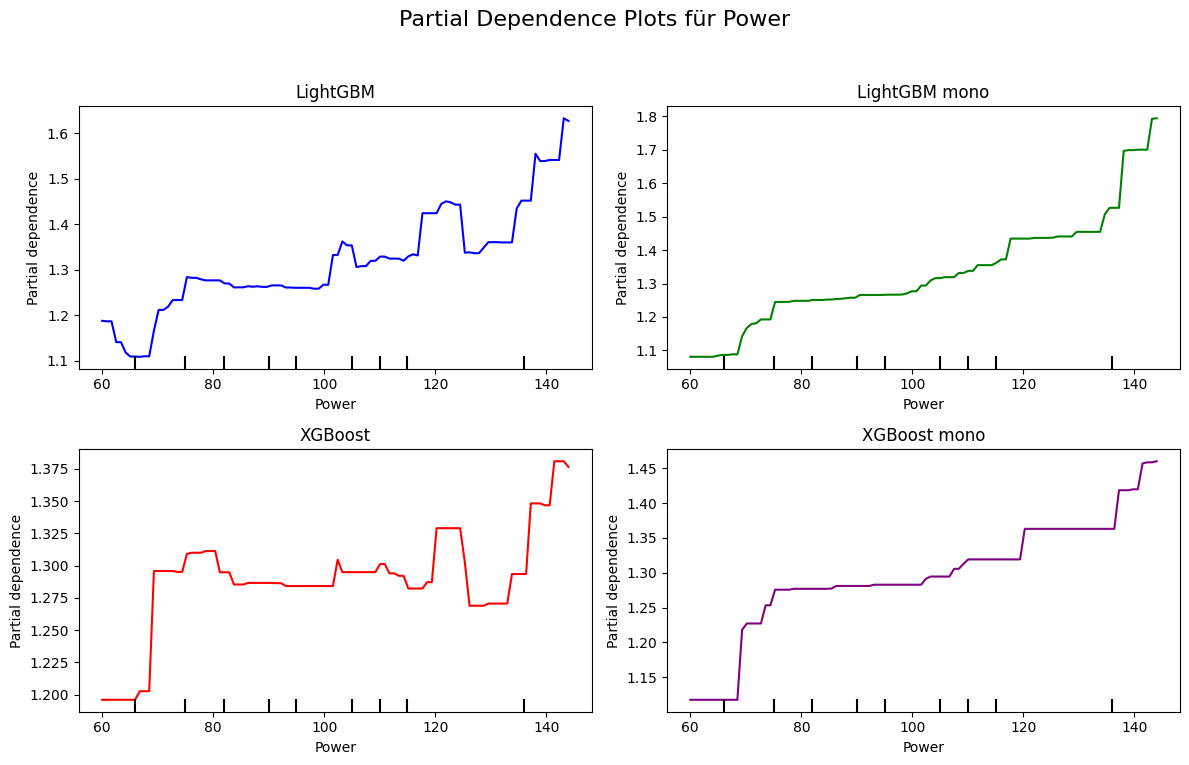

In [ ]:
# PDPs plotten in einem 2x2 Grid
pdp_feature_name = 'Power'
fig, axes = plt.subplots(2, 2, figsize=(12, 8), sharey=True)
fig.suptitle(f'Partial Dependence Plots für {pdp_feature_name}', fontsize=16)

# LightGBM (unbeschränkt)
display_lgbm = sklearn.inspection.PartialDependenceDisplay.from_estimator(
    lightgbm_model_final,
    X_train_boosting,
    features=[pdp_feature_name],
    feature_names=X_train_boosting.columns.tolist(),
    kind='average',
    ax=axes[0, 0],
    line_kw={'color': 'blue'}
)
axes[0, 0].set_title('LightGBM')

# LightGBM mit Monotonie
display_lgbm_mono = sklearn.inspection.PartialDependenceDisplay.from_estimator(
    lightgbm_model_mono,
    X_train_boosting,
    features=[pdp_feature_name],
    feature_names=X_train_boosting.columns.tolist(),
    kind='average',
    ax=axes[0, 1],
    line_kw={'color': 'green'}
)
axes[0, 1].set_title('LightGBM mono')

# XGBoost (unbeschränkt)
display_xgb = sklearn.inspection.PartialDependenceDisplay.from_estimator(
    xgboost_model_final,
    X_train_boosting,
    features=[pdp_feature_name],
    feature_names=X_train_boosting.columns.tolist(),
    kind='average',
    ax=axes[1, 0],
    line_kw={'color': 'red'}
)
axes[1, 0].set_title('XGBoost')
axes[1, 0].set_xlabel(pdp_feature_name)

# XGBoost mit Monotonie
display_xgb_mono = sklearn.inspection.PartialDependenceDisplay.from_estimator(
    xgboost_model_mono,
    X_train_boosting,
    features=[pdp_feature_name],
    feature_names=X_train_boosting.columns.tolist(),
    kind='average',
    ax=axes[1, 1],
    line_kw={'color': 'purple'}
)
axes[1, 1].set_title('XGBoost mono')
axes[1, 1].set_xlabel(pdp_feature_name)

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

Bei beiden unbeschränkten Boosting-Modellen zeigt sich prinzipiell ein recht ähnlicher Verlauf mit leichten lokalen Unterschieden, wobei die Vorhersage bezüglich 'Power' bei LightGBM insgesamt deutlich stärker spreizt.
Die Leistung hat tatsächlich tendenziell einen positiven Einfluss auf die Schadenhäufigkeit, allerdings ist dieser bei Weitem nicht strikt monoton, und wir erkennen neben relativ stabilen Plateus auch zwischenzeitliche Ausschläge.
Im Vergleich dazu sehen wir rechts jeweils die glättende Wirkung der Monotoniebeschränkung, welche zu einem monotonen und stabilerem Verlauf führt.
Gerade an den dünn besetzten und ursprünglich etwas unruhigen Rändern kann dieser Effekt sehr sinnvoll sein, während sich bei den restlichen weggeglätteten Ausschlägen die Frage stellt, ob die durchgesetzte Monotonie das Modell wirklich plausibler macht oder hierdurch berechtigterweise erkannte komplexe Muster in den Daten verworfen werden.
Prinzipiell ähneln sich die Verläufe von LightGBM und XGBoost durch die Regularisierung der Beschränkung noch etwas mehr als vorher, wobei sich in beiden Fällen die Spreizung weiter erhöht hat.

Zum Abschluss identifizieren wir noch konkret die Monotieverletzungen in den einzelnen PDPs.
Wir zeigen dabei empirisch, dass die beschränkten Modelle in dieser Hinsicht tatsächlich monoton steigend in 'Power' sind (auch wenn das strenggenommen natürlich keinen echten Nachweis für die Monotonie der Modelle darstellt, weil wir nur diskrete und auf Durchschnittsbildung der Prognosen in den Trainingsdaten beruhende Punkte überprüft haben).

In [ ]:
# Hilfsfunktion zur Identifizierung von Verletzungen positiver Monotonie
def identify_non_monotonic_points(x_values, y_values, model_name):
    non_monotonic_points = []
    print(f"Monotonieverletzungen bei {model_name}:\n")
    found = False
    for i in range(len(y_values) - 1):
        if y_values[i+1] < y_values[i]:
            print(f"  x-Wert: {x_values[i]:.2f}, aktueller y-Wert: {y_values[i]:.4f}, nächster y-Wert: {y_values[i+1]:.4f}")
            found = True
    if not found:
        print(" keine")

# Extrahieren der Koordinaten der PDPs
pdp_lgbm_x = np.asarray(display_lgbm.pd_results[0].grid_values).flatten()
pdp_lgbm_y = np.asarray(display_lgbm.pd_results[0].average).flatten()

pdp_lgbm_mono_x = np.asarray(display_lgbm_mono.pd_results[0].grid_values).flatten()
pdp_lgbm_mono_y = np.asarray(display_lgbm_mono.pd_results[0].average).flatten()

pdp_xgb_x = np.asarray(display_xgb.pd_results[0].grid_values).flatten()
pdp_xgb_y = np.asarray(display_xgb.pd_results[0].average).flatten()

pdp_xgb_mono_x = np.asarray(display_xgb_mono.pd_results[0].grid_values).flatten()
pdp_xgb_mono_y = np.asarray(display_xgb_mono.pd_results[0].average).flatten()

# Anwenden der Hilfsfunktion für jedes Modell
identify_non_monotonic_points(pdp_lgbm_x, pdp_lgbm_y, 'LightGBM')
print("____________________________________________________________________\n")
identify_non_monotonic_points(pdp_lgbm_mono_x, pdp_lgbm_mono_y, 'LightGBM mono')
print("____________________________________________________________________\n")
identify_non_monotonic_points(pdp_xgb_x, pdp_xgb_y, 'XGBoost')
print("____________________________________________________________________\n")
identify_non_monotonic_points(pdp_xgb_mono_x, pdp_xgb_mono_y, 'XGBoost mono')

Monotonieverletzungen bei LightGBM:

  x-Wert: 60.00, aktueller y-Wert: 1.1877, nächster y-Wert: 1.1867
  x-Wert: 61.70, aktueller y-Wert: 1.1867, nächster y-Wert: 1.1410
  x-Wert: 63.39, aktueller y-Wert: 1.1410, nächster y-Wert: 1.1181
  x-Wert: 64.24, aktueller y-Wert: 1.1181, nächster y-Wert: 1.1093
  x-Wert: 65.94, aktueller y-Wert: 1.1093, nächster y-Wert: 1.1088
  x-Wert: 75.27, aktueller y-Wert: 1.2838, nächster y-Wert: 1.2821
  x-Wert: 76.97, aktueller y-Wert: 1.2821, nächster y-Wert: 1.2788
  x-Wert: 77.82, aktueller y-Wert: 1.2788, nächster y-Wert: 1.2766
  x-Wert: 81.21, aktueller y-Wert: 1.2766, nächster y-Wert: 1.2699
  x-Wert: 82.06, aktueller y-Wert: 1.2699, nächster y-Wert: 1.2695
  x-Wert: 82.91, aktueller y-Wert: 1.2695, nächster y-Wert: 1.2611
  x-Wert: 86.30, aktueller y-Wert: 1.2638, nächster y-Wert: 1.2625
  x-Wert: 88.00, aktueller y-Wert: 1.2636, nächster y-Wert: 1.2623
  x-Wert: 92.24, aktueller y-Wert: 1.2655, nächster y-Wert: 1.2609
  x-Wert: 93.94, aktuelle

### d) Auswertung und Interpretation der Modelle am Testset

**Evaluieren und vergleichen Sie alle trainierten
Modelle auf dem Testdatensatz (Intercept-Only, GLM, LASSO, neuronales Netzwerk, Bagging, Random
Forest, LightGBM, XGBoost sowie Varianten mit Monotoniebeschränkungen). Die Auswertung umfasst Modellgüte
(Poisson-Devianz) und Kalibrierung. Berechnen Sie für jedes Modell die Poisson-Devianz auf dem
Testdatensatz, ergänzen Sie die Ergebnisdatenstruktur und erstellen Sie eine vergleichende Grafik der
Poisson-Devianz auf Training, Validierung und Test. Interpretieren Sie die Ergebnisse.**

**Identifizieren Sie das beste Modell nach Test-Performance, quantifizieren Sie die Verbesserung gegenüber
dem Baseline-Modell und diskutieren Sie mögliche Anzeichen von Overfitting. Prüfen Sie die globale Kalibrierung,
indem Sie für jedes Modell vergleichen, ob die Summe der vorhergesagten Schäden der Summe
der beobachteten Schäden entspricht. Berechnen Sie dazu das Verhältnis Actual/Expected. Prüfen Sie
die Kalibrierung nach Risikogruppen: Teilen Sie das Testset in Dezile basierend auf den vorhergesagten
Schadenfrequenzen ein und vergleichen Sie je Dezil beobachtete vs. erwartete Schadenfrequenz. Erstellen
Sie für alle Modelle geeignete Visualisierungen (mindestens Actual-vs.-Expected nach Dezilen und ein
gemeinsames Lift-Chart) und geben Sie eine abschließende Bewertung der Modellkalibrierung und Risikodifferenzierung
ab.**

Wir vergleichen nun alle trainierten Modelle und betrachten neben der Performance auf Trainings- und Validierungsdaten erstmals auch die Testdaten.
Wie immer sind dabei alle Ergebnisse auch im Kontext der relativ geringen Datenmenge zu sehen.

Ergebnisdatenstruktur:


Model,Train_Metric,Validation_Metric,Test_Metric,Optimization_Time,Modeling_Time
Intercept-Only,3.6515,3.7541,3.7054,0.00,0.04
GLM,3.5349,3.6313,3.6141,0.00,0.07
Elastic Net,3.5350,3.6312,3.6136,301.84,11.71
Neural Net,3.4479,3.6270,3.6136,0.00,11.62
Bagging,3.2578,3.6243,3.6072,0.00,17.33
Random Forest,3.3355,3.6144,3.6024,0.00,4.10
LightGBM,3.1528,3.5858,3.6158,139.62,2.11
XGBoost,3.4086,3.5951,3.6148,164.54,1.13
LightGBM mono,3.1641,3.5926,3.6198,139.62,0.63
XGBoost mono,3.4101,3.6021,3.6131,164.54,0.16


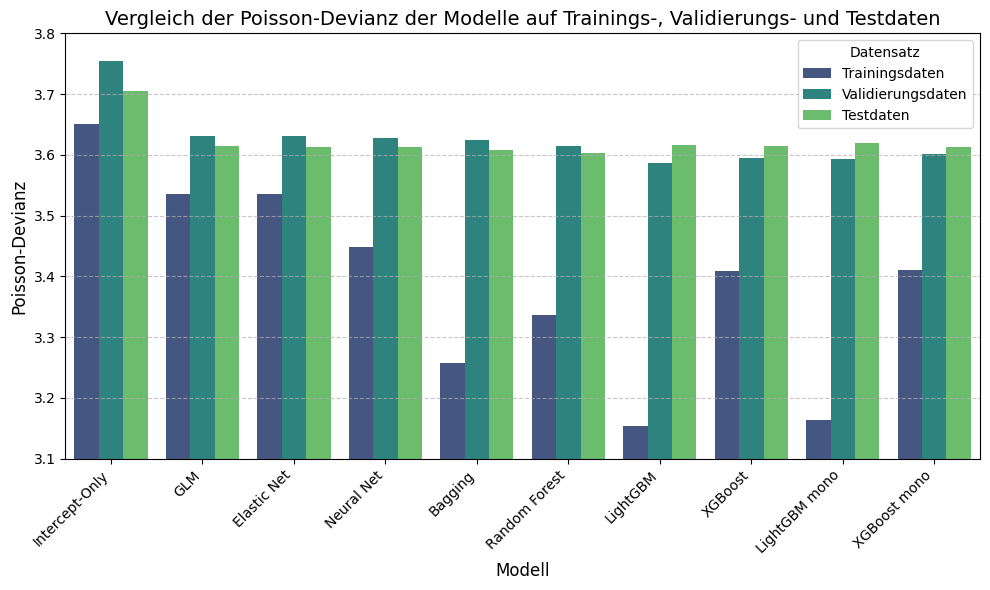

In [ ]:
# Ergebnisdatenstruktur anzeigen
print("Ergebnisdatenstruktur:")
display_model_results()
print()

# Erstellen einer Kopie der Ergebnisdatenstruktur für die Visualisierung
plot_data = model_results.copy()

# Umbenennen der Spalten für bessere Lesbarkeit in der Grafik
plot_data = plot_data.rename(columns={
    'Train_Metric': 'Trainingsdaten',
    'Validation_Metric': 'Validierungsdaten',
    'Test_Metric': 'Testdaten'
})

# Daten in ein langes Format umwandeln für Seaborn Barplot
plot_data_melted = plot_data.melt(id_vars=['Model'],
                                  value_vars=['Trainingsdaten', 'Validierungsdaten', 'Testdaten'],
                                  var_name='Datensatz',
                                  value_name='Poisson-Devianz')

# Grafik erstellen
plt.figure(figsize=(10, 6))
sns.barplot(x='Model', y='Poisson-Devianz', hue='Datensatz', data=plot_data_melted, palette='viridis')
plt.title('Vergleich der Poisson-Devianz der Modelle auf Trainings-, Validierungs- und Testdaten', fontsize=14)
plt.xlabel('Modell', fontsize=12)
plt.ylabel('Poisson-Devianz', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.ylim(3.1, 3.8)
plt.tight_layout()
plt.show()

Das Intercept-Only-Modell besitzt auf allen Splits die höchste Poisson-Devianz und dient als Baseline, gegenüber der sich alle anderen Modelle klar verbessern.
Aufgrund des sehr kleinen Regularisierungsparameters, welcher im Zuge eines Hyperparametertunings bestimmt wurde, unterscheiden sich das GLM und das elastische Netz kaum. Sie zeigen überall praktisch die identische Performance und die moderaten Unterschiede zwischen Training und Validierung bzw. Test weisen auf eine saubere Generalisierung hin.
Im Vergleich dazu senken die angewendeten Machine Learning Techniken die Devianz auf den Trainingsdaten teilweise massiv, während die Verbesserung auf den Validierungsdaten deutlich kleiner ausfällt, was Anzeichen einer gewissen Überanpassung sind.
Am schwächsten zeigt sich dieser Effekt noch beim künstlichen neuronalen Netz (welches auf den Testdaten letztlich gleich gut wie das elastisches Netz abschneidet), gefolgt von den XGBoost-Modellen bzw. Random Forest und schließlich am stärksten bei den auf den Trainingsdaten besten Bagging- bzw. LightGBM-Modellen.
Die Boosting-Verfahren haben auf den Validierungsdaten die niedrigste Devianz, was vor dem Hintergrund unserer Hyperparameteroptimierung nicht überraschend ist.
Mit Blick auf die ungesehenen Testdaten, wo die Performance größtenteils sogar etwas schlechter als die von GLM bzw. elastischem Netz ist, erkennen wir tatsächlich Anzeichen von Tuning-Overfitting.
Die Modelle mit Monotonievorgabe sind dabei insgesamt sehr ähnlich zu den unbeschränkten Varianten, im Falle von XGBoost ist die Devianz auf den Testdaten sogar minimal kleiner.
Die besten Ergebnisse auf den Testdaten werden letztlich von den Ensemble-Methoden erzielt, wobei Random Forest das Bagging-Modell hier knapp (und außerdem auch auf den in beiden Fällen nicht für Tuning benutzten Validierungsdaten) schlägt.

Der Random Forest verbessert die Modellgüte im Sinne der Poisson-Devianz gegenüber dem Baseline-Modell auf dem Testdatensatz um rund $\frac{3,7054-3,6024}{3,7054}\approx2,8\%$.
Wie bereits diskutiert ist die deutlich bessere Trainingsdevianz ein typischer Hinweis auf tendenzielles Overfitting, welches im Hinblick auf die stabile Generalisierung auf neuen Daten (ähnliche Performance bei Validierung und Test) aber unter Kontrolle ist.

Als Nächstes prüfen wir die globale Kalibrierung der Modelle auf den Testdaten.

In [ ]:
# Dictionary mit den vorhergesagten Schadenanzahlen je Modell
model_predictions = {
    'Intercept-Only': pred_test,
    'GLM': pred_test_glm,
    'Elastic Net': pred_test_elastic_net,
    'Neural Net': pred_test_neural_net,
    'Bagging': pred_claims_test_bagging,
    'Random Forest': pred_claims_test_random_forest,
    'LightGBM': pred_claims_test_lightgbm,
    'XGBoost': pred_claims_test_xgboost,
    'LightGBM mono': pred_claims_test_lightgbm_mono,
    'XGBoost mono': pred_claims_test_xgboost_mono
}

# Berechnung der globalen Actual/Expected
ae_results = pd.DataFrame(columns=['Model', 'Actual/Expected'])
sum_actuals_test = y_test['N_claims_year'].sum()

for model_name, predictions in model_predictions.items():
    ae_model = sum_actuals_test / sum(predictions)
    new_row = pd.DataFrame([{'Model': model_name, 'Actual/Expected': ae_model}])
    ae_results = pd.concat([ae_results, new_row], ignore_index=True)

print("Globale Kalibrierung der Modelle auf den Testdaten:")
display(ae_results.style.format({'Actual/Expected': '{:.4f}'}).hide(axis='index'))

Globale Kalibrierung der Modelle auf den Testdaten:


Model,Actual/Expected
Intercept-Only,1.0029
GLM,1.0075
Elastic Net,1.0075
Neural Net,1.0164
Bagging,0.9914
Random Forest,0.9967
LightGBM,0.9998
XGBoost,1.0016
LightGBM mono,1.0002
XGBoost mono,1.0006


Das Verhältnis der insgesamt beobachteten zu den jeweils vorhergesagten Schäden ist für alle Modelle sehr nahe bei 1 und es liegt eine gute globale Kalibrierung vor.
Im nächsten Schritt teilen wir die Testdaten pro Modell in Dezile bezüglich der prognostizierten Schadenfrequenz ein und untersuchen durch Actual/Expected-Plots sowie ein gemeinsames Lift-Chart die Kalibrierung nach Risikogruppen.

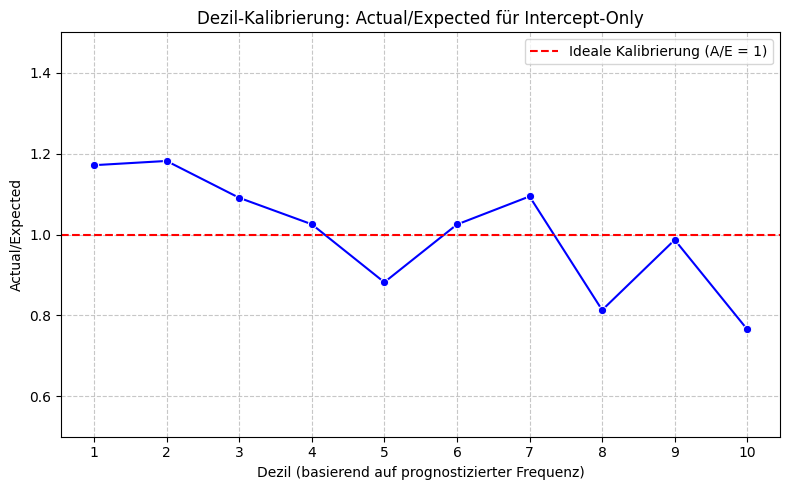

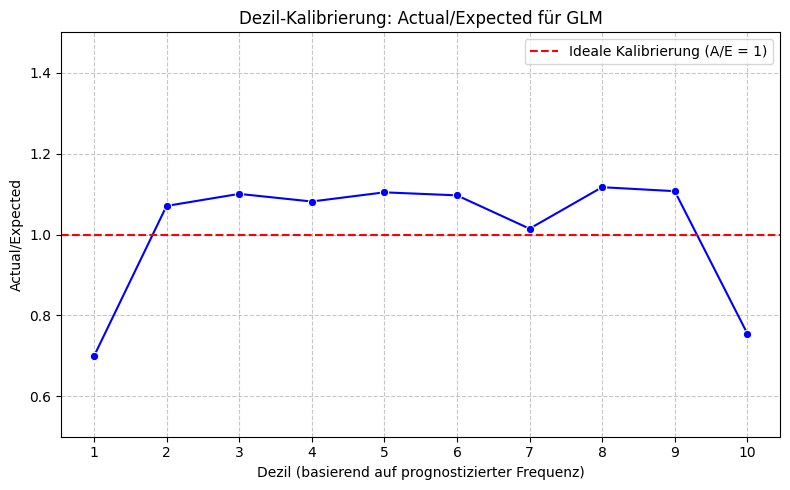

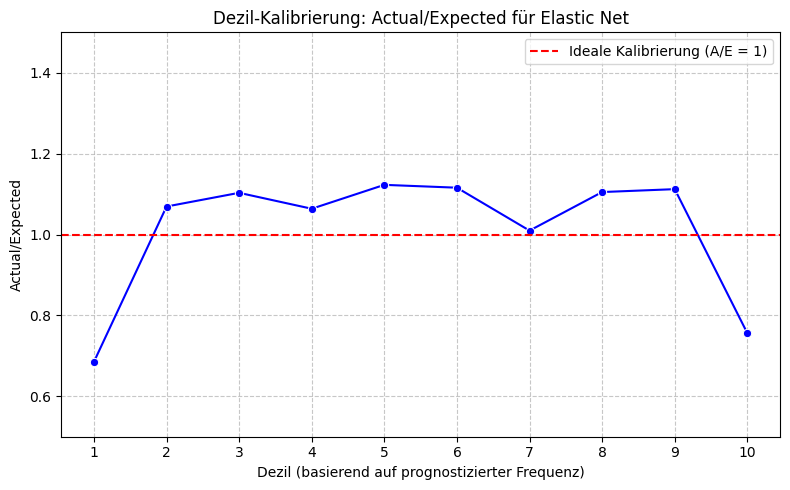

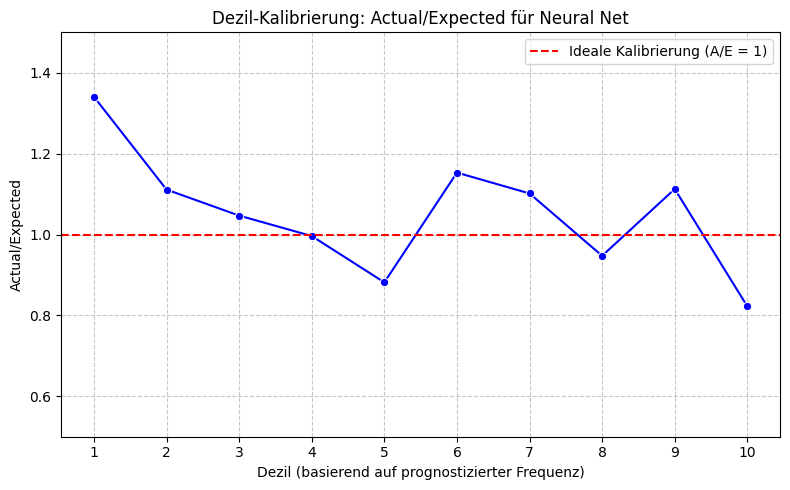

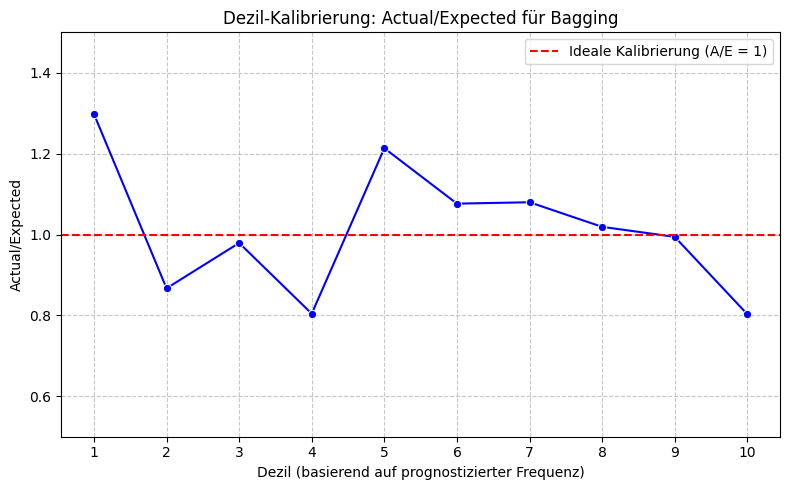

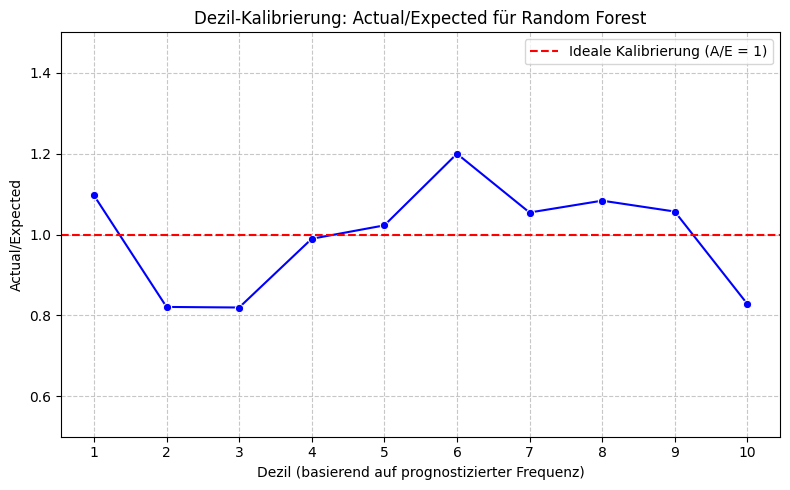

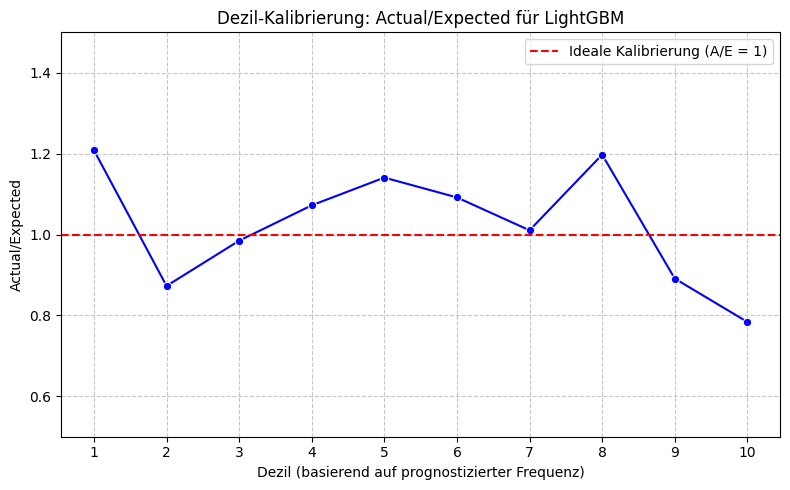

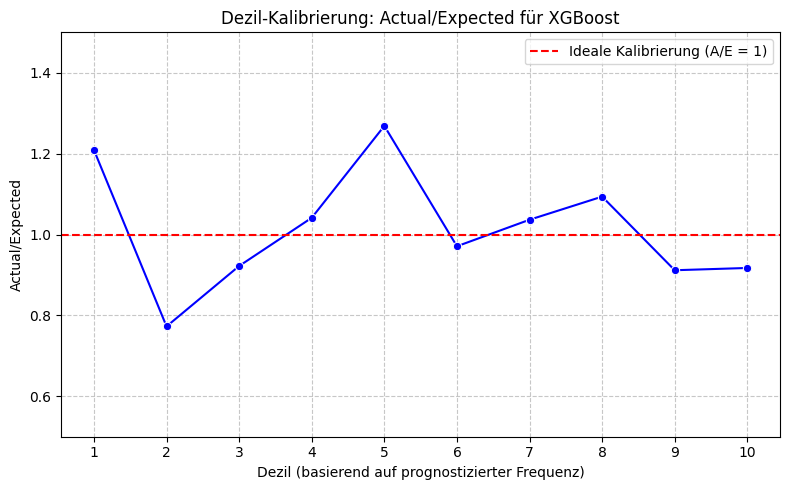

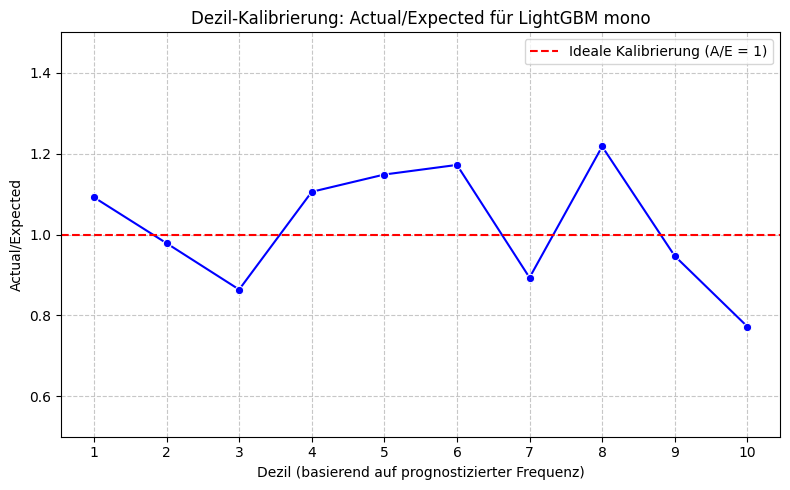

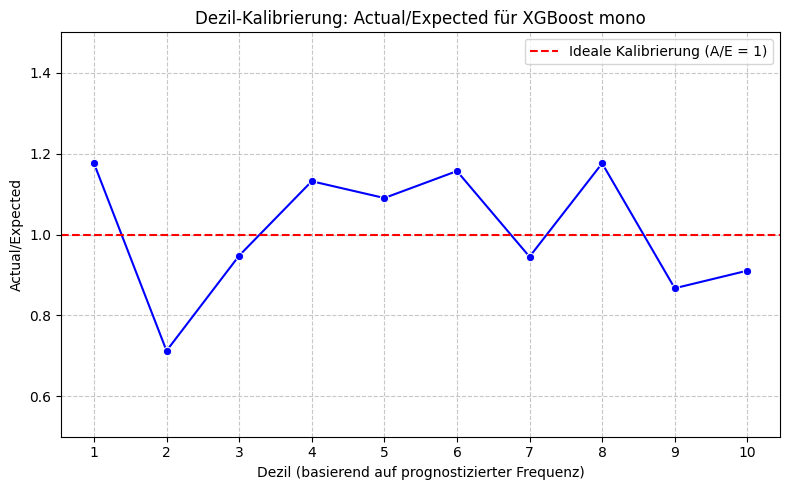

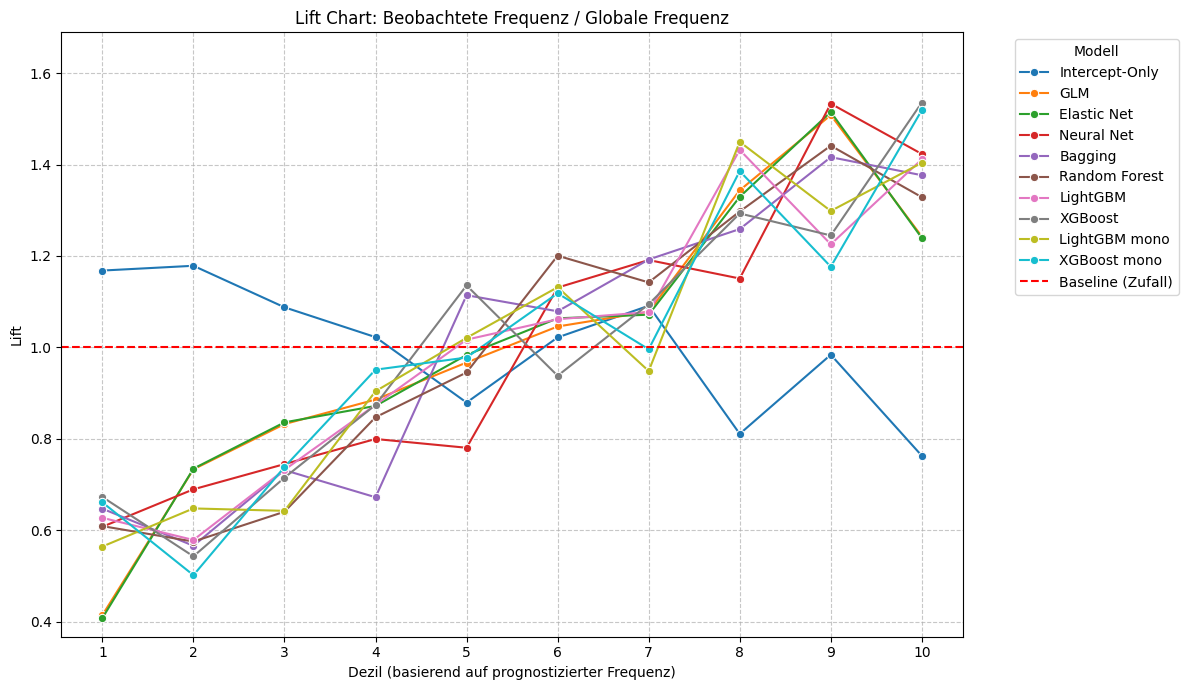

In [ ]:
# Liste zur Speicherung der Dezil-Kalibrierungsergebnisse aller Modelle
all_decile_results = []

# Schleife über die Modelle, um Dezile einzuteilen und Kennzahlen zu berechnen
for model_name, predictions in model_predictions.items():

    # Kombiniere Daten für die Dezilanalyse
    temp_df = pd.DataFrame({
        'N_claims_year': y_test['N_claims_year'],
        'Pred_claims': predictions,
        'Exposure': expo_test['Exposure']
    })

    if model_name == 'Intercept-Only':
        # Für Intercept-Only zufällige Dezile erstellen
        np.random.seed(seed)
        temp_df['random_sort_key'] = np.random.rand(len(temp_df))
        temp_df['decile'] = pd.qcut(temp_df['random_sort_key'], 10, labels=False, duplicates='drop') + 1
    else:
        # Für andere Modelle vorhergesagte Frequenzen berechnen und Dezile hierauf basierend erstellen
        temp_df['Pred_freq'] = temp_df['Pred_claims'] / temp_df['Exposure']
        temp_df['decile'] = pd.qcut(temp_df['Pred_freq'], 10, labels=False, duplicates='drop') + 1

    # Berechne Summen für jedes Dezil
    decile_summary = temp_df.groupby('decile').agg(
        sum_actual_claims=('N_claims_year', 'sum'),
        sum_predicted_claims=('Pred_claims', 'sum'),
        sum_exposure=('Exposure', 'sum'),
    ).reset_index()

    # Berechne Actual/Expected für jedes Dezil (wegen selbem Exposure identisch zum Quotient der Frequenzen)
    decile_summary['Actual/Expected'] = decile_summary['sum_actual_claims'] / decile_summary['sum_predicted_claims']
    decile_summary['Model'] = model_name

    all_decile_results.append(decile_summary)

    # Plot der Dezil-Kalibrierung (Actual/Expected)
    plt.figure(figsize=(8, 5))
    sns.lineplot(data=decile_summary, x='decile', y='Actual/Expected', marker='o', color='blue')
    plt.axhline(1, color='red', linestyle='--', label='Ideale Kalibrierung (A/E = 1)')
    plt.title(f'Dezil-Kalibrierung: Actual/Expected für {model_name}')
    plt.xlabel('Dezil (basierend auf prognostizierter Frequenz)')
    plt.ylabel('Actual/Expected')
    plt.xticks(range(1, 11))
    plt.ylim(0.5, 1.5)
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.legend()
    plt.tight_layout()
    plt.show()

# Verkette die Dezil-Ergebnisse pro Modell in einem einzigen DataFrame
final_decile_results_df = pd.concat(all_decile_results, ignore_index=True)

# globale Schadenfrequenz ausrechnen
global_claim_frequency = y_test['N_claims_year'].sum() / expo_test['Exposure'].sum()

# pro Dezil beobachtete Schadenfrequenz und Lift ausrechnen
final_decile_results_df['observed_freq_decile'] = final_decile_results_df['sum_actual_claims'] / final_decile_results_df['sum_exposure']
final_decile_results_df['Lift'] = final_decile_results_df['observed_freq_decile'] / global_claim_frequency

# Lift Chart erstellen
plt.figure(figsize=(12, 7))
sns.lineplot(data=final_decile_results_df, x='decile', y='Lift', hue='Model', marker='o')
plt.axhline(1, color='red', linestyle='--', label='Baseline (Zufall)')
plt.title('Lift Chart: Beobachtete Frequenz / Globale Frequenz')
plt.xlabel('Dezil (basierend auf prognostizierter Frequenz)')
plt.ylabel('Lift')
plt.xticks(range(1, 11))
plt.ylim(final_decile_results_df['Lift'].min() * 0.9, final_decile_results_df['Lift'].max() * 1.1)
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend(title='Modell', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

Die Schwankungen im Acutal/Expected-Plot des Baseline-Modells zeigen bereits, dass die Datenmenge pro Dezil sehr gering ist und daher auch die Werte der restlichen Modelle mit gewisser Vorsicht zu betrachten sind.
Wir erkennen zunächst, dass im zehnten Dezil alle Modelle überschätzen, was ein häufiges Muster ist und meistens zu einer Unterschätzung im ersten Dezil korrespondiert.
Für die Machine Learning Modelle ist dies der Fall, wohingegen GLM und elastisches Netz an beiden Rändern extrem über- und ansonsten leicht unterschätzen und die Kalibrierung auf diese Weise verzerrt ist.
Ansonsten fällt es schwer, über die Randbereiche hinaus weitere systematische Muster einer Misskalibrierung zu identifizieren.
Vereinzelt auftretende Ausreißer sind aufgrund der Stichprobengröße nicht ungewöhnlich.

In der Lift-Chart erkennen wir für alle Modelle gegenüber dem Intercept-Only-Modell einen deutlichen Gewinn an Risikodifferenzierung.
Aufgrund der potentiell durch die geringe Datenmenge auftretenden Schwankungen gestaltet sich eine Identifikation von Inkonsistenzen in der Rangordnung der Risiken ebenfalls schwierig.
Auffällig sind erneut vor allem GLM und elastisches Netz, welche laut Lift-Chart die besten Risiken am saubersten identifizieren, während sie am oberen Rand die schlechteste Trennfähigkeit zeigen.
Die Machine Learning Modelle weisen trotz der unterschiedlichen Verläufe zumindest im ersten und zehnten Dezil recht ähnliche Werte auf, sodass wir bei einer Trennschärfe von etwa $\frac{1,4}{0,6}\approx 2,3$ von einer klar erkennbaren, aber eher moderaten Risikodifferenzierung sprechen können.


## Aufgabe B3: Modellierung des Schadendurchschnitts

**Ziel dieser Aufgabe ist die Modellierung des durchschnittlichen Schadens je Schadenereignis (*Average Claim
Amount* bzw. *Severity*). Verwenden Sie hierfür dieselben Train-/Validierungs-/Test-Splits wie in Aufgabe B2
(Frequency-Modell).**

### a) Datenvorbereitung und Verteilungsannahme

**Filtern Sie den Datensatz auf Beobachtungen mit
*N_claims_year* > 0 und erstellen Sie die Zielvariable *AvgClaimAmount*. Warum ist es sinnvoll, nur Policen
mit Schäden *N_claims_year* > 0 für die Severity-Modellierung zu verwenden? Welche Verteilungsannahme
ist für Schadenhöhen typischerweise geeignet? Führen Sie alle Schritte durch, die als Vorbereitung für
die nachfolgenden Modelle notwendig sind.**

Bei der Vorhersage des Schadendurchschnitts berücksichtigen wir in der Regel nur Policen mit mindestens einem Schaden und modellieren auf diese Weise die bedingte Verteilung der Schadenhöhe gegeben, dass ein Schaden eingetreten.
Im aktuariellen Kontext sind wir häufig an einer Prognose des Schadenbedarfs eines Risikos interessiert und können hierfür aufgrund dieses Vorgehens inhaltlich richtig die Vorhersage eines Frequency-Modells multiplikativ mit der eines Severity-Modells kombinieren.
Tatsächlich können in manchen Zusammenhängen auch Schäden der Höhe 0 in den Daten auftreten, was fachlich jedoch etwas ganz anderes ist als kein Schaden.

Da Schadenhöhen im Regelfall aber strikt positiv, stetig sowie rechtsschief sind und häufig mit hoher Varianz und Ausreißern einhergehen, wird hierfür typischerweise eine Gamma-Verteilung angenommen.

Wir verwenden im weitern Verlauf denselben Split in Trainings-, Validierungs- und Testdaten wie in den vorangegangenen Aufgaben zur Schadenhäufigkeit sowie die dort bereits geeignet aufbereiteten Features, betrachten aber nur noch die Policen mit mindestens einem Schaden und erstellen die Zielvariable 'AvgClaimAmount'.
Weil sehr große Schadenhöhen die Modellschätzungen destabilisieren können, behanden wir Ausreißer (ähnlich wie bei den Schadenanzahlen in Aufgabe A4 geschehen), indem wir die Zielvariable am 99%-Quantil der Trainingsdaten kappen.


In [ ]:
# nur Policen mit positiver Schadenanzahl betrachten
n_sev_train = y_train[y_train['N_claims_year'] > 0].copy()
n_sev_val = y_val[y_val['N_claims_year'] > 0].copy()
n_sev_test = y_test[y_test['N_claims_year'] > 0].copy()

# Feature-Datensätz entsprechend filtern
data_sev_train = data_train.loc[n_sev_train.index].copy()
data_sev_val = data_val.loc[n_sev_val.index].copy()
data_sev_test = data_test.loc[n_sev_test.index].copy()

# Berechnung des durchschnittlichen Schadens je Schadenereignis als Zielvariable
y_sev_train = (y_cost_train.loc[n_sev_train.index]['Cost_claims_year'] / n_sev_train['N_claims_year']).to_frame(name='AvgClaimAmount')
y_sev_val = (y_cost_val.loc[n_sev_val.index]['Cost_claims_year'] / n_sev_val['N_claims_year']).to_frame(name='AvgClaimAmount')
y_sev_test = (y_cost_test.loc[n_sev_test.index]['Cost_claims_year'] / n_sev_test['N_claims_year']).to_frame(name='AvgClaimAmount')

# Kappen der Zielvariable am 99%-Quantil der Trainingsdaten
y_sev_train_p99 = y_sev_train['AvgClaimAmount'].quantile(0.99)

y_sev_train['AvgClaimAmount'] = np.minimum(y_sev_train['AvgClaimAmount'], y_sev_train_p99)
y_sev_val['AvgClaimAmount'] = np.minimum(y_sev_val['AvgClaimAmount'], y_sev_train_p99)
y_sev_test['AvgClaimAmount'] = np.minimum(y_sev_test['AvgClaimAmount'], y_sev_train_p99)

# Prüfung der Zerlegung
print(f"Aufteilung der Daten für Severity-Modellierung::\n")
print(f"Trainingsdaten: {len(data_sev_train)} Zeilen ({len(data_sev_train)/(len(data_sev_train)+len(data_sev_val)+len(data_sev_test)):.1%})")
print(f"Validierungsdaten: {len(data_sev_val)} Zeilen ({len(data_sev_val)/(len(data_sev_train)+len(data_sev_val)+len(data_sev_test)):.1%})")
print(f"Testdaten: {len(data_sev_test)} Zeilen ({len(data_sev_test)/(len(data_sev_train)+len(data_sev_val)+len(data_sev_test)):.1%})")

Aufteilung der Daten für Severity-Modellierung::

Trainingsdaten: 3562 Zeilen (69.6%)
Validierungsdaten: 803 Zeilen (15.7%)
Testdaten: 754 Zeilen (14.7%)


Offensichtlich sind die 70/15/15-Anteile auch nach dem notwendigen Filter noch gut eingehalten.

### b) Wahl und Implementierung der Evaluierungsfunktion

**Bevor Sie mit der Modellierung beginnen, ist die
Wahl einer geeigneten Evaluierungsmetrik entscheidend für den Vergleich der Modelle. Wählen Sie eine
geeignete Evaluierungsfunktion für die Bewertung von GLM- und GAM-Modellen im Kontext der Severity-
Modellierung aus und implementieren Sie die gewählte Metrik in einer Funktion. Falls Sie mehrere Metriken
verwenden möchten, implementieren Sie alle relevanten Funktionen. Begründen Sie Ihre Wahl ausführlich.
Sollte die Evaluierungsmetrik gewichtet werden? Wenn ja, durch welche Variable und warum?**

Wir entscheiden uns für die Gamma-Devianz als Evaluierungsmetrik für die Bewertung von GLM- und GAM-Modellen im Kontext der Severity-Modellierung, in welchem sehr häufig die Gamma-Familie mit Log-Link vewendet wird.
Die Gamma-Devianz ist konsistent zu dieser Modellannahme und direkt aus der Gamma-Log-Likelihood abgeleitet.
Bis auf eine Konstante entspricht Minimierung der Gamma-Devianz gerade der Maximierung der Likelihood, auf diese Weise messen wir bei der Evaluierung also genau die (unpenalisierte) Größe, auf welche das Modell in den Trainingsdaten optimiert wurde.
Außerdem bestraft die Gamma-Devianz relative Abweichungen (und ist damit skaleninvariant gegenüber multiplikativen Effekten), was gut zu den heteroskedastischen, rechtsschiefen Schadenhöhen passt.
Auf absoluten Fehlern basierende Metriken wie MSE oder MAE sind hingegen ungeeignet, da sie meistens stark von wenigen sehr großen Schäden dominiert werden und nicht varianzstabil sind.
Für einen Robustheitscheck können optional beispielsweise noch der Root Mean Squared Log Error (RMSLE), welcher Abweichungen auf der Log-Skala misst und gut mit prozentualen Fehlervorstellungen korreliert, oder der sehr gut interpretierbare MAE der relativen Fehler als Zweitmetrik betrachtet werden, diese sind anders als die Gamma-Devianz aber eben nicht modellkonsistent.

Problematisch ist in diesem Kontext die in Teil A identifizierte Häufung bei der festen Schadenhöhe 882 Euro im Rahmen der CIDE-Pauschalentschädigung bei reinen Sachschäden, was die Modellannahme einer Gamma-Verteilung in erheblichem Maße verletzt.
Es wäre daher beispielsweise bei ausreichender Datenmenge sinnvoll, diese Schäden auszuschließen und deren Auftreten separat zu modellieren.
Weil wir im Folgenden lediglich ein GLM und ein GAM, welche beide auf gleiche Weise das Vorliegen einer Gamma-Verteilung mit log-Link annehmen, miteinander vergleichen (und keine baumbasierten Verfahren betrachten, die mit solchen Punktmassen in der Regel auch deutlich besser zurecht kommen), bleiben wir dennoch bei unserer Wahl.
Dies ist in gewissem Sinne auch konsistent für den späteren Vergleich mit Schadenbedarf-Modellen aus Aufgabe B4, welche dort mithilfe von Tweedie-Devianz evaluiert werden sollen, die bezüglich der positiven Punktmasse ähnliche Probleme mit sich bringt.

Da die Zielvariable 'AvgClaimAmount' jeweils als durschschnittliche Schadenhöhe aus unterschiedlich vielen Schäden geschätzt wurde, ist eine Gewichtung mit 'N_claims_year' unerlässlich.
Ansonsten hätten Policen mit nur einem Schaden dieselbe Evaluierungsmacht wie Policen mit mehreren Schäden, obwohl den Durchschnittsbildungen unterschiedliche Glaubwürdigkeit bzw. Stabilität unterliegen.
Gewichtung mit der Schadenanzahl reduziert somit die Varianz der Metrik und bringt diese faktisch auf eine Ebene, wo jeder einzelne Schaden gleich viel zählt.

Aus den genannten Gründen implementieren wir eine Hilfsfunktion zur Berechnung der (durchschnittlichen) gewichteten Gamma-Devianz.

In [ ]:
# Hilfsfunktion zur Berechnung der durchschnittlichen gewichteten Gamma-Devianz
def calculate_gamma_deviance(pred, obs, weights):

    pred = np.asarray(pred).ravel()
    obs = np.asarray(obs).ravel()
    weights = np.asarray(weights).ravel()

    # Sicherstellen, dass pred nicht 0 ist, um Division durch 0 zu vermeiden
    pred = np.maximum(pred, 1e-10)

    # Berechnung der einzelnen Devianz-Terme (obs ist größer als 0)
    deviance_terms = (obs - pred) / pred - np.log(obs / pred)

    # Gesamte gewichtete Devianz
    total_weighted_deviance = 2 * np.sum(weights * deviance_terms)

    # Durchschnittliche gewichtete Devianz
    average_weighted_deviance = total_weighted_deviance / np.sum(weights)
    return average_weighted_deviance

Auch zur Evaluation der Severity-Modelle legen wir eine gemeinsame Ergebnisdatenstruktur und die zugehörigen Hilfsfunktionen an.

In [ ]:
# Ergebnisdatenstruktur für Severity-Modell-Evaluation anlegen
sev_model_results = pd.DataFrame(columns=[
    'Model',
    'Train_Metric',
    'Validation_Metric',
    'Test_Metric',
    'Optimization_Time',
    'Modeling_Time'
])

# Hilfsfunktion zum Hinzufügen eines Eintrags zur Ergebnisdatenstruktur
def add_sev_model_result(model_name, train_metric, validation_metric, test_metric, optimization_time, modeling_time):
    global sev_model_results
    new_row = pd.DataFrame([{
        'Model': model_name,
        'Train_Metric': train_metric,
        'Validation_Metric': validation_metric,
        'Test_Metric': test_metric,
        'Optimization_Time': optimization_time,
        'Modeling_Time': modeling_time
    }])
    sev_model_results = pd.concat([sev_model_results, new_row], ignore_index=True)

# Hilfsfunktion zur Ausgabe der Ergebnisdatenstruktur
def display_sev_model_results():
    # Dictionary für die Formatierung pro Spalte
    format_dict = {
        'Train_Metric': '{:.4f}',
        'Validation_Metric': '{:.4f}',
        'Test_Metric': '{:.4f}',
        'Optimization_Time': '{:.2f}',
        'Modeling_Time': '{:.2f}'
    }
    # Ergebnisdatenstruktur ausgeben
    display(sev_model_results.style.format(format_dict).hide(axis='index'))

### c) GLM (Gamma-Regressor)

**Wählen Sie mittels eines Feature-Selection-Verfahrens Ihrer Wahl die acht
wichtigsten Prädiktoren aus.**

**Schätzen Sie ein GLM auf Basis der ermittelten acht wichtigsten Prädiktoren.**

**Führen Sie folgende drei Schritte aus:**

* **Trainieren Sie das Modell auf den Trainingsdaten (mit geeigneter Gewichtung).**
* **Evaluieren Sie das Modell auf Train-, Validierungs- und Testdaten.**
* **Dokumentieren Sie die Modellzusammenfassung und speichern Sie die Ergebnisse in einem übersichtlichen
DataFrame.**

**Erstellen Sie im Anschluss je einen Plot pro Prädikator, in dem die tatsächlichen Werte und die Modellvorhersagen
verglichen werden.**

**Warum eignet sich die Gamma-Verteilung für das Severity-Modell? Welche Vor- und Nachteile hat sie im
Vergleich zu alternativen Verteilungen?**

**Diskutieren Sie die Bedeutung der Regularisierung im Kontext von GLM-Modellen.**

Wir identifizieren die acht wichtigsten Features für die Schadenhöhe beispielhaft durch eine verhätnismäßig einfache Forward-Selection basierend auf dem AIC (wobei diese genau acht Merkmale auswählt, auch wenn die Modellgüte sich irgendwann wieder verschlechtern sollte).
Alternativ bieten sich auch LASSO oder hybride Ansätze unter Zuhilfenahme von Boosting-Modellen oder Random Forest an.

In [ ]:
# Hilfsfunktion zur Durchführung einer Forward Selection auf Basis des AIC (für GLM mit Gamma-Familie und Log-Link)
# Wählt genau k Features aus (auch wenn dadurch der AIC irgendwann wieder steigt)
def forward_selection_glm(X, y, weights, k_features):

    # Variablen initialisiren
    remaining_features = list(X.drop(columns=['const']).columns)
    selected_features = ['const']

    # Startzeit messen
    start_time_forward_selection = time.time()

    print(f"Forward Selection zur Auswahl von genau {k_features} Features:\n")

    # Suche k-mal nach dem besten neuen Feature
    for i in range(k_features):
        best_new_feature = None
        best_improvement = np.inf

        # Fitte jeweils ein GLM mit jedem verbleibenden Feature als zusätzlichem Merkmal
        for feature in remaining_features:

            trial_features = selected_features + [feature]
            model = sm.GLM(y, X[trial_features],
                              family=sm.families.Gamma(link=sm.genmod.families.links.Log()),
                              var_weights=weights.values.ravel()).fit()
            aic = model.aic

            # Falls Verbesserung: aktualisiere das beste neue Feature
            if aic < best_improvement:
                best_improvement = aic
                best_new_feature = feature

        # bestes Feature zur Auswahl hinzufügen und aus den verbleibenden Merkmalen entfernen
        if best_new_feature is not None:
            selected_features.append(best_new_feature)
            remaining_features.remove(best_new_feature)
            print(f"Hinzugefügt: {best_new_feature}, AIC: {best_improvement:.4f}")
        else:
            print(f"Achtung: Im Datensatz sind nur {i} Features vorhanden.")
            break

    # Endzeit messen und benötigte Zeit ausrechnen
    end_time_forward_selection = time.time()
    selection_time_forward_selection = end_time_forward_selection - start_time_forward_selection

    print(f"\nBenötigte Zeit: {selection_time_forward_selection:.2f} Sekunden\n")

    # Intercept aus den gefundenen Features wieder entfernen
    selected_features.remove('const')
    print(f"Ausgewählte Features: {selected_features}")
    return selected_features, selection_time_forward_selection

Wir führen die Forward Selection mit allen numerischen und One-Hot-kodierten kategorialen Merkmalen durch und betrachten im weiteren Verlauf nur noch die acht hierdurch ausgewählten Variablen.

In [ ]:
# Numerische und One-Hot-kodierte kategoriale Merkmale für Forward Selection
X_sev_train_forward_selection = data_sev_train[var_num + var_cat_oh].copy()

# Füge eine Konstante (Intercept) zur hinzu
X_sev_train_forward_selection = sm.add_constant(X_sev_train_forward_selection)

# Führe Forward Selection durch, um die 8 besten Features zu finden
features_forward_selection, time_forward_selection = forward_selection_glm(
                                X_sev_train_forward_selection,
                                y_sev_train,
                                weights=n_sev_train,
                                k_features=8)

# Auswahl der durch die Forward Selection bestimmten Merkmale für das GLM
X_sev_train_glm = data_sev_train[features_forward_selection].copy()
X_sev_val_glm = data_sev_val[features_forward_selection].copy()
X_sev_test_glm = data_sev_test[features_forward_selection].copy()

# Füge eine Konstante (Intercept) zur hinzu
X_sev_train_glm = sm.add_constant(X_sev_train_glm)
X_sev_val_glm = sm.add_constant(X_sev_val_glm)
X_sev_test_glm = sm.add_constant(X_sev_test_glm)

Forward Selection zur Auswahl von genau 8 Features:

Hinzugefügt: DrivLicenceAge, AIC: 52726.0598
Hinzugefügt: Value_vehicle, AIC: 52699.1254
Hinzugefügt: Area_1, AIC: 52684.0025
Hinzugefügt: N_doors_4, AIC: 52670.4559
Hinzugefügt: Distribution_channel_1, AIC: 52663.3569
Hinzugefügt: N_doors_3, AIC: 52663.4822
Hinzugefügt: N_doors_2, AIC: 52664.7152
Hinzugefügt: Power, AIC: 52667.7447

Benötigte Zeit: 2.05 Sekunden

Ausgewählte Features: ['DrivLicenceAge', 'Value_vehicle', 'Area_1', 'N_doors_4', 'Distribution_channel_1', 'N_doors_3', 'N_doors_2', 'Power']


Tatsächlich steigt das AIC durch die letzten drei Merkmale wieder leicht an.
Interessanterweise wurden alle drei Dummy-Variablen der Türanzahl ausgewählt, welche im Kontext der Frequency-Modellierung eigentlich immer schwache Vorhersagekraft gezeigt haben.
Auf dieser Basis trainieren wir nun zur Severity-Prognose ein Gamma-GLM mit Log-Link und berücksichtigen dabei wie bereits diskutiert die Schadenanzahl 'N_claims_year' als Gewichtung.
Anschließend evaluieren wir das Modell mithilfe der Gamma-Devianz auf Trainings- Validierungs- sowie Testdaten und speichern die Resultate in die Ergebnisdatenstruktur.

In [ ]:
# Startzeit messen
start_time_sev_glm = time.time()

# Trainiere das GLM mit den durch Forward Selection ausgewählten Features
sev_glm_fit = sm.GLM(y_sev_train, X_sev_train_glm,
                     family=sm.families.Gamma(link=sm.genmod.families.links.Log()),
                     var_weights=n_sev_train.values.ravel()).fit()

# Endzeit messen und Modellierungszeit berechnen
end_time_sev_glm = time.time()
modeling_time_sev_glm = end_time_sev_glm - start_time_sev_glm

print("Generalisiertes Lineares Modell (GLM) mit Gamma-Familie (Log-Link):\n")
print(sev_glm_fit.summary())
print(f"\nModellierungszeit für GLM: {modeling_time_sev_glm:.2f} Sekunden\n")

# Vorhersagen auf Trainings-, Validierungs- und Testdaten generieren
pred_sev_train_glm = sev_glm_fit.predict(X_sev_train_glm)
pred_sev_val_glm = sev_glm_fit.predict(X_sev_val_glm)
pred_sev_test_glm = sev_glm_fit.predict(X_sev_test_glm)

# Berechne die Gamma-Devianz
gamma_deviance_train_glm = calculate_gamma_deviance(pred_sev_train_glm, y_sev_train, n_sev_train)
gamma_deviance_val_glm = calculate_gamma_deviance(pred_sev_val_glm, y_sev_val, n_sev_val)
gamma_deviance_test_glm = calculate_gamma_deviance(pred_sev_test_glm, y_sev_test, n_sev_test)

print("Gamma-Devianz auf den Trainingsdaten:", gamma_deviance_train_glm.round(4))
print("Gamma-Devianz auf den Validierungsdaten:", gamma_deviance_val_glm.round(4))

# Ergebnisse des GLM in die Ergebnisdatenstruktur speichern
add_sev_model_result('GLM', gamma_deviance_train_glm, gamma_deviance_val_glm, gamma_deviance_test_glm,
                      time_forward_selection, modeling_time_sev_glm)

Generalisiertes Lineares Modell (GLM) mit Gamma-Familie (Log-Link):

                 Generalized Linear Model Regression Results                  
Dep. Variable:         AvgClaimAmount   No. Observations:                 3562
Model:                            GLM   Df Residuals:                     3553
Model Family:                   Gamma   Df Model:                            8
Link Function:                    Log   Scale:                          6.5424
Method:                          IRLS   Log-Likelihood:                -26325.
Date:                Tue, 05 May 2026   Deviance:                       12911.
Time:                        10:41:58   Pearson chi2:                 2.32e+04
No. Iterations:                    15   Pseudo R-squ. (CS):           0.009917
Covariance Type:            nonrobust                                         
                             coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------

Die Merkmale, welche schon bei der vorgeschalteten Feature-Selection am Ende das AIC wieder verschlechtert hatten, weisen wenig überraschend sehr große p-Werte auf.
Wir erstellen nun für jede Variable einen (gewichteten) Actual-vs-Predicted Plot auf den Trainingsdaten, in welchem wir die tatsächlichen Werte mit den Modellvorhersagen vergleichen.

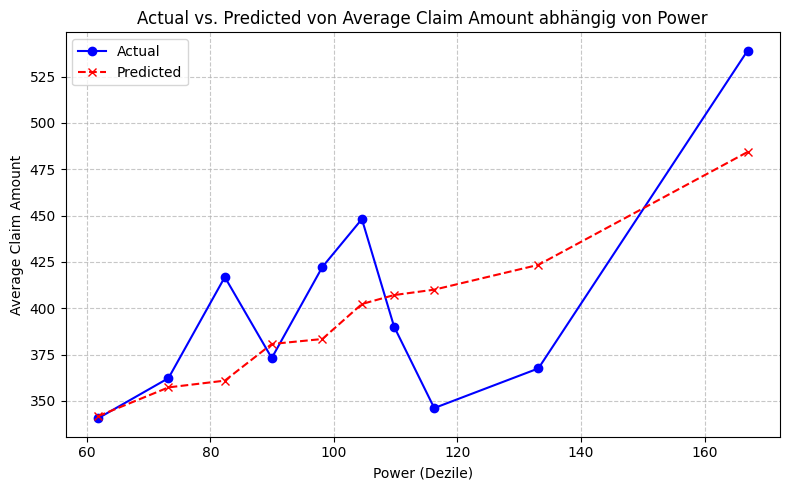

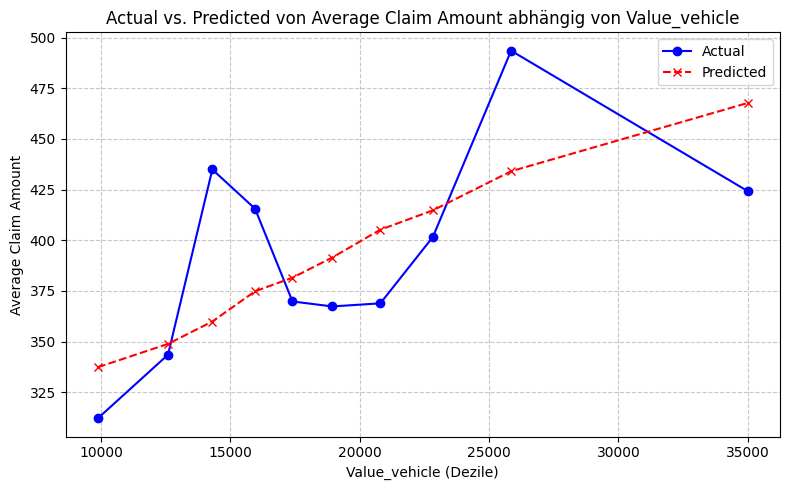

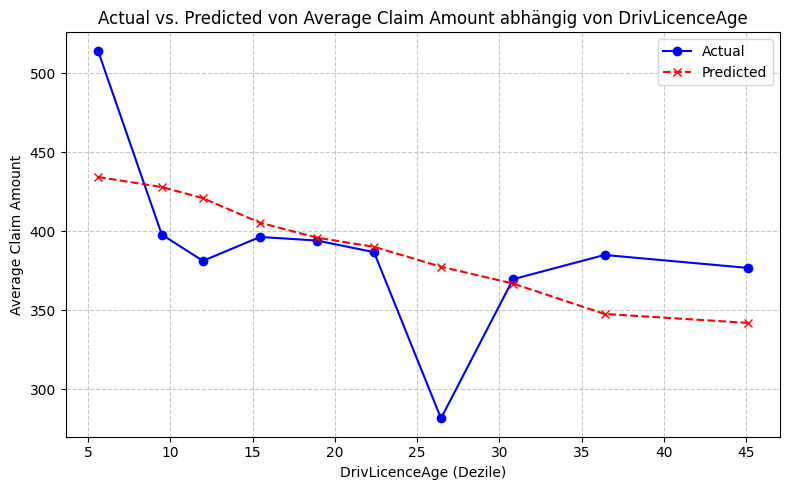

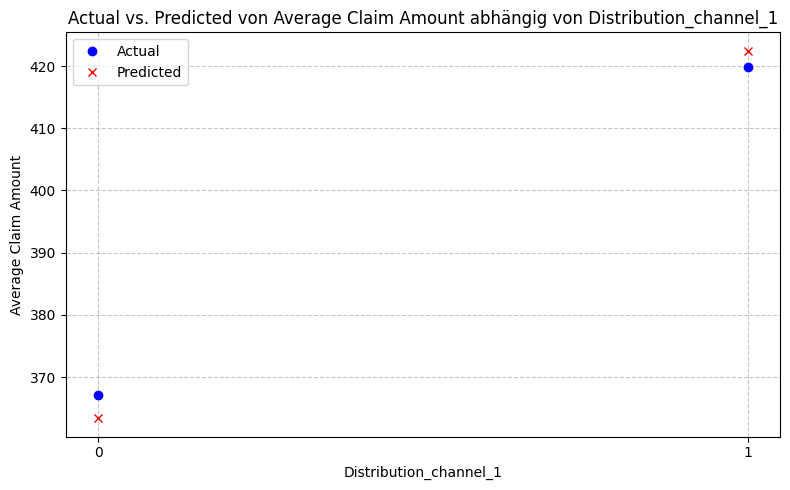

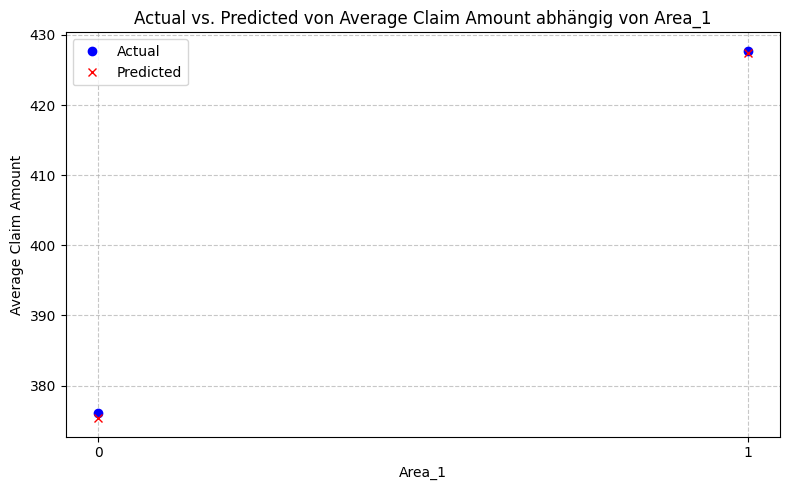

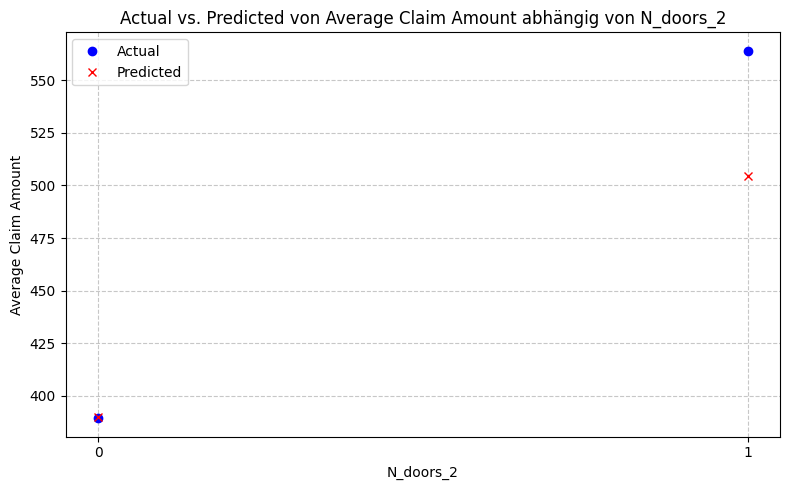

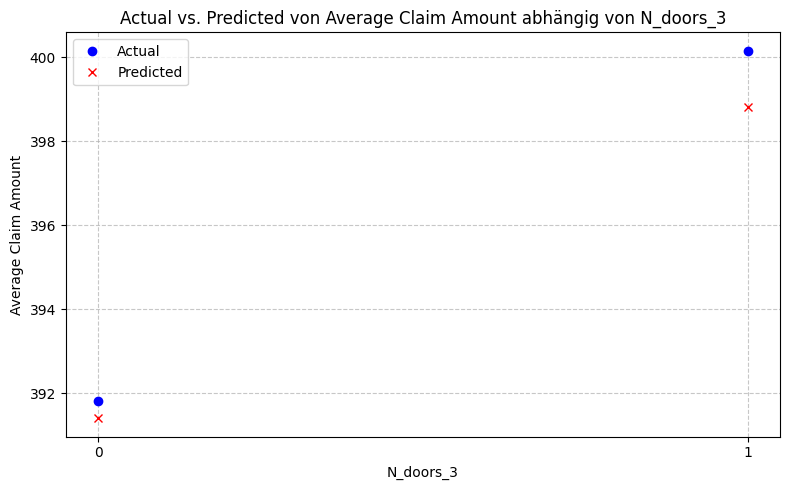

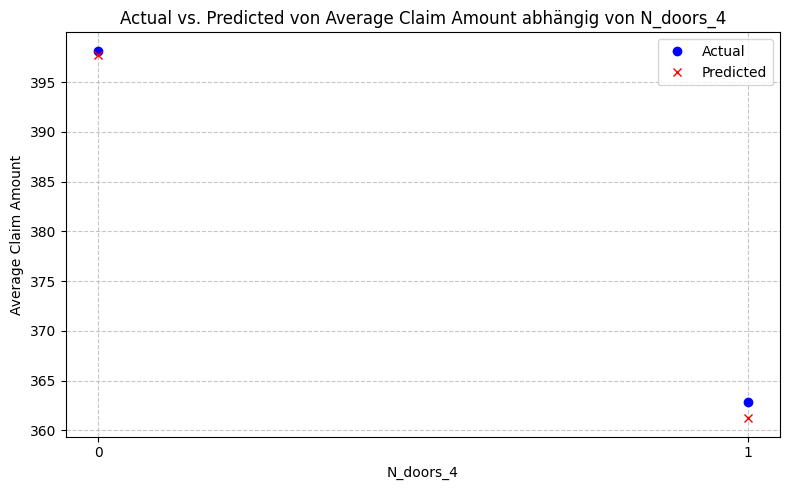

In [ ]:
# Identifiziere numerische und kategoriale Features
features_forward_selection_num = [f for f in var_num if f in features_forward_selection]
features_forward_selection_cat = [f for f in var_cat_oh if f in features_forward_selection]

# Numerische Merkmale
for feature in features_forward_selection_num:
    plt.figure(figsize=(8, 5))

    # Daten für Plot zusammenführen
    temp_df = pd.DataFrame({
        'Feature_Value': X_sev_train_glm[feature],
        'Actual_AvgClaimAmount': y_sev_train.values.ravel(),
        'Predicted_AvgClaimAmount': pred_sev_train_glm,
        'Weights': n_sev_train.values.ravel()
    })

    # Dezile des Merkmals berechnen
    temp_df['Dezile'] = pd.qcut(temp_df['Feature_Value'], q=10, duplicates='drop', labels=False) + 1

    # Gewichtete Durchschnitte pro Dezil berechnen
    grouped_data = temp_df.groupby('Dezile').agg(
        Feature_Mean=('Feature_Value', lambda x: np.average(x, weights=temp_df.loc[x.index, 'Weights'])),
        Avg_Actual=('Actual_AvgClaimAmount', lambda x: np.average(x, weights=temp_df.loc[x.index, 'Weights'])),
        Avg_Predicted=('Predicted_AvgClaimAmount', lambda x: np.average(x, weights=temp_df.loc[x.index, 'Weights']))
    ).reset_index()

    # Ergebnisse visualisieren
    plt.plot(grouped_data['Feature_Mean'], grouped_data['Avg_Actual'], marker='o', linestyle='-', color='blue', label='Actual')
    plt.plot(grouped_data['Feature_Mean'], grouped_data['Avg_Predicted'], marker='x', linestyle='--', color='red', label='Predicted')
    plt.xlabel(f'{feature} (Dezile)')
    plt.legend()
    plt.title(f'Actual vs. Predicted von Average Claim Amount abhängig von {feature}')
    plt.ylabel('Average Claim Amount')
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()

# Kategoriale Merkmale
for feature in features_forward_selection_cat:
    plt.figure(figsize=(8, 5))

    # Daten für Plot zusammenführen
    temp_df = pd.DataFrame({
        'Feature_Value': X_sev_train_glm[feature],
        'Actual_AvgClaimAmount': y_sev_train.values.ravel(),
        'Predicted_AvgClaimAmount': pred_sev_train_glm,
        'Weights': n_sev_train.values.ravel()
    })

    # Gewichtete Durchschnitte nach Ausprägung (0 und 1) berechnen
    grouped_data = temp_df.groupby('Feature_Value').agg(
        Avg_Actual=('Actual_AvgClaimAmount', lambda x: np.average(x, weights=temp_df.loc[x.index, 'Weights'])),
        Avg_Predicted=('Predicted_AvgClaimAmount', lambda x: np.average(x, weights=temp_df.loc[x.index, 'Weights']))
    ).reset_index()

    # Ergebnisse visualisieren
    plt.plot(grouped_data['Feature_Value'], grouped_data['Avg_Actual'], marker='o', linestyle='', color='blue', label='Actual')
    plt.plot(grouped_data['Feature_Value'], grouped_data['Avg_Predicted'], marker='x', linestyle='', color='red', label='Predicted')
    plt.legend()
    plt.xlabel(feature)
    plt.xticks([0, 1])
    plt.title(f'Actual vs. Predicted von Average Claim Amount abhängig von {feature}')
    plt.ylabel('Average Claim Amount')
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()

Während die Schadenhöhen bezüglich der im GLM aufgenommenen Dummy-Variablen typischerweise sehr gut getroffen werden, zeigen sich bei den numerischen Merkmalen relativ unruhige Verläufe in den Beobachtungen, welche das GLM bei seinen Vorhersagen in geglätteter Weise berücksichtigt.

Für Severity-Modelle generell eignet sich die Gamma-Verteilung zunächst aufgrund der für Schadenhöhen typischen Positivität und Rechtsschiefe.
Alternativen stellen beispielsweise die Log-Normal-, Pareto- oder inverse Gauß-Verteilung dar.
Die Gamma-Verteilung besitzt viele Vorteile, so passt etwa die Heteroskedastik mit näherungsweise zum quadrierten Mittelwert proportionaler Varianz häufig gut zur Praxis.
Im Kontext von GLMs sorgt sie mit Log-Link für eine einfache, multiplikative Interpretation, Skaleninvarianz sowie bei Wahl der Gamma-Devianz für die bereits beschriebene Konsistenz zwischen Training und Evaluation.
Die Gamma-Verteilung ist als Teil der Exponentialfamilie mathematisch leicht handhabbar, numerisch robust und leicht mit Gewichten oder Offsets kombinierbar, sodass sie gerade in der Tarifierung mit Fokus auf den Erwartungswert der Severity meistens eine gute Wahl ist.
Der größte Nachteil der Gamma-Verteilung besteht im häufig zu leichten Tail, wodurch sehr große Schäden und Extremquantile unterschätzt werden.
Zusätzlich ist sie in ihrer Flexibilität eingeschränkt, wenn die angenommene Mittelwert-Varianz-Bezienung nicht gut passt, und kann bei der Schätzung durch einzelne sehr hohe Schäden überproportional beeinflusst werden.
Eine Punktmasse wie in unserem Datensatz vorhanden ist bei all diesen Verteilungen nicht vorgesehen.

Auch im Kontext von GLMs helfen Regularisierungstechniken vor allem bei der Vermeidung von Overfitting.
Gerade wenn die Anzahl der Beobachtungen im Verhältnis zu den Merkmalen klein ist, neigen GLMs dazu, Rauschen in den Daten als echtes Signal zu lernen.
Aufgrund ihrer linearen Natur haben sie außerdem Schwierigkeiten bei Multikollinearität in den Daten.
Durch Regularisierung werden zu große Koeffizienten bestraft und die Modellschätzungen auf diese Weise auch bei vielen korrelierten Prädiktoren stabilisiert.
Dadurch erhöht sie zwar leicht den Bias leicht, senkt aber die Varianz zum Teil deutlich, was häufig die Performance auf ungesehenen Daten erhöht.
Klassische Verfahren sind LASSO- und Ridge-Regression sowie deren Kombination in einem elastischen Netz, wo die L1- bzw. L2-Norm der geschätzten Koeffizienten als zusätzlicher Strafterm in die Verlustfunktion eingehen.
LASSO setzt einzelne Koeffizienten sogar auf genau 0 und dient somit gleichzeitig als Verfahren zur Feature-Selection, deren Erkenntnisse wiederum auch andere Modelle schlanker, robuster und interpretierbarer machen können.

### d) GAM (Generalized Additive Model)

**Erstellen Sie ein Generalized Additive Model (GAM) auf Basis der
gleichen Variablen wie in Teilaufgabe c). Speichern Sie die Ergebnisse. Plotten Sie die partiellen Abhängigkeiten
(Splines) für die kontinuierlichen Merkmale Ihres GAM. Identifizieren Sie zwei Merkmale mit deutlichem
nicht-linearem Verlauf und interpretieren Sie diese aus aktuarieller Sicht. Warum ist ein GAM häufig
einem linearen GLM überlegen?**

**Erstellen Sie im Anschluss eine Vergleichstabelle aller Severity-Modelle und kommentieren Sie das Ergebnis.**

Wir nutzen die durch die Forward-Selection ermittelten Variablen nun für das Training eines Generalized Additive Models (GAM).
Eine Standardisierung ist dafür in der Regel nicht notwendig.


In [ ]:
# Auswahl der durch die Forward Selection bestimmten Merkmale für das GAM
feature_names_sev_gam = features_forward_selection_num + features_forward_selection_cat

X_sev_train_gam = data_sev_train[feature_names_sev_gam].copy()
X_sev_val_gam = data_sev_val[feature_names_sev_gam].copy()
X_sev_test_gam = data_sev_test[feature_names_sev_gam].copy()

Numerische Merkmale behandeln wir im GAM üblicherweise durch kubische Splines.
Häufig wird die Anzahl der Basisplines dabei zur Ermöglichung von genug Flexibilität recht großzügig gesetzt und anschließend der Strafparameter lambda optimiert, um Overfitting zu vermeiden.
Wir verzichten an dieser Stelle auf dieses Tuning und wählen stattdessen recht konservativ jeweils sieben Basissplines, die zu $7-3-1=3$ inneren Knoten korrespondieren.
Nach dem Training des GAMs evaluieren wir das Modell und speichern es in die Ergebnisdatenstruktur.

In [ ]:
# Technischer Schritt: Erstelle die sogenannten GAM Terme, s (smooth) für numerische und f (factor) für kategoriale Features
gam_terms_list = []
for i in range(len(features_forward_selection_num)):
    gam_terms_list.append(pygam.s(i, n_splines=7)) # sieben Basissplines
for i in range(len(features_forward_selection_cat)):
    gam_terms_list.append(pygam.f(len(features_forward_selection_num)+i))

gam_terms = gam_terms_list[0]
for term in gam_terms_list[1:]:
    gam_terms += term

# Startzeit messen
start_time_sev_gam = time.time()

# Trainiere das GAM mit Gamma-Familie, Log-Link und N_claims_year als Gewicht
sev_gam_fit = pygam.GammaGAM(gam_terms, fit_intercept=True).fit(
                            X_sev_train_gam, y_sev_train.values.ravel(),
                             weights=n_sev_train.values.ravel())

# Endzeit messen und Modellierungszeit berechnen
end_time_sev_gam = time.time()
modeling_time_sev_gam = end_time_sev_gam - start_time_sev_gam

print("Generalisiertes Additives Modell (GAM) mit Gamma-Familie (Log-Link):\n")

print(f"Modellierungszeit für GAM: {modeling_time_sev_gam:.2f} Sekunden\n")

# Vorhersagen auf Trainings-, Validierungs- und Testdaten generieren
pred_sev_train_gam = sev_gam_fit.predict(X_sev_train_gam)
pred_sev_val_gam = sev_gam_fit.predict(X_sev_val_gam)
pred_sev_test_gam = sev_gam_fit.predict(X_sev_test_gam)

# Berechne die Gamma-Devianz
gamma_deviance_train_gam = calculate_gamma_deviance(pred_sev_train_gam, y_sev_train, n_sev_train)
gamma_deviance_val_gam = calculate_gamma_deviance(pred_sev_val_gam, y_sev_val, n_sev_val)
gamma_deviance_test_gam = calculate_gamma_deviance(pred_sev_test_gam, y_sev_test, n_sev_test)

print("Gamma-Devianz auf den Trainingsdaten:", gamma_deviance_train_gam.round(4))
print("Gamma-Devianz auf den Validierungsdaten:", gamma_deviance_val_gam.round(4))

# Ergebnisse des GAM in die Ergebnisdatenstruktur speichern
add_sev_model_result('GAM', gamma_deviance_train_gam, gamma_deviance_val_gam, gamma_deviance_test_gam,
                     time_forward_selection, modeling_time_sev_gam)

Generalisiertes Additives Modell (GAM) mit Gamma-Familie (Log-Link):

Modellierungszeit für GAM: 0.18 Sekunden

Gamma-Devianz auf den Trainingsdaten: 1.805
Gamma-Devianz auf den Validierungsdaten: 1.9948


Im Anschluss visualisieren wir die partiellen Abhängigkeiten (Splines) für die numerischen Features.

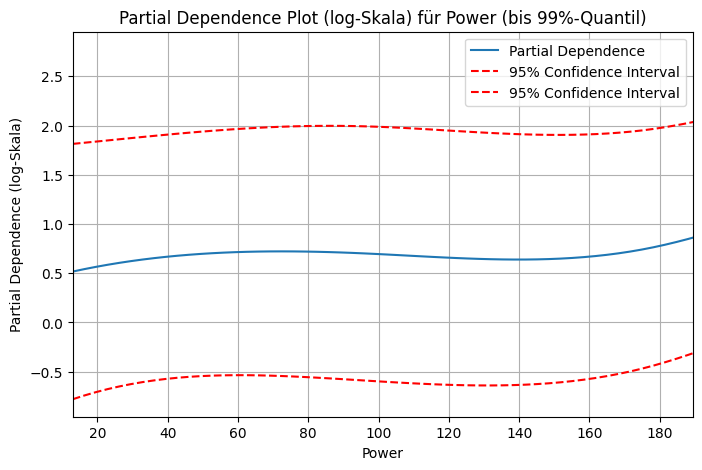

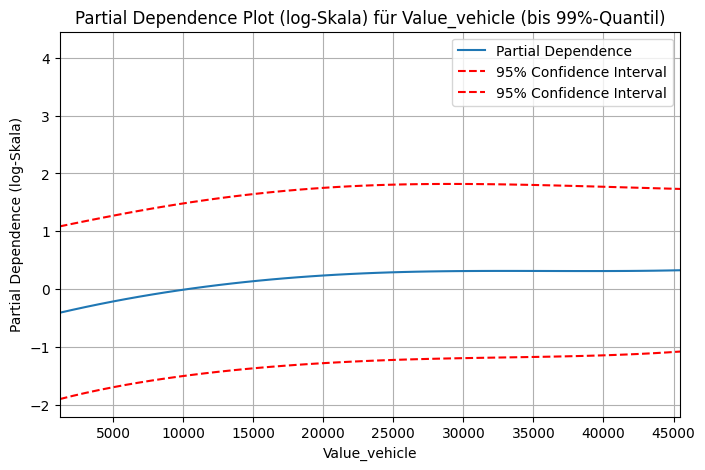

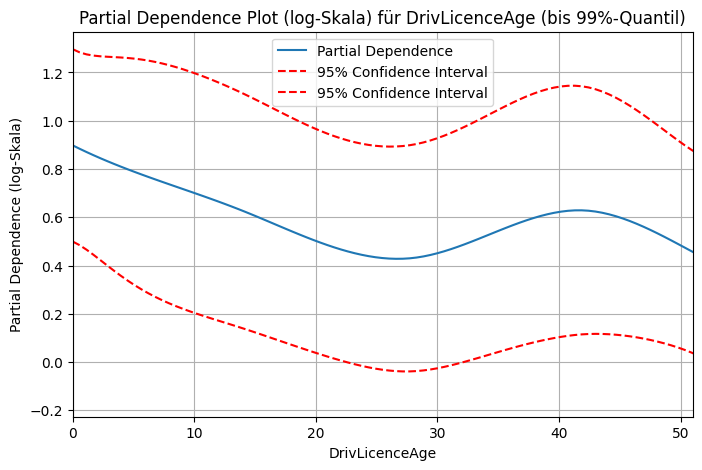

In [ ]:
# Plotten der partiellen Abhängigkeiten für kontinuierliche Merkmale
for i, feature in enumerate(features_forward_selection_num):

    # Berechne Minimum und 99%-Quantil des aktuellen Features
    min_val = X_sev_train_gam[feature].min()
    p99_val = X_sev_train_gam[feature].quantile(0.99)

    # Berechne die partiellen Abhängigkeiten und Konfidenzintervalle
    XX = sev_gam_fit.generate_X_grid(term=i)
    pdep, confi = sev_gam_fit.partial_dependence(term=i, X=XX, width=0.95)

    # Erstelle die Grafik
    plt.figure(figsize=(8, 5))
    plt.plot(XX[:, i], pdep, label='Partial Dependence')
    plt.plot(XX[:, i], confi, c='r', ls='--', label='95% Confidence Interval')
    plt.xlim(min_val, p99_val)
    plt.title(f'Partial Dependence Plot (log-Skala) für {feature} (bis 99%-Quantil)')
    plt.xlabel(feature)
    plt.ylabel('Partial Dependence (log-Skala)')
    plt.legend()
    plt.grid(True)
    plt.show()

Den deutlichsten nicht-linearen Verlauf (auf der log-Skala) erkennen wir beim Merkmal 'DrivLicenceAge'. Die prognostizierte Schadenhöhe sinkt mit steigender Fahrerfahrung zunächst kontinuierlich, bevor sie ab ca. 27 Jahren wieder steigt.
Vor dem Hintergrund besserer Gefahrenantizipation oder angemessenerer Geschwindigkeiten ist ein Rückgang in der Schwere des Schadens bis zu einem gewissen Punkt sehr plausibel.
Gleichzeitig ist dieses Feature natürlich stark positiv zu 'DrivAge' korreliert und ab einem bestimmten Alter kommt es durch langsamere Reaktionen wieder zu schwereren Unfällen.
Eine denkbare Begründung für den fallenden Verlauf am Ende wäre, dass Menschen ab einem gewissen Alter eher kurze Strecken fahren und Unfälle daher potentiell bei niedrigeren Geschwindigkeiten passieren.
Hier sollten wir aber definitiv weitere Untersuchungen anstellen, ob beim Spline in diesem Randbereich möglicherweise eine gewisse Überanpassung vorliegt.
Auch bei 'Value_vehicle' stellen wir einen nicht-linearen Verlauf fest, denn bis zu einem Fahrzeugwert von etwa 20.000 Euro steigt der PDP gut erkennbar an, ehe er danach stark abflacht.
Dass auch 'Power' als stark korreliertes Merkmal im GAM aufgenommen ist, erschwert die Interpretation hier etwas.
Dennoch scheint es plausibel, dass Fahrzeuge zunächst mit steigendem Wert (in Kombination mit Masse, Leistung und Geschwindigkeit) in der Regel schwerere Unfälle verursachen.
Ab einem gewissen Preislevel könnte beispielsweise die bessere Ausstattung in Form von Fahrassistenzsystemen oder die Tatsache, dass solche Autos eher von älteren Menschen gefahren werden, diesem Trend entgegenwirken.

Ein GAM ist einem linearen GLM häufig überlegen, weil es die starre Annahme linearer Zusammenhänge aufbricht (bei gleicher Verteilungs- und Link-Struktur).
Ein GLM geht davon aus, dass jedes erklärende Merkmal einen linearen Effekt auf den gelinkten Erwartungswert hat (für andere Einflüsse müssen die entsprechend transformierten Features explizit im Vorhinein als eigene Variable übergeben werden). In der Realität sind die Zusammenhänge typischerweise aber komplizierter und ein GAM kann diesen mithilfe von automatisch angepassten geglätteten Funktionen deutlich gerechter werden.
Glättungsstrafen regulieren dabei die Flexibilität automatisch und mindern die Gefahr von Overfitting, was im Ergebnis meistens zu besserer Prognosequalität führt.
Gleichzeitig behält ein GAM dabei weiterhin den großen Vorteil von einfacher Struktur und guter Interpretierbarkeit, beispielsweise kann der Effekt einzelner Variablen transparent durch PDPs anzeigt werden.

Zum Abschluss vergleichen wir die Ergebnisse unserer Severity-Modellierung.

In [ ]:
# Ergebnisdatenstruktur anzeigen
display_sev_model_results()

Model,Train_Metric,Validation_Metric,Test_Metric,Optimization_Time,Modeling_Time
GLM,1.8208,1.9963,1.8027,2.05,0.03
GAM,1.8050,1.9948,1.8026,2.05,0.18


Das GAM weist in allen drei Splits die geringere Gamma-Devianz auf, wobei die Abweichung gerade in den Validierungs- und Testdaten minimal ist.
Es fällt auf, dass beide Modelle die insgesamt niedrigste Devianz in den Testdaten annehmen, während der Wert in den ebenfalls ungesehen Validierungsdaten deutlich größer ist.
In Anbetracht der relativ geringen Zahl an Beobachtungen ist ein solches Bild durchaus möglich, dennoch erscheinen gerade vor dem Hintergrund der Punktmasse eine Prüfung der Vergleichbarkeit der Splits und ein generelles Bewusstsein über die Varianz unserer Metrik sinnvoll.
Bei einer Modellauswahl spielen daher wie immer auch praktische Gesichtspunkte wie die Einfachheit des GLMs oder die fachliche Plausibilität der GAM-Effekte eine Rolle.
Zusätzlich scheint aufgrund der minimalen Performance-Unterschiede an dieser Stelle tatsächlich auch ein Vergleich mit weiteren Metriken sinnvoll.

## Aufgabe B4: Modellierung des Schadenbedarfs

**Ziel dieser Aufgabe ist die direkte Schätzung des erwarteten Schadenbedarfs pro Police (*Pure Premium*), d. h.
*Cost_claims_year* / *Exposure*. Dies kann entweder durch Multiplikation der besten Frequency- und Severity-
Modelle (Produktmodell) oder durch direkte Tweedie-Regression erfolgen.**

### a) Produktmodell: Frequency × Severity

**Kombinieren Sie das jeweils beste Frequency und Severity-
Modell zu einem Produktmodell. Berechnen Sie anschließend die Produktprognose (Frequency × Severity)
und evaluieren Sie das Modell mit Tweedie Deviance. Fügen Sie die Ergebnisse einer geeigneten Ergebnisstruktur
hinzu. Diskutieren Sie, welche Vor- und Nachteile das Produktmodell im Vergleich zu einer
direkten Modellierung hat.**

Im letzten Schritt sind wir nun an der Prognose des durschnittlichen Schadenbedarfs interessiert.
Ähnlich wie im Rahmen der Frequency- bzw. Severity-Modellierung kappen wir die Zielvariable aus Stabilitätsgründen und entscheiden uns hierbei für das 99%-Quantil der Trainingsdatensätze mit positivem Target-Wert.

In [ ]:
# Kappen der Zielvariable am 99%-Quantil der positiven Werte in den Trainingsdaten
y_pp_train_cap = (y_pp_train[y_pp_train['Pure_premium'] > 0]['Pure_premium']).quantile(0.99)

y_pp_train['Pure_premium'] = np.minimum(y_pp_train['Pure_premium'], y_pp_train_cap)
y_pp_val['Pure_premium'] = np.minimum(y_pp_val['Pure_premium'], y_pp_train_cap)
y_pp_test['Pure_premium'] = np.minimum(y_pp_test['Pure_premium'], y_pp_train_cap)

Die Modell-Evaluierung soll dabei mithilfe von Tweedie-Devianz erfolgen.
Diese hängt explizit vom Wert des Tweedie-Power-Parameters p ab, welchen wir daher im Sinne der Vergleichbarkeit vorab festsetzen müssen.
Alternativ könnten wir stattdessen eine Metrik benutzen, welche unabhängig von der Verteilungsform funktioniert.
Ein für die vorliegenden Daten geeigneter Wert für p kann beispielsweise durch die Profile-Likelihood-Methode, welche in Python vom Paket 'statsmodels' unterstützt wird, oder über den Mittelwert-Varianz-Zusammenhang der Tweedie-Verteilung ermittelt werden.
Darüber hinaus existieren häufig branchenübliche Standardwerte (siehe nächste Teilaufgabe) und wir entscheiden uns an dieser Stelle für 1,7 als den festen Power-Parameter zur Evaluierung aller nachfolgenden Modelle.

In [ ]:
# Festsetzen des Tweedie-Power-Parameters für die Tweedie-Devianz als Evaluierungsmetrik
p_tweedie = 1.7

In Analogie zum Vorgehen bei der Frequency- bzw- Severity-Modellierung implementieren wir die (gewichtete) Tweedie-Devianz pro Exposure manuell als Hilfsfunktion, wobei wir uns auf den Fall $1 < p < 2$ beschränken können.
Alternativ kann die Funktion 'mean_tweedie_deviance' aus dem Paket 'sklearn' verwendet werden, welche exakt dieselben Ergebnisse liefert.

In [ ]:
# Hilfsfunktion zur Berechnung der gewichteten Tweedie-Devianz pro Exposure für 1 < p < 2
def calculate_tweedie_deviance(pred, obs, exposure, p):

    pred = np.asarray(pred).ravel()
    obs = np.asarray(obs).ravel()
    exposure = np.asarray(exposure).ravel()

    # Sicherstellen, dass pred nicht 0 ist, um Division durch 0 zu vermeiden
    pred = np.maximum(pred, 1e-10)

    # Berechnung der einzelnen Devianz-Terme
    # Formel für 1 < p < 2: obs^(2-p) / ((1-p) * (2-p)) - obs * pred^(1-p) / (1-p) + pred^(2-p) / (2-p)
    deviance_terms = np.power(obs, (2 - p)) / ((1 - p) * (2 - p)) - obs * np.power(pred, (1 - p)) / (1 - p) + np.power(pred, (2 - p)) / (2 - p)

    # Gesamte gewichtete Devianz
    total_weighted_deviance = 2 * np.sum(exposure * deviance_terms)

    # Gewichtete Devianz pro Exposure
    weighted_deviance_per_exposure = total_weighted_deviance / np.sum(exposure)
    return weighted_deviance_per_exposure

Wir legen auch dieses Mal eine Ergebnisdatenstruktur zum übersichtlichen Vergleich der Schadenbedarf-Modelle an.

In [ ]:
# Ergebnisdatenstruktur für Schadenbedarf-Modell-Evaluation anlegen
pp_model_results = pd.DataFrame(columns=[
    'Model',
    'Train_Metric',
    'Validation_Metric',
    'Test_Metric',
    'Optimization_Time',
    'Modeling_Time'
])

# Hilfsfunktion zum Hinzufügen eines Eintrags zur Ergebnisdatenstruktur
def add_pp_model_result(model_name, train_metric, validation_metric, test_metric, optimization_time, modeling_time):
    global pp_model_results
    new_row = pd.DataFrame([{
        'Model': model_name,
        'Train_Metric': train_metric,
        'Validation_Metric': validation_metric,
        'Test_Metric': test_metric,
        'Optimization_Time': optimization_time,
        'Modeling_Time': modeling_time
    }])
    pp_model_results = pd.concat([pp_model_results, new_row], ignore_index=True)

# Hilfsfunktion zur Ausgabe der Ergebnisdatenstruktur
def display_pp_model_results():
    # Dictionary für die Formatierung pro Spalte
    format_dict = {
        'Train_Metric': '{:.4f}',
        'Validation_Metric': '{:.4f}',
        'Test_Metric': '{:.4f}',
        'Optimization_Time': '{:.2f}',
        'Modeling_Time': '{:.2f}'
    }
    # Ergebnisdatenstruktur ausgeben
    display(pp_model_results.style.format(format_dict).hide(axis='index'))

Wir kombinieren nun das jeweils beste Frequency- und Severity-Modell zu einem Produktmodell, wobei wir uns für eine pragmatische Implementierung als Funktion statt einer dedizierten Predictor-Klasse entscheiden.
Im Sinne der Evaluationsmetrik auf den Testdaten als Kriterium fällt die Wahl auf den Random Forest, welcher passenderweise bereits Schadenfrequenzen (und keine -anzahlen) vorhersagt, und auf das GAM.
Beide Modelle verwenden die nicht-standardisierten Variablen, das GAM beschränkt sich dabei auf acht durch Feature-Selection ermittelte Merkmale.
Wir evaluieren das Produktmodell mithilfe der Tweedie-Devianz zum festgesetzten Power-Parameter 1,7 und speichern die Resultate in der Ergebnisdatenstruktur ab.

In [ ]:
# Features, welche von Random Forest bzw. GAM verwendet werden
product_model_features_freq_rf = var_num + var_cat_oh
product_model_features_sev_gam = feature_names_sev_gam

# Produktmodell aus bestem Frequency-Modell (Random Forest) und bestem Severity-Modell (GAM)
def pp_product_model_rf_gam(X):
    # Bereite Features für Random Forest vor
    X_freq = X[product_model_features_freq_rf]

    #Vorhersage der Frequency
    pred_freq = random_forest_model.predict(X_freq)

    #Sicherstellen, dass die Frequenzen nicht negativ sind
    pred_freq = np.maximum(pred_freq, 0)

    # Bereite Features für das GAM vor
    X_sev = X[product_model_features_sev_gam]

    # Vorhersage der Severity (ist autmoatisch größer als 0)
    pred_sev = sev_gam_fit.predict(X_sev)

    # Berechnung des vorhergesagten Schadenbedarfs
    pred_pp = pred_freq * pred_sev
    return pred_pp

# Vorhersage des Schadenbedarfs durch das Produktmodell
pred_pp_train_freq_x_sev = pp_product_model_rf_gam(X_train_ensemble)
pred_pp_val_freq_x_sev = pp_product_model_rf_gam(X_val_ensemble)
pred_pp_test_freq_x_sev = pp_product_model_rf_gam(X_test_ensemble)

# Berechne kombinierte Optimierungszeit und Modellierungszeit
optimization_time_pp_freq_x_sev = 0 + time_forward_selection
modeling_time_pp_freq_x_sev = modeling_time_random_forest + modeling_time_sev_gam

print("Produktmodell kombiniert aus bestem Frequency-Modell (Random Forest) und Severity-Modell (GAM):\n")
print(f"Kombinierte Optimierungszeit: {optimization_time_pp_freq_x_sev:.2f} Sekunden")
print(f"Kombinierte Modellierungszeit: {modeling_time_pp_freq_x_sev:.2f} Sekunden\n")


# Berechne die Tweedie-Devianz
tweedie_deviance_train_freq_x_sev = calculate_tweedie_deviance(pred_pp_train_freq_x_sev, y_pp_train, expo_train, p_tweedie)
tweedie_deviance_val_freq_x_sev = calculate_tweedie_deviance(pred_pp_val_freq_x_sev, y_pp_val, expo_val, p_tweedie)
tweedie_deviance_test_freq_x_sev = calculate_tweedie_deviance(pred_pp_test_freq_x_sev, y_pp_test, expo_test, p_tweedie)

print(f"Tweedie-Devianz (p={p_tweedie:.2f}) auf den Trainingsdaten: {tweedie_deviance_train_freq_x_sev:.4f}")
print(f"Tweedie-Devianz (p={p_tweedie:.2f}) auf den Validierungsdaten: {tweedie_deviance_val_freq_x_sev:.4f}")

# Speichern der Ergebnisse in der Ergebnisdatenstruktur
add_pp_model_result('Freq x Sev', tweedie_deviance_train_freq_x_sev, tweedie_deviance_val_freq_x_sev, tweedie_deviance_test_freq_x_sev,
                    optimization_time_pp_freq_x_sev, modeling_time_pp_freq_x_sev)

Produktmodell kombiniert aus bestem Frequency-Modell (Random Forest) und Severity-Modell (GAM):

Kombinierte Optimierungszeit: 2.05 Sekunden
Kombinierte Modellierungszeit: 4.28 Sekunden

Tweedie-Devianz (p=1.70) auf den Trainingsdaten: 36.4873
Tweedie-Devianz (p=1.70) auf den Validierungsdaten: 39.2682


Die Vorhersage des Schadenbedarfs als Produkt eines Frequency- und eines Severity-Modells hat im Vergleich zu einer direkten Modellierung viele Vorteile.
Da beide Komponenten oft durch verschiedene Risikofaktoren beeinflusst werden, ermöglicht die getrennte Modellierung gezieltere Analysen und Kontrolle.
Dies sorgt für ein tieferes Verständnis, ob sich der prognostizierte Schadenbedarf eher aufgrund der Schadenhäufigkeit oder der -höhe ändert, und der Einfluss von einzelnen Merkmalen lässt sich leichter interpretieren.
Gleichzeitig herrscht höhere Flexibilität bei der Wahl der Modellklassen, weil wir uns sowohl bei Frequency als auch bei Severity für die jeweils passendste Methodik entscheiden können.
Demgegenüber steht der offensichtliche Nachteil, dass sich bei einer Trennung in zwei Modelle der Komplexität, Aufwand sowie Fehleranfälligkeit erhöhen.
Außerdem ignoriert das Produktmodell mögliche Abhängigkeiten zwischen Schadenhäufigkeit und -höhe, welche in der Praxis durchaus vorliegen können.
Eine direkte Modellierung des Schadenbedarfs kann diese Abhängigkeiten besser berücksichtigen und zeichnet sich durch einen ganzheitlichen Blick sowie Einfachheit aus.
Nachteilig sind dafür entsprechend der Informationsverlust, was der Treiber für ein hohes Risiko ist, die schwierigere Interpretierbarkeit sowie tendenziell größere Probleme bzw. verzerrtere Ergebnisse bei sehr instabilen Daten (mit wenigen, aber extremen Großschäden).

### b) Allgemeine Fragen zu Tweedie Modellen, GLM-Tweedie-Regressor mit Hyperparameter-Tuning

**Erläutern Sie die Tweedie-Verteilung als Exponentialfamilie mit Power-Parameter (*p*). Welche bekannten
Verteilungen erhält man für *p = 0, 1, 2, 3*? Welche Werte sind für Schadenbedarf-Modelle typischerweise
relevant und warum?**

**Wie lässt sich der Zusammenhang zwischen *μ*, *ϕ* und *p* zur Einschätzung der Modellgüte nutzen? Berechnen
und interpretieren Sie den Dispersion-Parameter des Tweedie-Modells.**

**Schätzen Sie ein GLM mit Tweedie-Verlustfunktion (TweedieRegressor). Führen Sie einen Grid Search über
die Hyperparameter *alpha* und *power* durch. Geben Sie die besten Parameter und die Tweedie Deviance
aus und fügen Sie sowohl das Baseline-Modell als auch das optimierte Modell der Ergebnisstruktur hinzu.**

Die Tweedie-Verteilung stellt einen Spezialfall der natürlichen Exponentialfamilie dar und ist in diesem Kontext charakterisiert durch die Varianzfunktion $V(\mu) = \mu^p$ mit Power-Parameter p (für $p\notin\{1;2\}$ ist der kanonische Parameter dabei gegeben durch $\theta(\mu)=\frac{\mu^{1-p}}{1-p}$ und die kumulantenerzeugende Funktion durch $\kappa(\theta)=\frac{\mu^{2-p}}{2-p}$).
Sie zeichnet sich also dadurch aus, dass die Varianz $\text{Var}(Y)$ in einer festen Beziehung $$\text{Var}(Y)=\phi\cdot\mu^p$$
zum Erwartungswert $\mu$ steht, wobei $\phi$ der Dispersionsparameter der Exponentialfamilie ist.
Die Tweedie-Verteilung umfasst einige bekannte Verteilungen als Spezialfälle, so ergibt sich für $p=0$ die Normalverteilung mit konstanter Varianz, für $p=1$ bzw. $p=2$ die Poisson- bzw. Gamma-Verteilung mit zum Mittelwert proportionaler Varianz bzw. Standardabweichung und für $p=3$ die inverse Gauß-Verteilung mit noch schwererem Tail.

Für Schadenbedarf-Modelle sind typischerweise die sogenannten Poisson-Gamma-Mischverteilungen im Bereich $1 < p < 2$ relevant, welche eine positive Wahrscheinlichkeitsmasse bei 0 zulassen und diese mit einem stetigen Gamma-artigen Teil kombinieren.
Dies bildet genau die Realität ab, in der ein Großteil der Versicherungsnehmer schadenfrei bleibt und für den Rest positive und rechtsschief verteilte Beträge anfallen.
In der Versicherungsmathematik haben sich typische Bereiche etabliert, welche in etwa von 1,1 bei kleinen oder konstanten Schäden bis hin zu p=1,9 bei extrem schwankenden Schadenhöhen und Dominanz von wenigen Großschäden reichen.
Im Kontext von KFZ- oder Sachportfolios werden meistens Werte zwischen 1,5 und 1,7 betrachtet.
Wir weisen an dieser Stelle darauf hin, dass die in Teil A identifizierte Häufung von Schäden bei einer festen Höhe wie schon in Teilaufgabe B3 b) für die Gamma-Verteilung diskutiert nicht mit dieser Verteilungsannahme im Einklang steht und daher gewisse Probleme mit sich bringt.

Der Dispersionsparameter $\phi$ ist ein Proportionalitätsfaktor und misst die Reststreuung nach Abzug der durch $\mu^p$ erklärten Varianz.
Der Zusammenhang zwischen $\mu$, $\phi$ und p lässt sich dabei auf vielfältige Weise zur Einschätzung der Modellgüte nutzen.
So können wir zum Beispiel eine Mittelwert-Varianz-Prüfung durchführen, bei welcher die Daten zunächst basierend auf den Vorhersagen in Quantile eingeteilt werden.
Pro Gruppe sollte der Quotient aus empirischer Varianz dem mit p potentierten Mittelwert annähernd konstant sein (nämlich $\phi$), starke Trends weisen hingegen auf falsches p oder eine unpassende Modellspezifikation hin.
Eine weitere Möglichkeit besteht in der Residuen-Analyse, bei welcher die skalierten Pearson-Residuen $r_i = \frac{y_i - \hat{\mu}_i}{\sqrt{\hat{\phi} \hat{\mu}_i^p}}$ ausgerechnet werden.
Wenn das Modell und damit p korrekt gewählt ist, sollten diese Residuen annähernd varianzstabil (mit Varianz 1), symmetrisch um 0 und ohne Muster über $\mu$ sein.
Der Dispersionsparameter eines Tweedie-Modells wird in der Praxis meistens über die Pearson-Statistik als
$$\hat{\phi} = \frac{1}{n-k} \sum_{i=1}^{n} \frac{(y_i - \hat{\mu}_i)^2}{\hat{\mu}_i^p}$$
geschätzt, wobei $n-k$ als Differenz von Beobachtungen und Parametern die Anzahl der Freitheitsgrade angibt.
Ist der berechnete Dispersionsparameter deutlich größer als nach der theoretischen Verteilung erwartet, deutet dies auf Überdispersion hin.

Wir trainieren nun ein Tweedie-GLM mit log-Link als Baseline und führen anschließend eine Grid-Search über den Power-Parameter 'power' sowie den Regularisierungsparameter 'alpha' durch.
Spätestens in diesem Kontext müssen wir die die Features standardisieren.


In [ ]:
# Auswahl der numerischen und One-Hot-kodierten Features für die GLMs
X_pp_train_glm = data_train[var_num + var_cat_oh].copy()
X_pp_val_glm = data_val[var_num + var_cat_oh].copy()
X_pp_test_glm = data_test[var_num + var_cat_oh].copy()

# Standardisieren der Features, Scaler nur auf Trainingsdaten fitten
scaler_pp_glm = sklearn.preprocessing.StandardScaler()
X_pp_train_glm_scaled = scaler_pp_glm.fit_transform(X_pp_train_glm)
X_pp_val_glm_scaled = scaler_pp_glm.transform(X_pp_val_glm)
X_pp_test_glm_scaled = scaler_pp_glm.transform(X_pp_test_glm)

X_pp_train_glm_scaled = pd.DataFrame(X_pp_train_glm_scaled, columns=X_pp_train_glm.columns, index=X_pp_train_glm.index)
X_pp_val_glm_scaled = pd.DataFrame(X_pp_val_glm_scaled, columns=X_pp_val_glm.columns, index=X_pp_val_glm.index)
X_pp_test_glm_scaled = pd.DataFrame(X_pp_test_glm_scaled, columns=X_pp_test_glm.columns, index=X_pp_test_glm.index)

Wir schätzen das Baseline-Modell mit dem fest gewählten $p=1,7$ und ohne Regularisierung unter Berücksichtigung des Exposures als Gewicht, berechnen die Tweedie-Devianz und halten die Resultate in der Ergebnisdatenstruktur fest.

In [ ]:
# Startzeit messen
start_time_pp_glm = time.time()

# Trainiere das Tweedie GLM
pp_glm = sklearn.linear_model.TweedieRegressor(power=p_tweedie, link='log')
pp_glm_fit = pp_glm.fit(X_pp_train_glm_scaled,
                        y_pp_train.values.ravel(),
                        sample_weight=expo_train.values.ravel())

# Endzeit messen und Modellierungszeit berechnen
end_time_pp_glm = time.time()
modeling_time_pp_glm = end_time_pp_glm - start_time_pp_glm

print("Generalisiertes Lineares Modell (GLM) mit Tweedie-Familie (Log-Link):\n")
print("Power-Parameter power =", p_tweedie)
print("Regularisierungparameter alpha = 0")
print(f"\nBenötigte Zeit für die Modellierung: {modeling_time_pp_glm:.2f} Sekunden\n")

# Vorhersagen auf Trainings-, Validierungs- und Testdaten generieren
pred_pp_train_glm = pp_glm_fit.predict(X_pp_train_glm_scaled)
pred_pp_val_glm = pp_glm_fit.predict(X_pp_val_glm_scaled)
pred_pp_test_glm = pp_glm_fit.predict(X_pp_test_glm_scaled)

# Berechne die Tweedie-Devianz
tweedie_deviance_train_glm = calculate_tweedie_deviance(pred_pp_train_glm, y_pp_train, expo_train, p_tweedie)
tweedie_deviance_val_glm = calculate_tweedie_deviance(pred_pp_val_glm, y_pp_val, expo_val, p_tweedie)
tweedie_deviance_test_glm = calculate_tweedie_deviance(pred_pp_test_glm, y_pp_test, expo_test, p_tweedie)

print(f"Tweedie-Devianz (p={p_tweedie}) auf den Trainingsdaten: {tweedie_deviance_train_glm:.4f}")
print(f"Tweedie-Devianz (p={p_tweedie}) auf den Validierungsdaten: {tweedie_deviance_val_glm:.4f}")

# Ergebnisse des GLMs in die Ergebnisdatenstruktur speichern
add_pp_model_result('GLM',
                    tweedie_deviance_train_glm,
                    tweedie_deviance_val_glm,
                    tweedie_deviance_test_glm,
                    0, modeling_time_pp_glm)

Generalisiertes Lineares Modell (GLM) mit Tweedie-Familie (Log-Link):

Power-Parameter power = 1.7
Regularisierungparameter alpha = 0

Benötigte Zeit für die Modellierung: 0.04 Sekunden

Tweedie-Devianz (p=1.7) auf den Trainingsdaten: 37.0941
Tweedie-Devianz (p=1.7) auf den Validierungsdaten: 38.9358


Bei der Grid-Search legen wir für 'power' den Fokus vor allem auf den branchentypischen Bereich, für den Regularisierungsparameter betrachten wir wie beim LASSO-Frequenz-Modell logarithmisch verteilte Werte.
In 'sklearn' stehen hierfür praktische Funktionen wie 'GridSearchCV' zur Verfügung, welche durch die Verwendung von Cross Validation noch bessere Ergebnisse hervorbringen können.
Im Sinne eines fairen Vergleichs zum Produktmodell, bei dessen Komponenten wir zur Optimierung immer den festen Split aus Training und Validierung verwendet haben, verzichten wir hier und in folgenden Teilaufgaben aber darauf.

In [ ]:
# Parameterbereiche für Grid Search
param_power_tweedie = [1.1, 1.3, 1.5, 1.6, 1.7, 1.8, 1.9]
param_alpha_tweedie = np.logspace(-6, 0, 15)

# Identifikation der besten Parameter
best_power_tweedie = None
best_alpha_tweedie = None
best_validation_deviance_tweedie = np.inf
all_tweedie_grid_results = []

# Startzeit messen
start_time_tweedie_grid = time.time()

# Durchführung der Grid-Search
for current_power_tweedie in param_power_tweedie:
    for current_alpha_tweedie in param_alpha_tweedie:
        # Trainiere das Tweedie GLM
        pp_glm_reg_grid = sklearn.linear_model.TweedieRegressor(
            power=current_power_tweedie,
            link='log',
            alpha=current_alpha_tweedie
        )

        pp_glm_reg_grid.fit(X_pp_train_glm_scaled,
                               y_pp_train.values.ravel(),
                               sample_weight=expo_train.values.ravel())

        # Vorhersagen auf Validierungsdaten
        pred_pp_val_tweedie_grid = pp_glm_reg_grid.predict(X_pp_val_glm_scaled)

        # Berechne Tweedie-Devianz auf Validierungsdaten mit festem p_tweedie für Evaluation
        current_validation_deviance_tweedie = calculate_tweedie_deviance(
            pred_pp_val_tweedie_grid,
            y_pp_val,
            expo_val,
            p_tweedie
        )

        # Füge Ergebnis in die Übersicht hinzu
        all_tweedie_grid_results.append({
            'power': current_power_tweedie,
            'alpha': current_alpha_tweedie,
            'validation_deviance': current_validation_deviance_tweedie
        })

        if current_validation_deviance_tweedie < best_validation_deviance_tweedie:
            best_power_tweedie = current_power_tweedie
            best_alpha_tweedie = current_alpha_tweedie
            best_validation_deviance_tweedie = current_validation_deviance_tweedie

# Endzeit messen und Zeit für die Grid-Search berechnen
end_time_tweedie_grid = time.time()
time_tweedie_grid = end_time_tweedie_grid - start_time_tweedie_grid
print(f"Benötigte Zeit für die Grid-Search: {time_tweedie_grid:.2f} Sekunden")

# Ausgabe der besten zehn Parameterkombinationen
tweedie_grid_results = pd.DataFrame(all_tweedie_grid_results)
tweedie_grid_results_sorted = tweedie_grid_results.sort_values(by='validation_deviance').reset_index(drop=True)
print("\nBeste zehn Ergebnisse der Grid-Search:")
display(tweedie_grid_results_sorted.head(10).style.hide(axis='index'))

Benötigte Zeit für die Grid-Search: 5.68 Sekunden

Beste zehn Ergebnisse der Grid-Search:


power,alpha,validation_deviance
1.900000,0.000001,38.812344
1.900000,0.000003,38.812345
1.900000,0.000007,38.812348
1.900000,0.000019,38.812355
1.900000,0.000052,38.812374
1.900000,0.000139,38.812426
1.900000,0.000373,38.812565
1.900000,0.001000,38.812938
1.900000,0.002683,38.813934
1.800000,0.000001,38.815643


Es fällt sofort auf, dass die besten Resultate alle mit dem höchsten Power-Parameter erzielt werden.
Tatsächlich setzt sich dieser Trend auch fort, wenn wir Werte immer näher bei 2 testen.
Hier macht sich wieder deutlich der methodische Fehler bei der Bestimmung des Exposures in Teil A bemerkbar.
Die künstlich aufgeblähten Werte für den Schadenbedarf bei gleichzeitig sehr geringem Exposure verzerren Mittelwert sowie Varianzstruktur und widersprechen der Tweedie-Logik, nach der Verträge mit wenig Gewicht zwar volatiler sein dürfen, aber nicht systematisch den Mittelwert nach oben treiben sollten.
Um die Ausreißer bestmöglich erklären zu können, schiebt die Optimierung p an den oberen Rand nahe 2.
Gleichzeitig ist zu erkennen, dass die Modelle bei festem p von möglichst wenig Regularisierung profitieren, weil sie die Flexibilität brauchen, um den durch die Fehlskalierung erzeugten Mustern gerecht werden zu können.
Unsere Modellannahmen passen also nicht zu den Daten, was sich auch bei Anwendung der oben beschriebenen Methoden zur Einschätzung der Modellgüte und durch einen sehr hohen Dispersionsparameter zeigen würde.
Die Evaluierung durch Tweedie-Devianz und insbesondere der hierfür fixierte, eigentlich branchenübliche Power-Parameter von 1,7 sind dadurch natürlich höchstproblematisch, im Sinne einer möglichen Adaption für unverzerrte Daten nehmen wir diese Tatsache an dieser Stelle aber in Kauf.

Wir trainieren das finale und quasi nicht regulierte Tweedie-GLM, evaluieren die Ergebnisse und speichern diese ab.

In [ ]:
# Startzeit messen
start_time_pp_glm_opt = time.time()

# Trainiere das finale optimierte Tweedie-GLM mit den optimalen Hyperparametern
pp_glm_opt = sklearn.linear_model.TweedieRegressor(
    power=best_power_tweedie,
    link='log',
    alpha=best_alpha_tweedie
)

pp_glm_opt.fit(X_pp_train_glm_scaled,
                 y_pp_train.values.ravel(),
                 sample_weight=expo_train.values.ravel())

# Endzeit messen und Modellierungszeit berechnen
end_time_pp_glm_opt = time.time()
modeling_time_pp_glm_opt = end_time_pp_glm_opt - start_time_pp_glm_opt

print("Finales optimiertes Tweedie-GLM:")
print(f"\nPower-Parameter power = {best_power_tweedie}")
print(f"Regularisierungparameter alpha = {best_alpha_tweedie}")
print(f"\nBenötigte Zeit für die Modellierung: {modeling_time_pp_glm_opt:.2f} Sekunden\n")

# Vorhersagen auf Trainings-, Validierungs- und Testdaten generieren
pred_pp_train_glm_opt = pp_glm_opt.predict(X_pp_train_glm_scaled)
pred_pp_val_glm_opt = pp_glm_opt.predict(X_pp_val_glm_scaled)
pred_pp_test_glm_opt = pp_glm_opt.predict(X_pp_test_glm_scaled)

# Berechne die Tweedie-Devianz
tweedie_deviance_train_glm_opt = calculate_tweedie_deviance(pred_pp_train_glm_opt, y_pp_train, expo_train, p_tweedie)
tweedie_deviance_val_glm_opt = calculate_tweedie_deviance(pred_pp_val_glm_opt, y_pp_val, expo_val, p_tweedie)
tweedie_deviance_test_glm_opt = calculate_tweedie_deviance(pred_pp_test_glm_opt, y_pp_test, expo_test, p_tweedie)

print(f"Tweedie-Devianz (p={p_tweedie:.2f}) auf den Trainingsdaten: {tweedie_deviance_train_glm_opt:.4f}")
print(f"Tweedie-Devianz (p={p_tweedie:.2f}) auf den Validierungsdaten: {tweedie_deviance_val_glm_opt:.4f}")


# Ergebnisse des finalen regularisierten Tweedie GLMs in die Ergebnisdatenstruktur speichern
add_pp_model_result('GLM (opt)',
                    tweedie_deviance_train_glm_opt,
                    tweedie_deviance_val_glm_opt,
                    tweedie_deviance_test_glm_opt,
                    time_tweedie_grid, modeling_time_pp_glm_opt)

Finales optimiertes Tweedie-GLM:

Power-Parameter power = 1.9
Regularisierungparameter alpha = 1e-06

Benötigte Zeit für die Modellierung: 0.02 Sekunden

Tweedie-Devianz (p=1.70) auf den Trainingsdaten: 37.0588
Tweedie-Devianz (p=1.70) auf den Validierungsdaten: 38.8123


### c) Gradient Boosting – LightGBM mit Tweedie-Objective

**Verwenden Sie LightGBM mit der Tweedie-
Objektivfunktion *(objective = "tweedie").* Führen Sie ein Hyperparameter-Tuning für die Parameter
*tweedie_variance_power*, *learning_rate*, *num_leaves* und *n_estimators* durch. Geben Sie die besten
Parameter aus und fügen Sie das Ergebnis der Ergebnisstruktur hinzu.**

**Warum können Gradient Boosting-Methoden komplexere Interaktionen erfassen als GLMs? Welche Risiken
birgt Overfitting bei GBMs?**

Für die Boosting-Modelle benutzen wir ebenfalls alle verfügbaren Merkmale, eine Standardisierung ist nicht notwendig.
Das Exposure geht jeweils als Gewicht ein.

In [ ]:
# Auswahl der numerischen und One-Hot-kodierten kategorialen Features für LightGBM und XGBoost
X_pp_train_boosting = data_train[var_num + var_cat_oh].copy()
X_pp_val_boosting = data_val[var_num + var_cat_oh].copy()
X_pp_test_boosting = data_test[var_num + var_cat_oh].copy()

Wir verwenden zunächst LightGBM mit der Tweedie-Objektivfunktion und führen mittels Random Search ein Hyperparameter-Tuning für die Parameter 'tweedie_variance_power', 'learning_rate', 'num_leaves' und 'n_estimators' sowie zusätzlich die mit der Blattanzahl verzahnten Größen 'max_depth' und 'min_child_samples' durch.
Für den Power-Parameter betrachten wir erneut Werte zwischen 1 und 2, ansonsten orientieren wir uns an den Suchbereichen aus der Frequency-Modellierung ohne Berücksichtigung des dortigen Subsamplings und der Regularisierungsstrafterme.
Wie dort beschrieben bietet sich typischerweise auch der Einsatz von Early Stopping bei gleichzeitig großzügig höheren Werten für die maximale Baumanzahl an.

In [ ]:
# Definiere die Parameterbereiche für die LightGBM Random Search
parameters_pp_lightgbm = {
    'tweedie_variance_power': [1.1, 1.3, 1.5, 1.6, 1.7, 1.8, 1.9],
    'learning_rate': [0.005, 0.01, 0.03, 0.05, 0.1],
    'n_estimators': [100, 200, 300, 400, 500],
    'num_leaves': [15, 31, 63],
    'max_depth': [3, 5, 7, 9],
    'min_child_samples': [10, 20, 50, 100]
}

# Anzahl der zufälligen Parameterkombinationen, die getestet werden sollen
n_trials = 200

# Speichervariablen für die besten Ergebnisse
best_pp_lightgbm_params = None
best_pp_lightgbm_validation_deviance = np.inf
all_pp_lightgbm_grid_results = []

# Reproduzierbarkeit der Parameterwahl sicherstellen
random.seed(seed)

# Startzeit messen
start_time_pp_lightgbm_grid = time.time()

# Manuelle Randomized Search Schleife
for i in range(n_trials):
    # Zufällige Hyperparameter-Kombination auswählen
    params = {k: random.choice(v) for k, v in parameters_pp_lightgbm.items()}

    # LGBMRegressor mit Tweedie-Objective initialisieren
    pp_lightgbm_model = lgb.LGBMRegressor(objective='tweedie',
                                   tweedie_variance_power=params['tweedie_variance_power'],
                                   random_state=seed,
                                   n_jobs=-1, # alle verfügbaren Kerne für schnellere Berechnung nutzen
                                   verbose=-1, # ausführliche Ausgabe unterdrücken
                                   **{k: v for k, v in params.items() if k != 'tweedie_variance_power'})

    # Modell trainieren: Schadenbedarf als Zielvariable, Exposure als Gewicht
    pp_lightgbm_model.fit(X_pp_train_boosting, y_pp_train.values.ravel(),
                       sample_weight=expo_train.values.ravel())

    # Schadenbedarf auf den Validierungsdaten vorhersagen
    pred_pp_val_lightgbm = pp_lightgbm_model.predict(X_pp_val_boosting)

    # Sicherstellen, dass Schadenbedarf nicht negativ ist
    pred_pp_val_lightgbm = np.maximum(pred_pp_val_lightgbm, 0)

    # Tweedie-Devianz auf Validierungsdaten berechnen
    current_validation_deviance = calculate_tweedie_deviance(pred_pp_val_lightgbm, y_pp_val, expo_val, p_tweedie)

    # Ergebnis speichern
    all_pp_lightgbm_grid_results.append({
        **params,
        'validation_deviance': current_validation_deviance
    })

    # Bestes Modell aktualisieren, falls aktuelle Devianz besser ist
    if current_validation_deviance < best_pp_lightgbm_validation_deviance:
        best_pp_lightgbm_params = params
        best_pp_lightgbm_validation_deviance = current_validation_deviance

# Endzeit messen und Optimierungszeit berechnen
end_time_pp_lightgbm_grid = time.time()
time_pp_lightgbm_grid = end_time_pp_lightgbm_grid - start_time_pp_lightgbm_grid

print(f"Benötigte Zeit für die LightGBM Random Search ({n_trials} Trials): {time_pp_lightgbm_grid:.2f} Sekunden")

# Grid Search Ergebnisse tabellarisch darstellen
pp_lightgbm_grid_results = pd.DataFrame(all_pp_lightgbm_grid_results)
pp_lightgbm_grid_results_sorted = pp_lightgbm_grid_results.sort_values(by='validation_deviance').reset_index(drop=True)

print("\nBeste zehn Ergebnisse der LightGBM Random Search:")
display(pp_lightgbm_grid_results_sorted.head(10).style.format({'validation_deviance': '{:.4f}'}).hide(axis='index'))

Benötigte Zeit für die LightGBM Random Search (200 Trials): 104.61 Sekunden

Beste zehn Ergebnisse der LightGBM Random Search:


tweedie_variance_power,learning_rate,n_estimators,num_leaves,max_depth,min_child_samples,validation_deviance
1.100000,0.005000,300,63,3,100,39.5018
1.100000,0.005000,200,63,3,50,39.5325
1.300000,0.010000,100,63,3,50,39.5341
1.100000,0.005000,200,63,3,20,39.5538
1.500000,0.005000,400,63,3,20,39.5547
1.300000,0.005000,200,15,5,20,39.5697
1.600000,0.010000,100,15,3,50,39.5721
1.500000,0.010000,200,31,3,100,39.5793
1.900000,0.010000,100,63,3,100,39.5853
1.600000,0.010000,200,63,3,20,39.5934


Auffällig sind hierbei die kleinen Lernraten und insbesondere die Bevorzugung von sehr flachen Bäumen, was ebenfalls durch das extreme Rauschen in den Daten begründet sein und in einem potentiellen weiteren Suchlauf berücksichtigt werden könnte.
Wir nutzen die optimalen Hyperparameter zur Schätzung eines finalen LightGBM-Modells, welches wir mit der Tweedie-Devianz evaluieren und der Ergebnisdatenstruktur hinzufügen.

In [ ]:
# Startzeit messen
start_time_pp_lightgbm = time.time()

# Trainiere das finale LightGBM-Modell mit den optimalen Hyperparametern
pp_lightgbm_model_final = lgb.LGBMRegressor(objective='tweedie',
                                       tweedie_variance_power=best_pp_lightgbm_params['tweedie_variance_power'],
                                       random_state=seed,
                                       n_jobs=-1,
                                       verbose=-1,
                                       **{k: v for k, v in best_pp_lightgbm_params.items() if k != 'tweedie_variance_power'})

pp_lightgbm_model_final.fit(X_pp_train_boosting, y_pp_train.values.ravel(),
                            sample_weight=expo_train.values.ravel())

# Endzeit messen und Modellierungszeit berechnen
end_time_pp_lightgbm = time.time()
modeling_time_pp_lightgbm = end_time_pp_lightgbm - start_time_pp_lightgbm

print("Finales LightGBM-Modell:")
print("\nHyperparameter:")
for param, value in best_pp_lightgbm_params.items():
    print(f"{param}: {value}")
print(f"\nBenötigte Zeit für die Modellierung: {modeling_time_pp_lightgbm:.2f} Sekunden\n")

# Schadenbedarf-Vorhersagen generieren
pred_pp_train_lightgbm = pp_lightgbm_model_final.predict(X_pp_train_boosting)
pred_pp_val_lightgbm = pp_lightgbm_model_final.predict(X_pp_val_boosting)
pred_pp_test_lightgbm = pp_lightgbm_model_final.predict(X_pp_test_boosting)

# Sicherstellen, dass Vorhersagen nicht negativ sind
pred_pp_train_lightgbm = np.maximum(pred_pp_train_lightgbm, 0)
pred_pp_val_lightgbm = np.maximum(pred_pp_val_lightgbm, 0)
pred_pp_test_lightgbm = np.maximum(pred_pp_test_lightgbm, 0)

# Berechne die Tweedie-Devianz
tweedie_deviance_train_lightgbm = calculate_tweedie_deviance(pred_pp_train_lightgbm, y_pp_train, expo_train, p_tweedie)
tweedie_deviance_val_lightgbm = calculate_tweedie_deviance(pred_pp_val_lightgbm, y_pp_val, expo_val, p_tweedie)
tweedie_deviance_test_lightgbm = calculate_tweedie_deviance(pred_pp_test_lightgbm, y_pp_test, expo_test, p_tweedie)

print(f"Tweedie-Devianz (p={p_tweedie:.2f}) auf den Trainingsdaten: {tweedie_deviance_train_lightgbm:.4f}")
print(f"Tweedie-Devianz (p={p_tweedie:.2f}) auf den Validierungsdaten: {tweedie_deviance_val_lightgbm:.4f}")

# Ergebnisse des LightGBM in die Ergebnisdatenstruktur speichern
add_pp_model_result('LightGBM', tweedie_deviance_train_lightgbm, tweedie_deviance_val_lightgbm, tweedie_deviance_test_lightgbm,
                    time_pp_lightgbm_grid, modeling_time_pp_lightgbm)

Finales LightGBM-Modell:

Hyperparameter:
tweedie_variance_power: 1.1
learning_rate: 0.005
n_estimators: 300
num_leaves: 63
max_depth: 3
min_child_samples: 100

Benötigte Zeit für die Modellierung: 0.32 Sekunden

Tweedie-Devianz (p=1.70) auf den Trainingsdaten: 36.8688
Tweedie-Devianz (p=1.70) auf den Validierungsdaten: 39.5018


Im Ergebnis erkennen wir auf den Trainingsdaten eine bessere Performance als bei den GLMs, welche dafür auf den Validierungsdaten vorne liegen.

Gradient-Boosting-Methoden sind durch ihre Struktur in der Lage, deutlich komplexere Interaktionen als GLMs zu erfassen.
Bei letzteren wird der Erwartungswert über eine Link-Funktion auf einen linearen Prädiktor abgebildet.
Potentielle Interaktionen (sowie andere Nichtlinearitäten) müssen explizit manuell als eigenständige Variable übergeben und somit bereits vorab spezifiziert werden und bleiben dabei weiterhin Teil einer additiven Struktur.
Boosting-Modelle basieren hingegen auf Entscheidungsbäumen, welche Interaktionen auf ganz natürliche Weise durch die Schachtelung lernen.
Zwei aufeinanderfolgende Splits von verschiedenen Features stellen bereits automatisch eine Interaktion dar, ohne dass diese vorher festgelegt werden musste.
Durch viele Bäume mit einer gewissen Tiefe und das anschließende Aggregieren sind Boosting-Verfahrern in der Lage, auch sehr komplexe Funktionen und Zusammenhänge abzubilden.

Gleichzeitig besteht gerade aufgrund dieser extremen Flexibilität eine große Gefahr für Overfitting.
In diesem Fall passen sich die Modelle zu stark an die Trainingsdaten und deren Zufallsrauschen oder Ausreißer an und es kann ein fälschlicher Eindruck von scheinbar starken Interaktionen entstehen, obwohl sich die Generalisierung auf neue Daten deutlich verschlechtert.
Es entstehen komplexe, schwer interpretierbare und instabile Modelle, bei welchen kleine Datenänderungen zu stark veränderten Vorhersagen führen können.
Aus diesen Gründen ist es unerlässlich, im Kontext von Gradient Boosting geeignete Gegenmaßen wie Early Stopping, niedrige Lernraten, Beschränkung der Baumkomplexität oder Regularisierungsstraftterme zu treffen und die Ergebnisse intensiv zu validieren.

### d) Gradient Boosting – XGBoost mit Tweedie-Objective

**Verwenden Sie XGBoost mit der Tweedie-
Objektivfunktion *(objective = "reg:tweedie").* Führen Sie ein Hyperparameter-Tuning für
*tweedie_variance_power*, *learning_rate*, *max_depth* und *n_estimators* durch. Geben Sie die besten
Parameter aus und ergänzen Sie die Ergebnisstruktur entsprechend.**

Analog zu LightGBM optimieren wir nun für XGBoost mit Tweedie-Objektivfunktion die Hyperparameter 'tweedie_variance_power', 'learning_rate', 'max_depth', 'n_estimators' sowie zusätzlich 'min_child_weight', um die Größe der Blätter zu kontrollieren.
Wir suchen den Power-Parameter im selben Bereich und folgen ansonsten auch hier größtenteils den Einstellungen aus dem entsprechenden Tuning beim Frequency-Model.

In [ ]:
# Definiere die Parameterbereiche für die XGBoost Random Search
parameters_pp_xgboost = {
    'tweedie_variance_power': [1.1, 1.3, 1.5, 1.6, 1.7, 1.8, 1.9],
    'learning_rate': [0.005, 0.01, 0.03, 0.05, 0.1],
    'n_estimators': [100, 200, 300, 400, 500],
    'max_depth': [3, 5, 7, 9],
    'min_child_weight': [1, 5, 10, 20]
}

# Anzahl der zufälligen Parameterkombinationen, die getestet werden sollen
n_trials = 200

# Speichervariablen für die besten Ergebnisse
best_pp_xgboost_params = None
best_pp_xgboost_validation_deviance = np.inf
all_pp_xgboost_grid_results = []

# Reproduzierbarkeit der Parameterwahl sicherstellen
random.seed(seed)

# Startzeit messen
start_time_pp_xgboost_grid = time.time()

# Manuelle Randomized Search Schleife
for i in range(n_trials):
    # Zufällige Hyperparameter-Kombination auswählen
    params = {k: random.choice(v) for k, v in parameters_pp_xgboost.items()}

    # XGBRegressor mit Tweedie-Objective initialisieren
    pp_xgboost_model = xgb.XGBRegressor(objective='reg:tweedie',
                                   tweedie_variance_power=params['tweedie_variance_power'],
                                   random_state=seed,
                                   n_jobs=-1, # alle verfügbaren Kerne für schnellere Berechnung nutzen
                                   **{k: v for k, v in params.items() if k != 'tweedie_variance_power'})

    # Modell trainieren: Schadenbedarf als Zielvariable, Exposure als Gewicht
    pp_xgboost_model.fit(X_pp_train_boosting, y_pp_train.values.ravel(),
                      sample_weight=expo_train.values.ravel())

    # Schadenbedarf auf den Validierungsdaten vorhersagen
    pred_pp_val_xgboost = pp_xgboost_model.predict(X_pp_val_boosting)

    # Sicherstellen, dass Vorhersagen nicht negativ sind
    pred_pp_val_xgboost = np.maximum(pred_pp_val_xgboost, 0)

    # Tweedie-Devianz auf Validierungsdaten berechnen
    current_validation_deviance = calculate_tweedie_deviance(pred_pp_val_xgboost, y_pp_val, expo_val, p_tweedie)

    # Ergebnis speichern
    all_pp_xgboost_grid_results.append({
        **params,
        'validation_deviance': current_validation_deviance
    })

    # Bestes Modell aktualisieren, falls aktuelle Devianz besser ist
    if current_validation_deviance < best_pp_xgboost_validation_deviance:
        best_pp_xgboost_params = params
        best_pp_xgboost_validation_deviance = current_validation_deviance

# Endzeit messen und Optimierungszeit berechnen
end_time_pp_xgboost_grid = time.time()
time_pp_xgboost_grid = end_time_pp_xgboost_grid - start_time_pp_xgboost_grid

print(f"Benötigte Zeit für die XGBoost Random Search ({n_trials} Trials): {time_pp_xgboost_grid:.2f} Sekunden")

# Grid Search Ergebnisse tabellarisch darstellen
pp_xgboost_grid_results = pd.DataFrame(all_pp_xgboost_grid_results)
pp_xgboost_grid_results_sorted = pp_xgboost_grid_results.sort_values(by='validation_deviance').reset_index(drop=True)

print("\nBeste zehn Ergebnisse der XGBoost Random Search:")
display(pp_xgboost_grid_results_sorted.head(10).style.format({'validation_deviance': '{:.4f}'}).hide(axis='index'))

Benötigte Zeit für die XGBoost Random Search (200 Trials): 223.17 Sekunden

Beste zehn Ergebnisse der XGBoost Random Search:


tweedie_variance_power,learning_rate,n_estimators,max_depth,min_child_weight,validation_deviance
1.100000,0.030000,100,3,5,39.4952
1.300000,0.005000,200,3,10,39.5307
1.100000,0.005000,200,3,20,39.5398
1.100000,0.005000,200,3,10,39.5398
1.600000,0.005000,200,3,20,39.5407
1.600000,0.005000,300,3,5,39.5537
1.100000,0.010000,300,3,5,39.5707
1.600000,0.010000,200,3,20,39.5875
1.600000,0.010000,200,3,5,39.5937
1.100000,0.010000,400,3,1,39.5990


Wir erkennen in den besten Parameterkombinationen dieselben Auffälligkeiten bezüglich Lernrate bzw. Baumtiefe wie bei LightGBM sowie den größeren Zeitverbrauch für die Random Search.
Zum Abschluss trainieren wir das finale XGBoost-Modell mit den ermittelten Hyperparametern, berechnen die Evaluierungsmetrik auf Trainings-, Validierungs- sowie Testdaten und legen die Resultate in der Erbebnisdatenstruktur ab.

In [ ]:
# Startzeit messen
start_time_pp_xgboost = time.time()

# Trainiere das finale XGBoost-Modell mit den optimalen Hyperparametern
pp_xgboost_model_final = xgb.XGBRegressor(objective='reg:tweedie',
                                        tweedie_variance_power=best_pp_xgboost_params['tweedie_variance_power'],
                                        random_state=seed,
                                        n_jobs=-1,
                                        **{k: v for k, v in best_pp_xgboost_params.items() if k != 'tweedie_variance_power'})

pp_xgboost_model_final.fit(X_pp_train_boosting, y_pp_train.values.ravel(),
                           sample_weight=expo_train.values.ravel()
                          )

# Endzeit messen und Modellierungszeit berechnen
end_time_pp_xgboost = time.time()
modeling_time_pp_xgboost = end_time_pp_xgboost - start_time_pp_xgboost

print("Finales XGBoost-Modell:")
print("\nHyperparameter:")
for param, value in best_pp_xgboost_params.items():
    print(f"{param}: {value}")
print(f"\nBenötigte Zeit für die Modellierung: {modeling_time_pp_xgboost:.2f} Sekunden\n")

# Schadenbedarf-Vorhersagen generieren
pred_pp_train_xgboost = pp_xgboost_model_final.predict(X_pp_train_boosting)
pred_pp_val_xgboost = pp_xgboost_model_final.predict(X_pp_val_boosting)
pred_pp_test_xgboost = pp_xgboost_model_final.predict(X_pp_test_boosting)

# Sicherstellen, dass Vorhersagen nicht negativ sind
pred_pp_train_xgboost = np.maximum(pred_pp_train_xgboost, 0)
pred_pp_val_xgboost = np.maximum(pred_pp_val_xgboost, 0)
pred_pp_test_xgboost = np.maximum(pred_pp_test_xgboost, 0)

# Berechne die Tweedie-Devianz
tweedie_deviance_train_xgboost = calculate_tweedie_deviance(pred_pp_train_xgboost, y_pp_train, expo_train, p_tweedie)
tweedie_deviance_val_xgboost = calculate_tweedie_deviance(pred_pp_val_xgboost, y_pp_val, expo_val, p_tweedie)
tweedie_deviance_test_xgboost = calculate_tweedie_deviance(pred_pp_test_xgboost, y_pp_test, expo_test, p_tweedie)

print(f"Tweedie-Devianz (p={p_tweedie:.2f}) auf den Trainingsdaten: {tweedie_deviance_train_xgboost:.4f}")
print(f"Tweedie-Devianz (p={p_tweedie:.2f}) auf den Validierungsdaten: {tweedie_deviance_val_xgboost:.4f}")

# Ergebnisse des XGBoost in die Ergebnisdatenstruktur speichern
add_pp_model_result('XGBoost', tweedie_deviance_train_xgboost, tweedie_deviance_val_xgboost, tweedie_deviance_test_xgboost,
                    time_pp_xgboost_grid, modeling_time_pp_xgboost)

Finales XGBoost-Modell:

Hyperparameter:
tweedie_variance_power: 1.1
learning_rate: 0.03
n_estimators: 100
max_depth: 3
min_child_weight: 5

Benötigte Zeit für die Modellierung: 0.14 Sekunden

Tweedie-Devianz (p=1.70) auf den Trainingsdaten: 36.1134
Tweedie-Devianz (p=1.70) auf den Validierungsdaten: 39.4952


Im Vergleich zum LightGBM-Modell ist die Tweedie-Devianz in beiden Fällen geringer.

### e) Kalibrierung und Ranking-Qualität

**Erstellen Sie ein Diagramm, welches das beste Tweedie-Modell sowie
das Produktmodell enthält. Stellen Sie die Lorenzkurven dieser Modelle gemeinsam mit einer Random
Baseline sowie einem Orakel-Modell (das immer den korrekten Wert vorhersagt) dar. Berechnen Sie für
jedes Modell den Gini-Index und geben Sie diesen in der Legende an.**

**Kalibrierungs-Check: Überprüfen Sie für das Produktmodell und das beste Tweedie-Modell, ob die „Balance
Property“ erfüllt ist. Berechnen Sie das Verhältnis zwischen der Summe der vorhergesagten Pure
Premiums und der Summe der tatsächlich beobachteten Schäden auf dem Testdatensatz.**

**Würden Sie ein Modell mit besserer Ranking-Qualität (Gini) oder besserer Kalibrierung bevorzugen?**

Wir betrachten die Ergebnisse der verschiedenen Schadenbedarf-Modelle.

In [ ]:
# Ergebnisdatenstruktur ausgeben
print("Ergebnisdatenstruktur der Schadenbedarf-Modelle:")
display_pp_model_results()

Ergebnisdatenstruktur der Schadenbedarf-Modelle:


Model,Train_Metric,Validation_Metric,Test_Metric,Optimization_Time,Modeling_Time
Freq x Sev,36.4873,39.2682,38.5334,2.05,4.28
GLM,37.0941,38.9358,38.5718,0.00,0.04
GLM (opt),37.0588,38.8123,38.5666,5.68,0.02
LightGBM,36.8688,39.5018,38.6382,104.61,0.32
XGBoost,36.1134,39.4952,38.5400,223.17,0.14


Im Sinne der niedrigsten Evaluierungsmetrik auf den Testdaten identifizieren wir XGBoost als das das beste Tweedie-Modell und vergleichen es im Folgenden mit dem Produktmodell, welches die Vorhersagen des besten Frequenz-Modells (Random Forest) und des besten Schadenhöhen-Modells (GAM) kombiniert.
Zur Beurteilung der Ranking-Qualität implementieren eine Hilfsfunktion, welche aus dem prognostizierten und beobachteten Schadenbedarf sowie dem Exposure die Datengrundlage für den Plot einer Lorenzkurve sowie den Gini-Index ausgibt.
Dabei werden die Beobachtungen nach den Bedarfsvorhersagen geordnet und anschließend dem kumulierten Exposure der kumulierte tatsächliche Schadenaufwand gegenübergestellt.

In [ ]:
# Hilfsfunktion zur Berechnung der Datengrundlage für eine Lorenzkurve und des Gini-Index
# Übergeben werden dabei der prognostizierte und der beobachtete Schadenbedarf sowie das Exposure
def calculate_lorenz_data_and_gini(pred, obs, exposure):

    # Zusammenführen in Dataframe
    df = pd.DataFrame({
        'pred': np.asarray(pred).flatten(),
        'obs': np.asarray(obs).flatten(),
        'exposure': np.asarray(exposure).flatten()
    })

    # Sortieren nach dem vorhergesagten Schadenbedarf (und dem Exposure)
    df = df.sort_values(by=['pred', 'exposure'], ascending=True).reset_index(drop=True)

    # Berechnen des tatsächlichen Schadenaufwands
    df['actual'] = df['obs'] * df['exposure']

    # Berechnen des gesamten Exposures und des gesamten Aufwands
    total_exposure = df['exposure'].sum()
    total_actual = df['actual'].sum()

    # Berechnen der kumulativen Anteile von Exposure und Schadenaufwand
    df['cumulative_exposure_ratio'] = df['exposure'].cumsum() / total_exposure
    df['cumulative_actual_ratio'] = df['actual'].cumsum() / total_actual

    # Hinzufügen des Punktes (0,0) für den Start der Lorenz-Kurve
    cum_exp_ratio = np.insert(df['cumulative_exposure_ratio'].values, 0, 0.0)
    cum_actual_ratio = np.insert(df['cumulative_actual_ratio'].values, 0, 0.0)

    # Gini-Index = 1 - 2 * (Fläche unter der Lorenz-Kurve)
    area_under_lorenz = np.trapezoid(cum_actual_ratio, cum_exp_ratio)
    gini_index = 1 - 2 * area_under_lorenz

    # Rückgabe der kumulierten Exposure- bzw. Aufwandsanteile sowie des Gini-Index
    return cum_exp_ratio, cum_actual_ratio, gini_index

Da das Training der Tweedie-Modelle für stabilere Schätzungen auf einer gekappten Zielvariable durchgeführt wurde, benutzen wir diese aus Konsistenzgründen auch als den beobachteten Schadenbedarf für die Lorenzkurven.
Für das Produktmodell erscheint dieses Vorgehen ebenfalls insofern angemessen, als im Zuge der Severity-Modellierung eine vergleichbare Kappung des Targets durchgeführt wurde.
Wir zeichnen zusätzlich die Lorenzkurve eines Orakel-Modells, welches immer den korrekten Wert vorhersagt, sowie eine Random-Baseline ein.

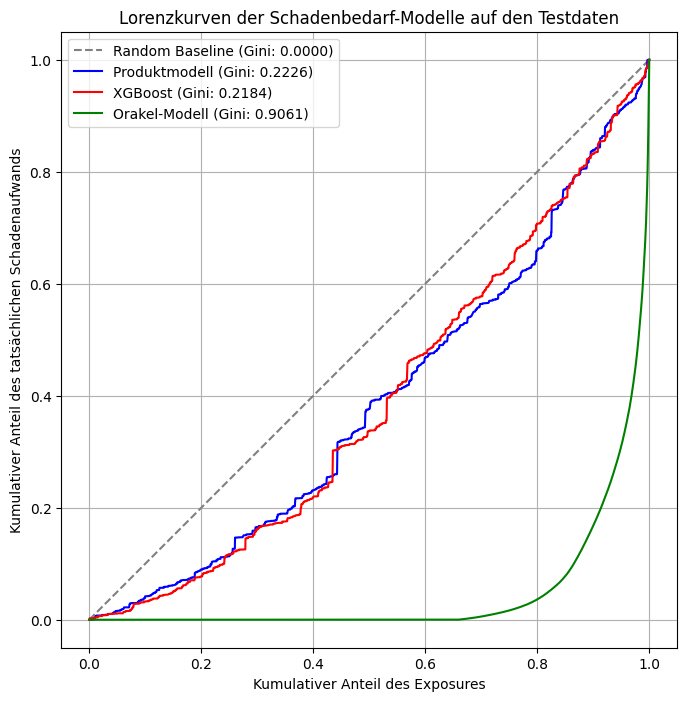

In [ ]:
# Berechnen der Datengrundlage für die Lorenzkurve und des Gini-Index für Produktmodell und XGBoost
lorenz_exp_test_freq_x_sev, lorenz_cost_test_freq_x_sev, gini_test_freq_x_sev = calculate_lorenz_data_and_gini(pred_pp_test_freq_x_sev, y_pp_test, expo_test)
lorenz_exp_test_pp_xgboost, lorenz_cost_test_pp_xgboost, gini_test_pp_xgboost = calculate_lorenz_data_and_gini(pred_pp_test_xgboost, y_pp_test, expo_test)

# Für Orakel-Modell Übergabe des beobachteten Schadenbedarfs als Vorhersage für die richtige Sortierung
lorenz_exp_test_oracle, lorenz_cost_test_oracle, gini_test_oracle = calculate_lorenz_data_and_gini(y_pp_test, y_pp_test, expo_test)

# Random Baseline als Winkelhalbierende von (0,0) bis (1,1) mit Gini-Index 0
lorenz_exp_test_random_baseline = np.linspace(0, 1, 100)
lorenz_cost_test_random_baseline = lorenz_exp_test_random_baseline
gini_test_random_baseline = 0.0

# Plot der Lorenzkurven
plt.figure(figsize=(10, 8))
plt.plot(lorenz_exp_test_random_baseline, lorenz_cost_test_random_baseline, linestyle='--', color='gray', label=f'Random Baseline (Gini: {gini_test_random_baseline:.4f})')
plt.plot(lorenz_exp_test_freq_x_sev, lorenz_cost_test_freq_x_sev, linestyle='-', color='blue', label=f'Produktmodell (Gini: {gini_test_freq_x_sev:.4f})')
plt.plot(lorenz_exp_test_pp_xgboost, lorenz_cost_test_pp_xgboost, linestyle='-', color='red', label=f'XGBoost (Gini: {gini_test_pp_xgboost:.4f})')
plt.plot(lorenz_exp_test_oracle, lorenz_cost_test_oracle, linestyle='-', color='green', label=f'Orakel-Modell (Gini: {gini_test_oracle:.4f})')

plt.title('Lorenzkurven der Schadenbedarf-Modelle auf den Testdaten')
plt.xlabel('Kumulativer Anteil des Exposures')
plt.ylabel('Kumulativer Anteil des tatsächlichen Schadenaufwands')
plt.legend(loc='upper left')
plt.grid(True)
plt.gca().set_aspect('equal', adjustable='box')
plt.show()

Das Produktmodell weist im Vergleich zu XGBoost den leicht besseren Gini-Index auf, insgesamt werden im Vergleich zum Orakel-Modell etwa $\frac{0,22}{0,91}\approx 24\%$ der theoretisch maximal möglichen Trennschärfe erreicht.
In beiden Lorenzkurven sind an Stellen mit extremem Anstieg gut einzelne Großschäden zu erkennen.

Wir überprüfen außerdem noch die globale Kalibrierung der Modelle, indem wir jeweils die Summe der tatsächlich beobachteten Schäden durch die Summe der vorhergesagten Schadenaufwände teilen.
Wie bei der Untersuchung der Ranking-Qualität berücksichtigen wir aus Gründen der Konsistenz die Kappung der Zielvariable bei der Modellierung auch in den beobachteten Schadenaufwänden.

In [ ]:
# Berechne die tatsächlichen (gekappten) Aufwände
total_actual_cost_train = (y_pp_train.values.ravel() * expo_train.values.ravel()).sum()
total_actual_cost_val = (y_pp_val.values.ravel() * expo_val.values.ravel()).sum()
total_actual_cost_test = (y_pp_test.values.ravel() * expo_test.values.ravel()).sum()

# Berechne Actual / Expected für das Produktmodell
ae_cost_train_freq_x_sev = total_actual_cost_train / (pred_pp_train_freq_x_sev * expo_train.values.ravel()).sum()
ae_cost_val_freq_x_sev = total_actual_cost_val / (pred_pp_val_freq_x_sev * expo_val.values.ravel()).sum()
ae_cost_test_freq_x_sev = total_actual_cost_test / (pred_pp_test_freq_x_sev * expo_test.values.ravel()).sum()

# Berechne Actual / Expected für XGBoost
ae_cost_train_pp_xgboost = total_actual_cost_train / (pred_pp_train_xgboost * expo_train.values.ravel()).sum()
ae_cost_val_pp_xgboost = total_actual_cost_val / (pred_pp_val_xgboost * expo_val.values.ravel()).sum()
ae_cost_test_pp_xgboost = total_actual_cost_test / (pred_pp_test_xgboost * expo_test.values.ravel()).sum()

# Ausgabe in einer Tabelle
results_ae_cost = pd.DataFrame([
    ['Freq x Sev', ae_cost_train_freq_x_sev, ae_cost_val_freq_x_sev, ae_cost_test_freq_x_sev],
    ['XGBoost', ae_cost_train_pp_xgboost, ae_cost_val_pp_xgboost, ae_cost_test_pp_xgboost]
    ], columns=['Model', 'Train A/E', 'Val A/E', 'Test A/E'])

print("Globale Kalibrierung der Schadenbedarf-Modelle:")
display(results_ae_cost.style.format({'Train A/E': '{:.4f}', 'Val A/E': '{:.4f}', 'Test A/E': '{:.4f}'}).hide(axis='index'))

Globale Kalibrierung der Schadenbedarf-Modelle:


Model,Train A/E,Val A/E,Test A/E
Freq x Sev,0.9853,1.1290,1.0744
XGBoost,1.0124,1.1468,1.0634


In beiden Fällen ist die Balance Property gut erfüllt, da der A/E Wert im Training nahe an 1 liegt.
Auf den Validierungs- und Testdaten ist die globale Kalibrierung hingegen unzureichend, die Modelle unterschätzen hier jeweils stark.
Aufgrund der ähnlichen Größenordnungen von Produktmodell und XGBoost könnte dies gerade vor dem Hintergrund der eher geringen Datenmenge aber auch durch zufällige Effekte im Split selbst statt durch ein reines Modellproblem verursacht sein.
Ein ähnliches Phänomen haben wir bereits bei der Severity-Modellierung festgestellt, sodass eine tiefgreifendere Untersuchung angebracht ist.

Generell kommt im Tarifierungskontext sowohl der Kalibrierung als auch der Ranking-Qualität eines Modells eine große Bedeutung zu.
Durch ein falsch kalibriertes Modell bekommen wir entweder insgesamt zu wenig Prämie, um damit die anfallenden Schäden des Portfolios zu bezahlen, oder die Preise sind im Vergleich zum Markt zu teuer und wir büßen deutlich an Umsatz ein.
Schlechtes Ranking führt hingegen zum Problem der Antiselektion: Gute Risiken gehen zu konkurrierenden Versicherungsunternehmen mit schärferen Modellen, während wir die schlechten Risiken einkaufen, für welche dann die (im Schnitt eigentlich korrekt eingestellte) Prämie zu niedrig ist.
Isoliert betrachtet scheint die Kalibrierung wichtiger, allerdings lässt sich diese auch deutlich leichter korrigieren als das Ranking.
In der Praxis liegt die Priorität daher meistens darauf, eine möglichst gute Ranking-Qualität zu erreichen und die globale Kalibrierung anschließend gezielt durch einen Skalierungsfaktor herzustellen (im finalen Niveau muss dann natürlich auch explizit der durch Kappung weggefallene Schadenaufwand berücksichtigt werden).
Problematisch wird es vor allem dann, wenn die Fehlkalibrierung stark segmentabhängig auftritt.
In diesem Fall ist es häufig ratsam, dass besser kalibrierte und robustere Modell zu bevorzugen.

### f) Modellvergleich und Empfehlung

**Erstellen Sie eine Vergleichstabelle mit allen Modellen. Geben Sie im
Anschluss eine begründete Modellempfehlung für die Praxis. Berücksichtigen Sie dabei sowohl Vorhersagegenauigkeit
als auch Interpretierbarkeit, Trainingszeit und versicherungstechnische Plausibilität.**

Wie bereits am Ende von Teil A diskutiert ist der vorliegende Datensatz aufgrund des recht geringen (und methodisch falsch berechneten) Exposures sowie dem Fehlen von typischerweise sehr wichtigen Risikomerkmalen wie einer Bonus-Malus-Klasse oder Fahrleistung für eine echte tarifliche Produktentwicklung nicht wirklich geeignet.
Zudem wurde für Optimierung, Validierung und Plausibilisierung jeweils verhältnismäßig nur sehr wenig Zeit aufgewendet.
Wir geben im Rahmen der Möglichkeiten dennoch eine begründete Modellempfehlung für die Praxis.

In [ ]:
# Ergebnisdatenstruktur ausgeben
print("Ergebnisdatenstruktur der Schadenbedarf-Modelle:")
display_pp_model_results()

Ergebnisdatenstruktur der Schadenbedarf-Modelle:


Model,Train_Metric,Validation_Metric,Test_Metric,Optimization_Time,Modeling_Time
Freq x Sev,36.4873,39.2682,38.5334,2.05,4.28
GLM,37.0941,38.9358,38.5718,0.00,0.04
GLM (opt),37.0588,38.8123,38.5666,5.68,0.02
LightGBM,36.8688,39.5018,38.6382,104.61,0.32
XGBoost,36.1134,39.4952,38.5400,223.17,0.14


Wir erkennen, dass die GLMs auf den den Trainingsdaten die höchste und auf den Validierungsdaten die kleinste Tweedie-Devianz aufweisen.
Die beste Vorhersagegenauigkeit im Sinne der niedrigsten Evaluierungsmetrik auf den Testdaten besitzt das Produktmodell knapp vor XGBoost, wohingegen LightGBM den letzten Platz belegt.
Diese Werte sind aufgrund der Problematik rund um die Annahme einer Tweedie-Verteilung sowie die Wahl eines geeigneten Power-Parameters allerdings mit Vorsicht zu genießen.
Wir haben gesehen, dass das Produktmodell gegenüber XGBoost mit dem Gini-Index auch in einer verteilungsfreien Kennzahl leicht vorne liegt (die Kalibrierung auf den Validierungs- bzw. Testdaten aber jeweils mit einem Skalierungsfaktor korrigiert werden muss).

Die Boosting-Modelle haben aufgrund der Hyperparameter-Optimierung die deutlich längste Gesamttrainingszeit, während beim Produktmodell nur in der Severity-Komponente eine kurze Feature-Selection durchgeführt wurde und das Tuning des Tweedie-GLMs kaum ins Gewicht fällt.
Wir bewegen uns allerdings überall in Größenordnungen, welche für die Entscheidung vernachlässigt werden können.

Die mit Abstand beste Interpretierbarkeit besitzen natürlich die GLMs, bei welchen der direkte multiplikative Einfluss der einzelnen Merkmale auf die Prognose an den geschätzten Koeffizienten bzw. Relativitäten erkennbar ist.
Das Produktmodell hat den großen Vorteil, dass der vorhergesagte Schadenbedarf in die Komponenten Frequenz und Höhe aufgeteilt ist, welche einzeln inhaltlich deutlich leichter zu interpretieren sind.
Zumindest das GAM als Severity-Modell weist dabei ähnlich gute Interpretierbarkeit wie ein GLM auf, während der für die Frequenz verwendete Random Forest genauso wie die Boosting-Modelle zunächst starken Blackbox-Charakter hat.
Auch deren Funktionsweise können wir aber etwa mithilfe von Feature Importance, Partial Dependence Plots oder Explainability-Methoden wie Shapley-Values genauer untersuchen und verstehen.

Eine getrennte Modellierung von Schadenfrequenz und -höhe ist im Kontext von KFZ-Policen versicherungstechnisch plausibel, da die beiden Effekte als ausreichend unabhängig voneinander angenommen werden.
Sie erleichtert es Aktuaren, die Wirkung von Risikotreibern besser zu verstehen als bei der ausschließlichen Betrachtung des Schadenbedarfs.
Bei letzterer muss in unserem spezifischen Fall die Modellierung unter Annahme einer Tweedie-Verteilung kritisch hinterfragt werden (wobei das für Poisson bei der Frequency- bzw. Gamma in der Severity-Komponente in ähnlicher Weise gilt).
Generell weisen GLMs und GAMs eine sehr gute versicherungstechnische Plausibilität auf, während bei Machine Learning Modellen schnell schwer erklärbare, sprunghafte oder nicht-monotone Effekte entstehen können und in diesem Kontext extrem gut auf potentielles Overfitting geachtet werden muss.
Die Möglichkeit von Monotoniebeschränkungen haben wir dabei nicht genutzt, was aber im Hinblick auf die vorliegenden Merkmale (von denen zunächst keines absolut kritisch scheint) genauso wie die schwierigere Umsetzbarkeit von anderen fachlichen Vorgaben nicht so schwer ins Gewicht fällt.

Wir empfehlen daher abschließend die Verwendung des Produktmodells, welches auf Basis unserer Untersuchungen die beste Vorhersagefähigkeit besitzt und möglicherweise weniger stark von den Problemen betroffen ist, welche die Verzerrungen im Zuge der fehlerhaften Exposure-Berechnung mit sich bringen.
Durch die Trennung in Schadenfrequenz- und höhe können wir Veränderungen im prognostizierten Schadenbedarf zielgerichteter analysieren und profitieren bei der Severity-Komponente von der guten Interpretierbarkeit des GAMs, wobei der zur Frequency-Modellierung verwendete Random Forest in seiner Wirkung vor der finalen Entscheidung mithilfe geeigneter Methoden nochmal eingehend plausibilisiert werden sollte.